iMPORTO LIBRERIAS

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from pathlib import Path


import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

!pip install mlflow
import mlflow.sklearn

!pip install pyngrok
from pyngrok import ngrok

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0

In [ ]:

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta = "/content/drive/MyDrive/TFM"
os.chdir(ruta)

print("carpeta actual:")
print(os.getcwd())

print("\narchivos en la carpeta:")
print(os.listdir())

carpeta actual:
/content/drive/MyDrive/TFM

archivos en la carpeta:
['food4.csv', 'TFM SALUDV1.ipynb', 'food4_parcel_number_rapidfuzz_imputado.csv', 'food4_actualizado2.csv', 'food4_limpio.csv', 'catboost_info', 'food4_con_parcel_imputado.csv', 'parcel_number_rapidfuzz_resultados.csv', 'export(10)_parcel_number_rapidfuzz_imputado.csv', 'parcel_number_candidatos.csv', 'export_actualizado.csv', 'export(10).csv', 'export(10)limpio.csv', 'export(11).csv', 'export(11)limpio.csv', 'dataset_con_city_imputada.csv', 'dataset_con_address_imputada.csv', 'outputs_reincidencia', 'export(12).csv', 'dataset_limpio_final.csv', 'dataset_con_sip_code_imputado.csv']


In [ ]:
# CARGA DE DATOS
raw = pd.read_csv(
    'export(12).csv'
)

EXPLORACIÓN DE LOS DATOS

In [ ]:
raw.head(20)

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,Inspection Closed Business,Seating Range,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-RT-0465692-2025
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-EDU-104561-2025
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-DAXHJEKXU
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,No,0-12,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DA05TOC3V
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G
5,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,RED,"0100 - PIC present, demonstrates knowledge and...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G
6,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G
7,#807 TUTTA BELLA,NaN,02/29/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,10,Satisfactory,No,0-12,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAKOF5VBX
8,#807 TUTTA BELLA,NaN,02/29/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,10,Satisfactory,No,0-12,3.0,BLUE,"4200 - Food-contact surfaces maintained, clean...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAKOF5VBX
9,#807 TUTTA BELLA,NaN,03/02/2023,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,20,Unsatisfactory,No,0-12,3.0,RED,1300 - Food contact surfaces cleaned and sanit...,15,Excellent,925049330.0,PFE-PR-3147569,PFE-DAJ5DTHLV


In [ ]:
raw.shape

(106995, 20)

In [ ]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106995 entries, 0 to 106994
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        106995 non-null  object 
 1   Program Identifier          19519 non-null   object 
 2   Inspection Date             106995 non-null  object 
 3   Classification              106995 non-null  object 
 4   Address                     106994 non-null  object 
 5   City                        106987 non-null  object 
 6   Zip Code                    106994 non-null  object 
 7   Inspection Type             106995 non-null  object 
 8   Inspection Score            106995 non-null  int64  
 9   Inspection Result           106995 non-null  object 
 10  Inspection Closed Business  106995 non-null  object 
 11  Seating Range               83706 non-null   object 
 12  Risk Category               106369 non-null  float64
 13  Violation Type

In [ ]:
raw.describe()

,Inspection Score,Risk Category,Violation Points
count,106995.000000,106369.000000,106995.000000
mean,15.573999,2.771165,4.614739
std,21.398284,0.563647,5.737085
min,-1.000000,1.000000,0.000000
25%,0.000000,3.000000,0.000000
50%,8.000000,3.000000,5.000000
75%,23.000000,3.000000,5.000000
max,167.000000,3.000000,25.000000


In [ ]:

raw.isnull().sum().sort_values(ascending=False)

,0
Program Identifier,87476
Violation Description,39810
Violation Type,39810
Seating Range,23289
Risk Category,626
Parcel Number,358
City,8
Zip Code,1
Address,1
Classification,0


In [ ]:
missing =(raw.isnull()
.mean()
.mul(100)
.sort_values(ascending=False))
missing.head(20)

,0
Program Identifier,81.757091
Violation Description,37.207346
Violation Type,37.207346
Seating Range,21.766438
Risk Category,0.585074
Parcel Number,0.334595
City,0.007477
Zip Code,0.000935
Address,0.000935
Classification,0.000000


EXPLORACIÓN DE TIPOLOGÍAS DE VARIABLES

In [ ]:
numericas = raw.select_dtypes(include=["int64","float64"]).columns
categoricas = raw.select_dtypes(include=["object"]).columns

print(f"Número de variables numéricas: {len(numericas)}")

print(f"Número de variables categóricas: {len(categoricas)}")

Número de variables numéricas: 3
Número de variables categóricas: 17


In [ ]:
print("Variables numéricas")

display(pd.DataFrame(numericas,columns=["Variable"]))

print("\n")

print("Variables categóricas")

display(pd.DataFrame(categoricas,columns=["Variable"]))

Variables numéricas


,Variable
0,Inspection Score
1,Risk Category
2,Violation Points




Variables categóricas


,Variable
0,Name
1,Program Identifier
2,Inspection Date
3,Classification
4,Address
5,City
6,Zip Code
7,Inspection Type
8,Inspection Result
9,Inspection Closed Business


Para analizarlas y detectar incidencias, las describimos

In [ ]:
raw[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Inspection Score,106995.0,15.573999,21.398284,-1.0,0.0,8.0,23.0,167.0
Risk Category,106369.0,2.771165,0.563647,1.0,3.0,3.0,3.0,3.0
Violation Points,106995.0,4.614739,5.737085,0.0,0.0,5.0,5.0,25.0


In [ ]:
raw[categoricas].describe().T

,count,unique,top,freq
Name,106995,9846,LEVY RESTAURANTS @ LUMEN FIELD,723
Program Identifier,19519,2390,LUNCHROOM,1087
Inspection Date,106995,1666,06/10/2026,221
Classification,106995,15,General Food Services,83214
Address,106994,9484,800 OCCIDENTAL AVE S,829
City,106987,111,SEATTLE,37451
Zip Code,106994,131,98101,4210
Inspection Type,106995,3,Routine Inspection/Field Review,102360
Inspection Result,106995,3,Satisfactory,52363
Inspection Closed Business,106995,2,No,106820


De esta información además de detectar un posible error (inspeccioón negativa) también nos obliga a mantener presentes que hay actas que documentan hasta 19 inspecciones, por lo que a efectos de determinar la reincidencia, será imprescindible tener este valor en cuenta. En todo caso, analizamos los valores únicos detectados

In [ ]:
valores_unicos= pd.DataFrame({
    "Variable": raw.columns,
    "Valores unicos": raw.nunique().values
    })
valores_unicos.sort_values(by="Valores unicos", ascending=False)

,Variable,Valores unicos
19,Inspection_Serial_Num,72070
18,Business_ID,12299
0,Name,9846
4,Address,9484
17,Parcel Number,7255
1,Program Identifier,2390
2,Inspection Date,1666
6,Zip Code,131
8,Inspection Score,127
5,City,111


Y la cardinalidad

In [ ]:
cardinalidad = pd.DataFrame({
    "Variable":categoricas,
    "Categorías": [
        raw[col].nunique()
        for col in categoricas
    ]
})

cardinalidad.sort_values(
    by="Categorías",
    ascending=False
)

,Variable,Categorías
16,Inspection_Serial_Num,72070
15,Business_ID,12299
0,Name,9846
4,Address,9484
14,Parcel Number,7255
1,Program Identifier,2390
2,Inspection Date,1666
6,Zip Code,131
5,City,111
12,Violation Description,53


Aunque evidentemente son menos nos ocupamos de las numéricas

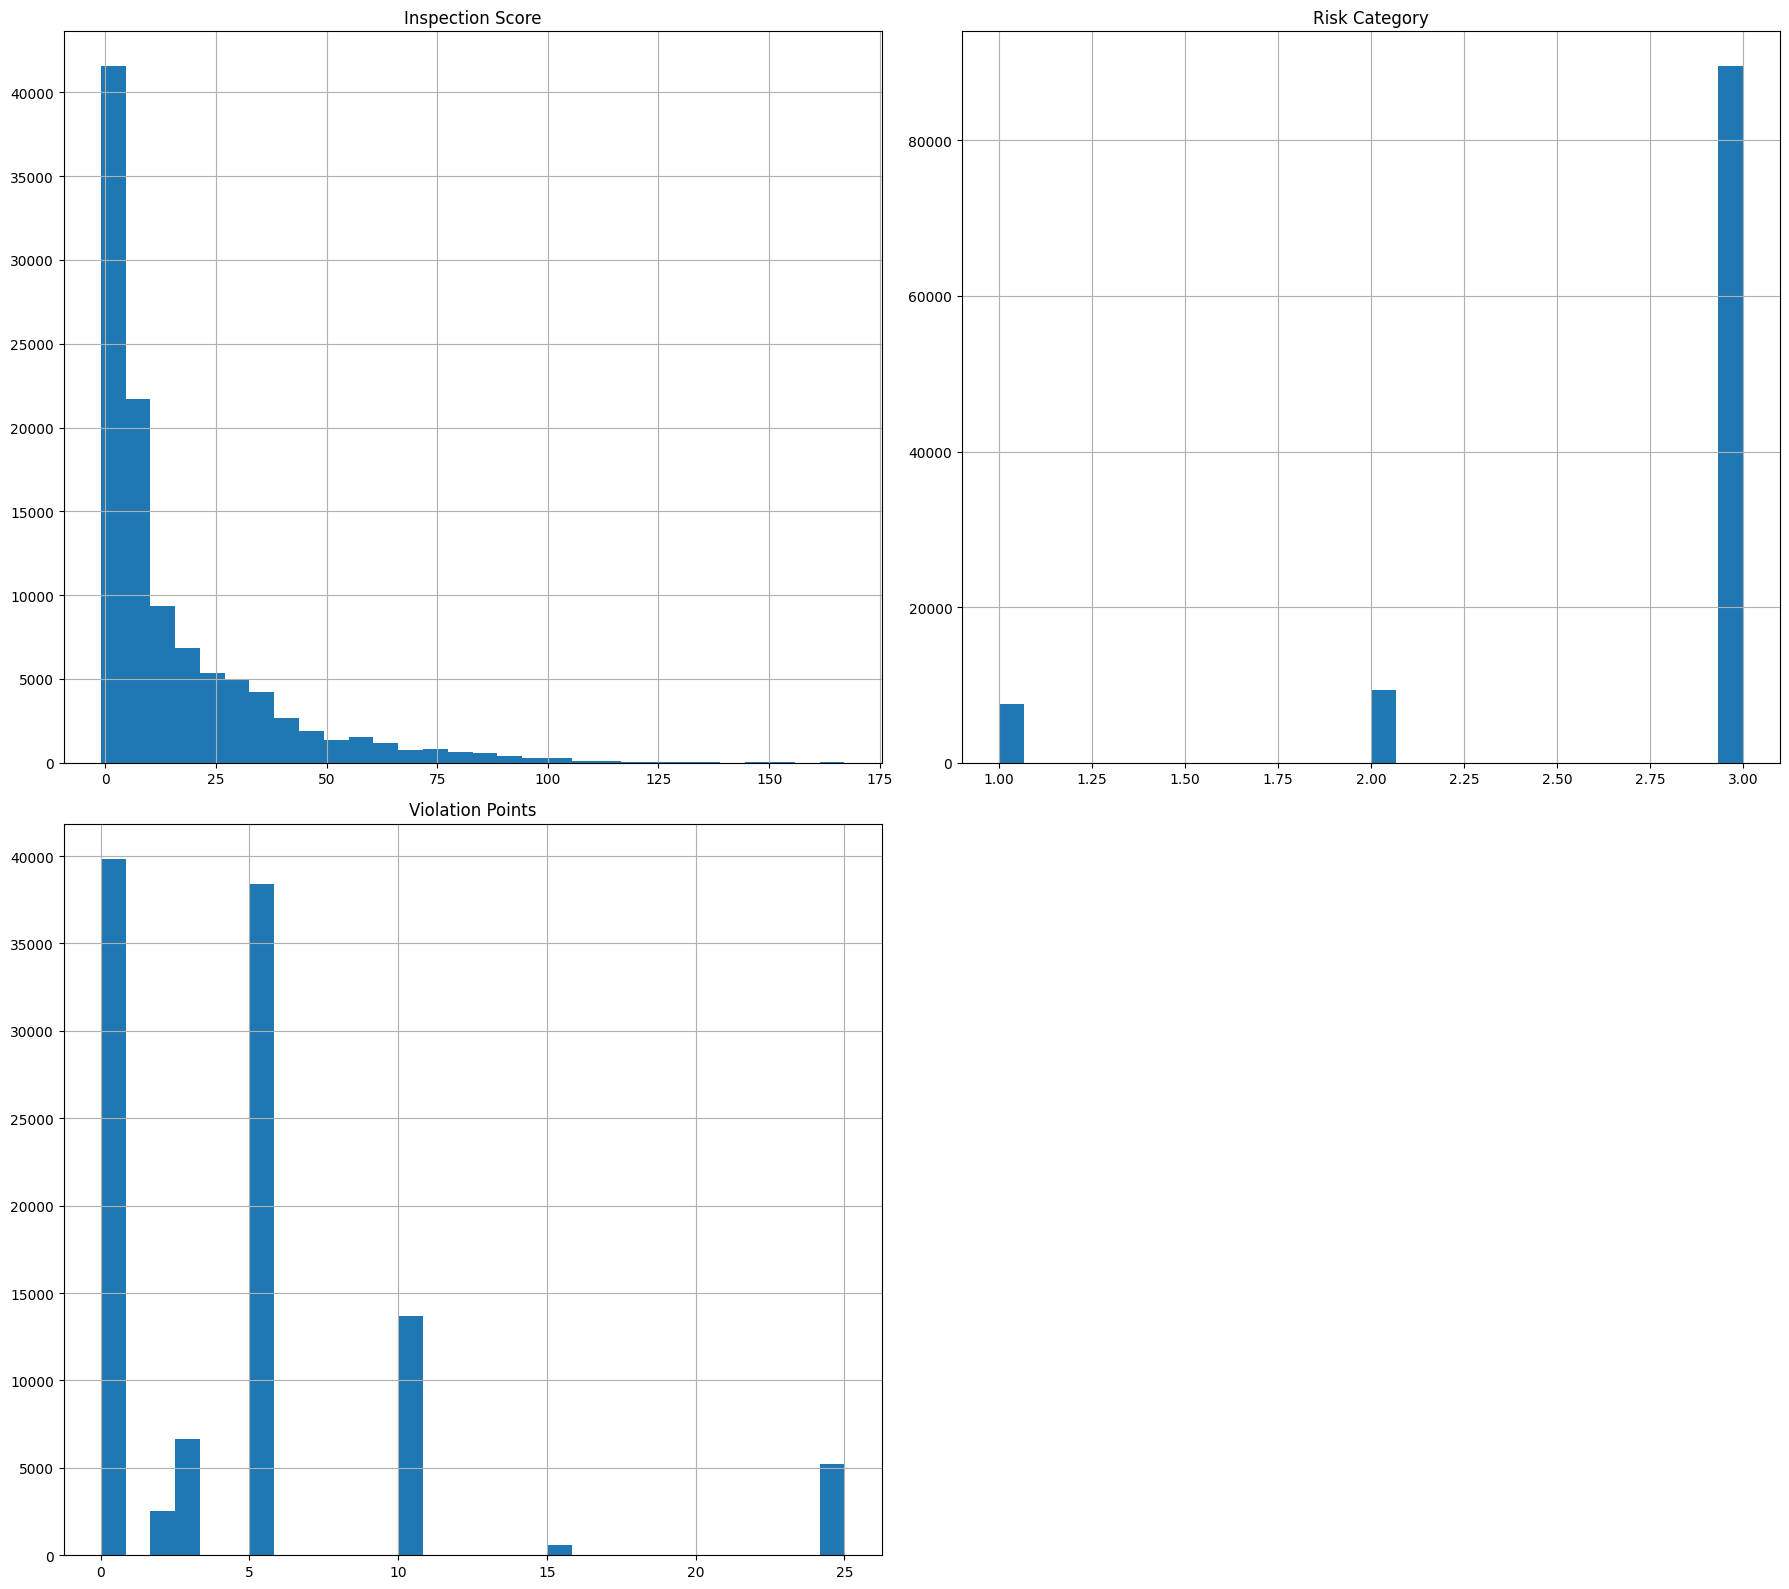

In [ ]:
# primero visualmente

numericas = raw.select_dtypes(include=["int64","float64"]).columns

raw[numericas].hist(
    figsize=(18,16),
    bins=30
)

plt.tight_layout()

plt.show()

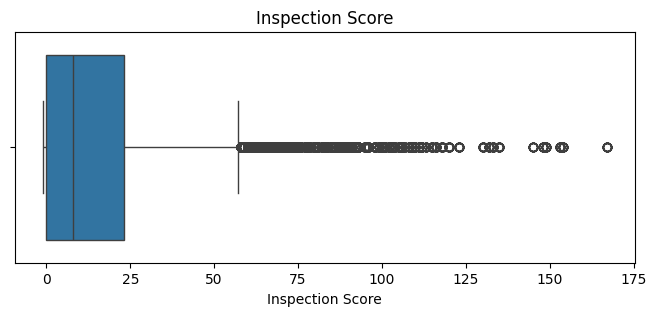

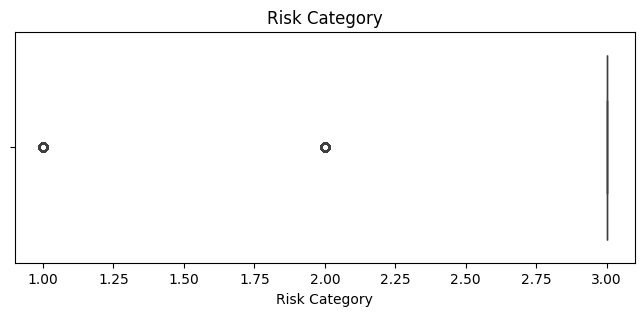

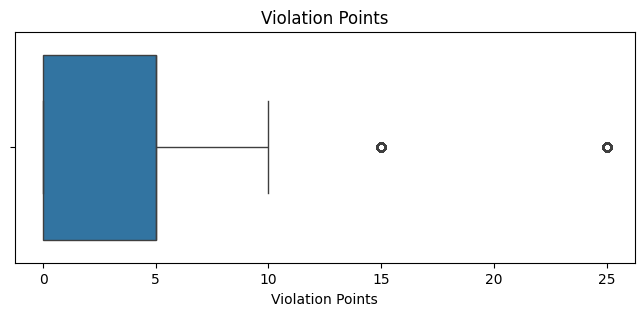

In [ ]:
for columna in numericas:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=raw[columna]
    )

    plt.title(columna)

    plt.show()

Estos gráficos permiten apreciar la gran concentración de infracciones en ún número pequeño de las mismas, y que son minoritarios los establecimientos que alcanzan un gran número de puntos vulnerados.

La siguiente información relevante es la correlación

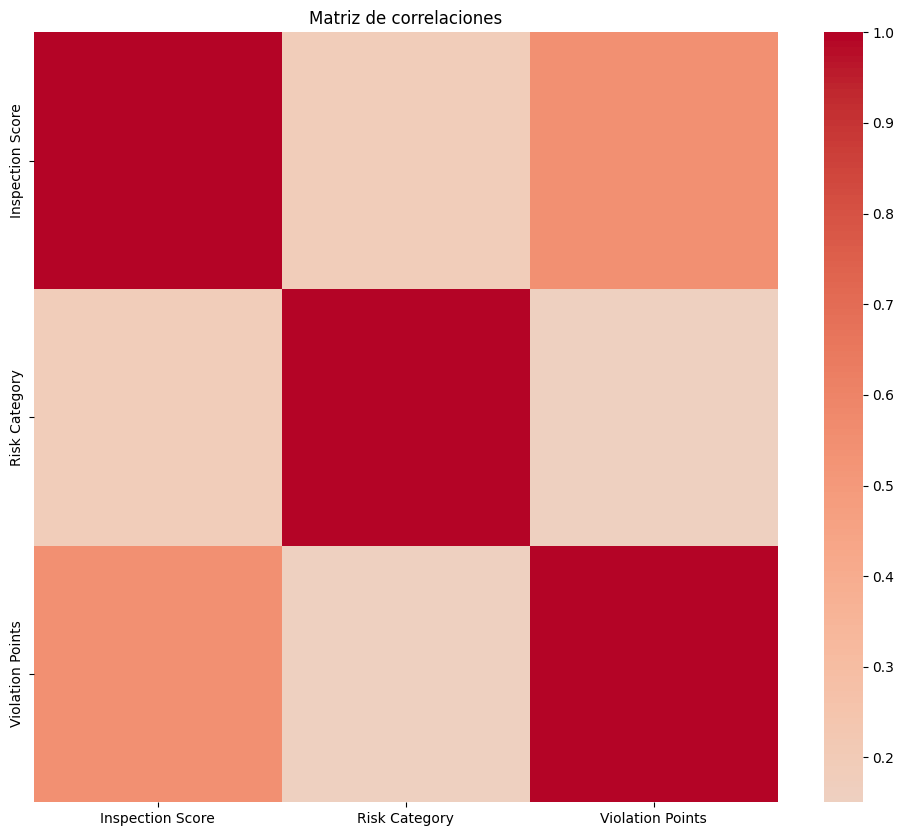

In [ ]:
corr = raw[numericas].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")

plt.show()

In [ ]:
corr_matrix = raw[numericas].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

correladas = []

for columna in upper.columns:

    if any(upper[columna]>0.90):

        correladas.append(columna)

print(correladas)

[]


A la vista de que hemos detectado que la gran cardinalidas de algunas variables y el alto número de nulos puede que sea consecuencia de la falta de normalización del dataset, analizaremos la cardinalidad de las variables tras haber llevado a cabo esta.

In [ ]:
# 1. NORMALIZACIÓN

raw.columns = (
    raw.columns
       .str.strip()
       .str.lower()
       .str.replace(" ", "_")
       .str.replace("-", "_")
)

text_cols = [
    "name", "address", "city", "classification", "inspection_type",
    "inspection_result", "inspection_closed_business", "seating_range",
    "violation_type", "violation_description", "grade",
    "business_id", "inspection_serial_num"
]

for col in text_cols:
    if col in raw.columns:
        raw[col] = (
            raw[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", " ", regex=True)
        )

raw["inspection_date"] = pd.to_datetime(
    raw["inspection_date"], format="%m/%d/%Y", errors="coerce"
)

for col in ["inspection_score", "violation_points", "risk_category", "zip_code", "parcel_number"]:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw["inspection_result"] = (
    raw["inspection_result"].astype("string").str.lower().str.strip()
)

raw["has_violation_row"] = (
    raw["violation_description"].notna()
    & ~raw["violation_description"].fillna("").astype(str).str.lower().str.strip()
        .isin(["", "nan", "none", "no violation"])
)

print("Filas originales:", f"{len(raw):,}")
print("Inspecciones únicas:", f"{raw['inspection_serial_num'].nunique():,}")
print("Establecimientos únicos:", f"{raw['business_id'].nunique():,}")
print("Periodo:", raw["inspection_date"].min().date(), "→", raw["inspection_date"].max().date())



Filas originales: 106,993
Inspecciones únicas: 72,068
Establecimientos únicos: 12,298
Periodo: 2021-01-04 → 2026-08-27


In [ ]:

if 'zip_code' not in raw.columns and 'Zip Code' in raw.columns:
    raw.rename(columns={'Zip Code': 'zip_code'}, inplace=True)


raw['zip_code'] = raw['zip_code'].astype(str).str.extract(r'(\d{5})', expand=False)

In [ ]:
# Convertir los espacios vacíos en nulos para mejorar su detección

implicit_nulls = ['NOT RATED', 'RATING NOT AVAILABLE', 'NONE', 'UNKNOWN', 'N/A', 'NAN', '']
raw.replace(implicit_nulls, np.nan, inplace=True)

In [ ]:
# repito el análisis
null_summary = pd.DataFrame({
    'Valores Nulos': raw.isnull().sum(),
    'Porcentaje (%)': (raw.isnull().sum() / len(raw) * 100).round(2)
}).query('`Valores Nulos` > 0')

print(null_summary)

                       Valores Nulos  Porcentaje (%)
program_identifier             87476           81.76
address                            1            0.00
city                               8            0.01
zip_code                          13            0.01
seating_range                  23289           21.77
risk_category                    626            0.59
violation_type                 39810           37.21
violation_description          39810           37.21
parcel_number                    363            0.34


In [ ]:
# normalizo city
import re
from IPython.display import display

# normalizo abreviaturas más comunes

# 1. Copio el dataset antes de los cambios

raw['city_original_inicial'] = raw['city'].copy()


print(f"Filas del dataset: {len(raw):,}")
print(f"City nulos antes: {raw['city'].isna().sum():,}")


# 2. Creo un diccionario de abreviaturas


address_abbreviations = {
    # Tipos de vía
    'ST': 'STREET',
    'STE': 'SUITE',
    'AVE': 'AVENUE',
    'AV': 'AVENUE',
    'RD': 'ROAD',
    'RDG': 'RIDGE',
    'BLVD': 'BOULEVARD',
    'DR': 'DRIVE',
    'LN': 'LANE',
    'CT': 'COURT',
    'CIR': 'CIRCLE',
    'PL': 'PLACE',
    'PKWY': 'PARKWAY',
    'HWY': 'HIGHWAY',
    'TER': 'TERRACE',
    'TRL': 'TRAIL',
    'SQ': 'SQUARE',
    'EXPY': 'EXPRESSWAY',
    'TPKE': 'TURNPIKE',

    # Direcciones
    'N': 'NORTH',
    'S': 'SOUTH',
    'E': 'EAST',
    'W': 'WEST',
    'NE': 'NORTHEAST',
    'NW': 'NORTHWEST',
    'SE': 'SOUTHEAST',
    'SW': 'SOUTHWEST'
}


# 3. FUNCIÓN PARA NORMALIZAR ADDRESS

def normalize_address(address):

    if pd.isna(address):
        return pd.NA

    address = str(address).upper().strip()

    # Eliminar puntos
    address = address.replace('.', '')

    # Sustituir caracteres no alfanuméricos por espacios
    address = re.sub(r'[^A-Z0-9\s]', ' ', address)

    # Eliminar espacios duplicados
    address = re.sub(r'\s+', ' ', address).strip()

    # Sustituir abreviaturas
    words = address.split()

    normalized_words = [
        address_abbreviations.get(word, word)
        for word in words
    ]

    return ' '.join(normalized_words)



# 4. CREAR ADDRESS_NORMALIZED


raw['address_normalized'] = raw['address'].apply(normalize_address)



# 5. IDENTIFICO LOS CITY NULOS

city_null_before = raw['city'].isna()

print(
    f"\nRegistros con City nulo: "
    f"{city_null_before.sum():,}"
)





# 6. CONSTRUIR TABLA DE REFERENCIA


reference = (
    raw.dropna(
        subset=[
            'address_normalized',
            'zip_code',
            'city'
        ]
    )
    .groupby(
        [
            'address_normalized',
            'zip_code'
        ]
    )['city']
    .agg(
        lambda x: sorted(x.dropna().unique().tolist())
    )
    .reset_index(name='possible_cities')
)


# Número de ciudades diferentes asociadas
# a cada Address + City Code
reference['n_cities'] = (
    reference['possible_cities'].apply(len)
)

# 7. IDENTIFICAR COMBINACIONES INEQUÍVOCAS

reference_unique = reference[
    reference['n_cities'] == 1
].copy()

reference_unique['city_inferred'] = (
    reference_unique['possible_cities'].str[0]
)

reference_unique = reference_unique[
    [
        'address_normalized',
        'zip_code',
        'city_inferred'
    ]
]

# 8. CREAR TABLA DE LOS REGISTROS A IMPUTAR

city_null = raw[
    raw['city'].isna()
].copy()

city_null = city_null.merge(
    reference_unique,
    on=[
        'address_normalized',
        'zip_code'
    ],
    how='left'
)


# 9. CREAR INFORMACIÓN DE TRAZABILIDAD

city_null['city_original'] = city_null['city']

city_null['city_imputation_method'] = (
    city_null['city_inferred']
    .apply(
        lambda x:
        'address + zip code'
        if pd.notna(x)
        else 'NOT_IMPUTED'
    )
)

city_null['city_imputation_confidence'] = (
    city_null['city_inferred']
    .apply(
        lambda x:
        'HIGH'
        if pd.notna(x)
        else 'NONE'
    )
)

# 10. ACTUALIZAR EL DATASET ORIGINAL

# Guardamos el índice original antes del merge
city_null_indices = raw[
    raw['city'].isna()
].index

# Crear un diccionario índice -> ciudad inferida
city_predictions = dict(
    zip(
        city_null_indices,
        city_null['city_inferred']
    )
)

# Rellenar SOLO cuando existe una ciudad inequívoca
for idx, inferred_city in city_predictions.items():

    if pd.notna(inferred_city):

        raw.loc[idx, 'city'] = inferred_city

# 11. CREAR COLUMNAS DE TRAZABILIDAD EN EL DATASET

# Inicialmente, todos los registros tienen City original
raw['city_original'] = raw['city']

# Para poder distinguir los que fueron imputados,
# reconstruimos la información usando los índices originales

raw['city_was_imputed'] = False
raw['city_imputation_method'] = 'ORIGINAL'
raw['city_imputation_confidence'] = 'ORIGINAL'


# Volvemos a identificar los registros que eran NaN originalmente
for idx, inferred_city in city_predictions.items():

    if pd.notna(inferred_city):

        raw.loc[idx, 'city_was_imputed'] = True
        raw.loc[idx, 'city_imputation_method'] = (
            'address + zip code'
        )
        raw.loc[idx, 'city_imputation_confidence'] = 'HIGH'


# ------------------------------------------------------------
# 12. CORRECCIÓN DE CITY_ORIGINAL
# ------------------------------------------------------------

# Necesitamos que City_original conserve el valor
# que tenía ANTES de la imputación.

# En los registros imputados era NaN.
raw.loc[
    raw['city_was_imputed'],
    'city_original'
] = pd.NA


# ------------------------------------------------------------
# 13. RESUMEN DE RESULTADOS
# ------------------------------------------------------------

print("\n" + "="*60)
print("RESUMEN DE IMPUTACIÓN")
print("="*60)

print(
    f"City nulos antes:       "
    f"{city_null_before.sum():,}"
)

print(
    f"City imputados:         "
    f"{raw['city_was_imputed'].sum():,}"
)

print(
    f"City nulos restantes:   "
    f"{raw['city'].isna().sum():,}"
)

print(
    f"Porcentaje recuperado:  "
    f"{raw['city_was_imputed'].sum() / city_null_before.sum() * 100:.2f}%"
)


# ------------------------------------------------------------
# 14. MOSTRAR REGISTROS IMPUTADOS
# ------------------------------------------------------------

display(
    raw[
        raw['city_was_imputed']
    ][
        [
            'name',
            'address',
            'address_normalized',
            'zip_code',
            'city_original',
            'city',
            'city_imputation_method',
            'city_imputation_confidence'
        ]
    ]
)


# ------------------------------------------------------------
# 15. COMPROBAR INCONSISTENCIAS
# ------------------------------------------------------------

check = (
    raw.dropna(
        subset=[
            'address_normalized',
            'zip_code',
            'city'
        ]
    )
    .groupby(
        [
            'address_normalized',
            'zip_code'
        ]
    )['city']
    .nunique()
)

inconsistent = check[check > 1]

print(
    "\nCombinaciones Address + City Code "
    "con varias ciudades:"
)

print(len(inconsistent))

if len(inconsistent) > 0:
    display(inconsistent)


# ------------------------------------------------------------
# 16. GUARDAR DATASET
# ------------------------------------------------------------

output_path = '/content/export_city_imputed.csv'

raw.to_csv(
    output_path,
    index=False
)

print(
    f"\nDataset guardado en: {output_path}"
)

Filas del dataset: 106,995
City nulos antes: 8

Registros con City nulo: 8

RESUMEN DE IMPUTACIÓN
City nulos antes:       8
City imputados:         2
City nulos restantes:   6
Porcentaje recuperado:  25.00%


,name,address,address_normalized,zip_code,city_original,city,city_imputation_method,city_imputation_confidence
12880,bocado oaxaqueno,1601 sw roxbury st,1601 SOUTHWEST ROXBURY STREET,98106,<NA>,seattle,address + zip code,HIGH
74908,rent's due bbq,33707 se redmond fall city rd,33707 SOUTHEAST REDMOND FALL CITY ROAD,98024,<NA>,fall city,address + zip code,HIGH



Combinaciones Address + City Code con varias ciudades:
17


,,city
address_normalized,zip_code,
10836 EAST MARGINAL WAY SOUTH,98168,2
14201 INTERURBAN AVENUE SOUTH,98168,2
15500 SIX PENNY LANE,98059,2
17171 BOTHELL WAY NORTHEAST,98155,2
17847 1ST AVENUE SOUTH,98148,2
1841 SOUTH 120TH STREET,98168,2
19840 INTERNATIONAL BOULEVARD,98188,2
3201 SOUTH 176TH STREET,98188,2
360 CORPORATE DRIVE NORTH,98188,2



Dataset guardado en: /content/export_city_imputed.csv


In [ ]:
import numpy as np
import pandas as pd

#2. EQUIVALENCIAS ENTRE INSPECCIÓN Y NÚMERO DE ACTA

# Cada Inspection_Serial_Num debería corresponder a una única acta.
result_check = (
    raw.groupby("inspection_serial_num")["inspection_result"]
       .nunique(dropna=True)
)


# Creamos primero la condición a nivel de acta para no decidir
# sobre Complete fila a fila.
inspection_flags = (
    raw.groupby("inspection_serial_num")
       .agg(
           has_violation=("has_violation_row", "any"),
           total_violation_points=("violation_points", "sum"),
           original_result=("inspection_result", "first")
       )
)

print("\nResultado original a nivel de acta:")
print(inspection_flags["original_result"].value_counts(dropna=False))


Resultado original a nivel de acta:
original_result
satisfactory      50569
unsatisfactory    21499
Name: count, dtype: Int64


EXPLORACIÓN DEL DATASET: DESCRIPCIÓN DE LAS INSPECCIONES CON RESULTADO DISTINTO A SATISFACTORIO

In [ ]:
resultados_interes = ["satisfactory", "unsatisfactory", "complete"]


raw_filtrado = raw[raw["inspection_result"].isin(resultados_interes)]

conteos = (raw_filtrado["inspection_result"]
  .value_counts()
  .reindex(resultados_interes, fill_value=0)
)



#  gráfico de barras
plt.figure(figsize=(8, 5))
colores = ["#2ca02c", "#d62728", "#1f77b4"]  # Verde, Rojo, Azul
barras = plt.bar(
    conteos.index.str.capitalize(), conteos.values, color=colores
)

# Configuración visual
plt.title(
    "Número de Actas por Resultado de Inspección",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Resultado de la Inspección", fontsize=10)
plt.ylabel("Cantidad de Actas", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Añadir el número exacto sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        yval + 800,
        f"{int(yval):,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [ ]:
raw= raw.sort_values(by=["business_id", "inspection_date"])

# Filtro todas las inspecciones con resultado 'complete'
complete_raw = raw[raw["inspection_result"] == "complete"]

# Verificar para cada inspección 'complete' si existe un 'unsatisfactory' previo
count_prior_unsatisfactory = 0

for _, row in complete_raw.iterrows():
    biz_id = raw["business_id"]
    comp_date = raw["inspection_date"]

    # Buscar inspecciones del mismo establecimiento anteriores a la fecha actual con 'unsatisfactory'
    has_prior_unsat = raw[
        (raw["business_id"] == biz_id)
        & (raw["inspection_result"] == "unsatisfactory")
        & (raw["inspection_date"] < comp_date)
    ]

    if not has_prior_unsat.empty:
        count_prior_unsatisfactory += 1

print(
    f"Inspecciones 'Complete' con 'Unsatisfactory' previo: {count_prior_unsatisfactory}"
)

Inspecciones 'Complete' con 'Unsatisfactory' previo: 0


Con esta información no podemos concluir que se trate únicamente de una segunda inspección, por lo dado que lo que se trata es de precedir las reincidencia, se considerarán insatisfactorias todas aquellas en las que se haya documentado una infracción, y satisfactorias las que no cuenten con esa información registrada

REVISIÓN VALORES NULOS

In [ ]:

print(raw.isnull().sum())

name                                        0
inspection_date                             0
classification                              0
address                                     0
city                                        0
zip_code                                    0
inspection_type                             0
inspection_score                            0
inspection_result                           0
inspection_closed_business                  0
seating_range                               0
risk_category                               0
violation_type                              0
violation_description                       0
violation_points                            0
grade                                       0
parcel_number                             362
business_id                                 0
inspection_serial_num                       0
inspection_result_clean                     0
has_violation_row                           0
city_original_inicial             

1. PROGRAM_IDENTIFIER
Dado que es la variable con más nulos exploramos su contenido, e intentamos ver si puede llegar a ser útil para el modelo

In [ ]:
unique_program_identifier= raw['program_identifier'].unique()
print(unique_program_identifier)

[nan 'LUNCHROOM' 'ALBERTSONS #3416 BAKERY' ... 'Service Bar' 'Park Bar'
 'Finish Line']


In [ ]:
# pese al gran número de nulos, tratamos de explorar si puede ser útil para el modelo
col="program_identifier"

print("=== CALIDAD DE LA VARIABLE===")
print(f"Filas totales: {len(raw):,}")
print(f"Valores no nulos: {raw[col].notna().sum():,}")
print(f"Valores nulos: {raw[col].isna().sum():,}")
print(f"% nulos: {raw[col].isna().mean()*100:.2f}%")
print(f"Valores únicos: {raw[col].nunique(dropna=True):,}")

print("\nValores más frecuentes:")
print(raw[col].value_counts(dropna=True).head(20))

=== CALIDAD DE LA VARIABLE===
Filas totales: 106,995
Valores no nulos: 19,519
Valores nulos: 87,476
% nulos: 81.76%
Valores únicos: 2,390

Valores más frecuentes:
program_identifier
LUNCHROOM                                             1087
QFC - GROCERY                                           76
GROCERY                                                 61
PCC COMMUNITY MARKETS - DELI                            53
TAQUERIA EL HERRADERO LLC  (KC242)@2800 NE SUNSET       48
SAFEWAY STORE #1508                                     44
UWAJIMAYA - DELI                                        43
FOU LEE MARKET & DELI                                   42
DELI                                                    41
HUNG LONG MARKET - MEAT/SEAFOOD                         40
SAAR'S SUPER SAVER FOODS - DELI                         39
FISHERMAN'S RESTAURANT                                  35
SAFEWAY STORE #555                                      35
THAI-U-UP (KC454) @206-457-9996                    

In [ ]:
# antes de desecharlo se intanta establecer una conexión con business id, ya que parecería estar identificando establecimientos concretos o con tipos de establecimiento (classification) o con los resultados de la inspección

print("\n=== RELACIÓN CON BUSINESS_ID ===")

# Cuántos Business_ID distintos tiene cada Program Identifier
program_business = (
    raw.dropna(subset=[col])
      .groupby(col)["business_id"]
      .nunique()
      .sort_values(ascending=False)
)

print("\nProgram Identifier con más Business_ID:")
print(program_business.head(20))

# Cuántos Program Identifier tiene cada negocio
business_program = (
    raw.groupby("business_id")[col]
      .nunique(dropna=True)
)

print("\nNúmero de Program Identifier por Business_ID:")
print(business_program.value_counts().sort_index())

print("\nResumen:")
print(business_program.describe())

print("\n=== PROGRAM IDENTIFIER vs CLASSIFICATION ===")

classification = pd.crosstab(
    raw[col],
    raw["classification"],
    normalize="index"
)

print(classification.head(20))



# ¿Tiene relación con los resultados de inspección?

print("\n=== PROGRAM IDENTIFIER vs INSPECTION RESULT ===")

result = pd.crosstab(
    raw[col],
    raw["inspection_result"],
    normalize="index"
)

print(result.head(20))






=== RELACIÓN CON BUSINESS_ID ===

Program Identifier con más Business_ID:
program_identifier
LUNCHROOM                       100
QFC - GROCERY                    12
GROCERY                           8
PCC COMMUNITY MARKETS - DELI      6
SAFEWAY STORE #555                4
CULINARY ARTS                     4
SAFEWAY STORE #497                4
DELI                              4
SAFEWAY STORE #1508               4
MEAT DEPARTMENT                   3
FACEBOOK INC- 6TH FLOOR           3
FACEBOOK INC- 4TH FLOOR           3
STUDENT STORE                     3
DFDO                              3
MAIN KITCHEN                      3
SAFEWAY STORE #1062               3
SNACK BAR                         3
STARBUCKS                         3
BAKERY                            3
WHOLE FOODS MARKET - BAKERY       3
Name: business_id, dtype: int64

Número de Program Identifier por Business_ID:
program_identifier
0    9713
1    2585
2       1
Name: count, dtype: int64

Resumen:
count    12299.000000


In [ ]:
# No parece existir relación aparente, sin embargo antes de descartarla intento vincularla con las variables clave

profile = (
    raw.dropna(subset=["program_identifier"])
      .groupby("program_identifier")
      .agg(
          n_inspections=("inspection_serial_num", "nunique"),
          n_businesses=("business_id", "nunique"),
          avg_score=("inspection_score", "mean"),
          avg_violation_points=("violation_points", "mean"),
          pct_unsatisfactory=(
              "inspection_result",
              lambda x: (x == "unsatisfactory").mean() * 100
          )
      )
)

# Nos quedamos con Program Identifier con suficiente volumen
profile_filtered = profile[profile["n_inspections"] >= 10]

print(
    profile_filtered
    .sort_values("pct_unsatisfactory", ascending=False)
    .head(30)
)

                                                    n_inspections  \
program_identifier                                                  
SAFEWAY #1885- CHINA DELI / BAKERY                             11   
WILD WHEAT BAKERY CAFE                                         12   
PHNOM PENH DELI                                                11   
SAFEWAY #1551 - DELI                                           12   
SAAR'S SUPER SAVER FOODS - DELI                                13   
TAQUERIA EL HERRADERO LLC  (KC242)@2800 NE SUNSET              12   
VIET WAH ASIAN FOOD MARKET / DELI                              11   
BANGKOK 99 (KC497) @ 206 915 9115                              10   
BA MIEN SEAFOOD MARKET -  DELI                                 12   
SAFEWAY #1550-DELI                                             13   
DINING HALL - GWINN COMMONS                                    10   
DEEZ DOGS @ 206-832-5023                                       10   
M2M MART- DELI                    

In [ ]:
# Dados que los resultados no son en absoluto concluyentes elimino progran identifier por el gran número de nulos y la imposibilidad de llevar a cabo un adecuado tratamiento de los mismos ya que su impacto significativo se acota a establecimientos singulares y parecería que este campo estaría funcionando más como una "categoría" o campo donde se apoarta identificación adicional sobre establecimientos concretos

if "program_identifier" in raw.columns:
    raw.drop("program_identifier", axis=1, inplace=True)

CITY

In [ ]:
## Es un número tan pequeño que me permite localizarlo

city_null=raw[raw['city'].isna()]
print(city_null)

                                                    name inspection_date  \
49735                                la tipica oaxaquena      2026-02-24   
49736                                la tipica oaxaquena      2026-02-24   
73448                                     que chimba llc      2026-03-24   
73447                                     que chimba llc      2026-04-09   
29697  enumclaw veterans of foreign wars 1949 buildin...      2026-08-26   
49219                                       la garrafita      2026-08-25   

                 classification           address  city zip_code  \
49735             grocery store  9640 16th ave sw  <NA>    98106   
49736             grocery store  9640 16th ave sw  <NA>    98106   
73448     general food services  9601 16th ave sw  <NA>    98106   
73447     general food services  9601 16th ave sw  <NA>    98106   
29697  dfdo exempt from billing              <NA>  <NA>      NaN   
49219     general food services  9619 16th ave sw  <NA>    

In [ ]:
# # buscamos las inspecciones a esos establecimientos por si en otro momento se hubieran hecho inspecciones que nos permitan rellenar la ciudad
nombre="La Tipica Oaxaquena"


mask = raw["name"].astype(str).str.contains(nombre, case=False, na=False)

print(
    raw[mask][
        ["business_id", "name", "address", "city", "zip_code"]
    ].drop_duplicates()
)

          business_id                 name             address     city  \
49741  pfe-pr-3149422  la tipica oaxaquena  1601 sw roxbury st  seattle   
49735   pfe-pr-500504  la tipica oaxaquena    9640 16th ave sw     <NA>   

      zip_code  
49741    98106  
49735    98106  


In [ ]:
nombre="QUE CHIMBA LLC"
mask = raw["name"].astype(str).str.contains(nombre, case=False, na=False)

print(
    raw[mask][
        ["business_id", "name", "address", "city", "zip_code"]
    ].drop_duplicates()

    )



         business_id            name           address  city zip_code
73448  pfe-pr-500533  que chimba llc  9601 16th ave sw  <NA>    98106


In [ ]:
nombre="LA GARRAFITA"
mask = raw["name"].astype(str).str.contains(nombre, case=False, na=False)

print(
    raw[mask][
        ["business_id", "name", "address", "city", "zip_code"]
    ].drop_duplicates()

    )

          business_id          name            address    city zip_code
49230  pfe-pr-3147279  la garrafita  805 s 112th st, 4  burien    98168
49219   pfe-pr-502063  la garrafita   9619 16th ave sw    <NA>    98106


In [ ]:
nombre="Enumclaw Veterans of Foreign Wars 1949 Building"
mask = raw["name"].astype(str).str.contains(nombre, case=False, na=False)

print(
    raw[mask][
        ["business_id", "name", "address", "city", "zip_code"]
    ].drop_duplicates()

    )

         business_id                                               name  \
29697  pfe-pr-501641  enumclaw veterans of foreign wars 1949 buildin...   

      address  city zip_code  
29697    <NA>  <NA>      NaN  


In [ ]:

# Como el filtro no es concluyente, y 5 de los 6 comparten dirección y código se establece como regla de imputación que si city figura como nulo, se intente buscar primero si existe otra inspección con ese businness_id para imputarlo, y si no, que se utilice el código postal para imputar la ciudad predonminante. Y si tampoco tiene código postal, se elimine

city_by_business = ( raw.dropna(subset=["name", "business_id", "city"])
 .groupby(["name", "business_id"])["city"]
 .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )

# primero business id

mask_city_null = raw["city"].isna()
raw.loc[mask_city_null, "city"] = (
raw.loc[mask_city_null]
    .set_index(["name", "business_id"])
    .index .map(city_by_business) .to_numpy() )

# Si no es posible, código postal predominante

city_by_zip = (
    raw.dropna(subset=["zip_code", "city"])
     .groupby("zip_code")["city"]
     .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )


mask_city_null = raw["city"].isna()
raw.loc[mask_city_null, "city"] = (
    raw.loc[mask_city_null, "zip_code"]
    .map(city_by_zip)
)

# Y si no tienen tampoco zip_code lo elimino

raw=raw.dropna(subset=["city"])

# lo guardo:

raw.to_csv("dataset_con_city_imputada.csv", index=False)

# Y se analiza el resultado

print("Registros finales:", len(raw))
print("Archivo generado: dataset_con_city_imputada.csv")



Registros finales: 106994
Archivo generado: dataset_con_city_imputada.csv


In [ ]:
city_null=raw[raw['city'].isna()]
print(city_null)

Empty DataFrame
Columns: [name, inspection_date, classification, address, city, zip_code, inspection_type, inspection_score, inspection_result, inspection_closed_business, seating_range, risk_category, violation_type, violation_description, violation_points, grade, parcel_number, business_id, inspection_serial_num, inspection_result_clean, has_violation_row, city_original_inicial, address_normalized, city_original, city_was_imputed, city_imputation_method, city_imputation_confidence]
Index: []


ADDRESS

Establecemos la misma lógica si hubiera nulos en esta variable.

In [ ]:
address_by_business = ( raw.dropna(subset=["name", "business_id", "address"])
 .groupby(["name", "business_id"])["address"]
 .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )

# primero business id

mask_address_null = raw["address"].isna()
raw.loc[mask_address_null, "address"] = (
raw.loc[mask_address_null]
    .set_index(["name", "business_id"])
    .index .map(address_by_business) .to_numpy() )

# Si no es posible, código postal predominante

address_by_zip = (
    raw.dropna(subset=["zip_code", "address"])
     .groupby("zip_code")["address"]
     .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )


mask_address_null = raw["address"].isna()
raw.loc[mask_address_null, "address"] = (
    raw.loc[mask_address_null, "zip_code"]
    .map(address_by_zip)
)

# Y si no tienen tampoco zip_code lo elimino

raw=raw.dropna(subset=["address"])

# lo guardo:

raw.to_csv("dataset_con_address_imputada.csv", index=False)

In [ ]:
address_null=raw[raw['address'].isna()]
print(address_null)

Empty DataFrame
Columns: [name, inspection_date, classification, address, city, zip_code, inspection_type, inspection_score, inspection_result, inspection_closed_business, seating_range, risk_category, violation_type, violation_description, violation_points, grade, parcel_number, business_id, inspection_serial_num, inspection_result_clean, has_violation_row, city_original_inicial, address_normalized, city_original, city_was_imputed, city_imputation_method, city_imputation_confidence]
Index: []


SEATING_RANGE

Probablemente no se trate de valores realmente nulos, sino que por la tipología de establecimiento, deba figurar como cero. Probamos la hipótesis.

Agrupación de valores 'NaN' en seating_range por clasificación:
classification
grocery store                     5024
school lunch program              4790
meat/fish market                  4062
mobile food unit                  3983
nonprofit institution             1873
bakery                            1471
catering operation                1388
limited food service               540
commissary kitchen                  68
dfdo exempt from billing            52
general food services               17
bed and breakfast operation         16
dfdo                                 3
commissary kitchen exempt from       1
Name: count, dtype: Int64


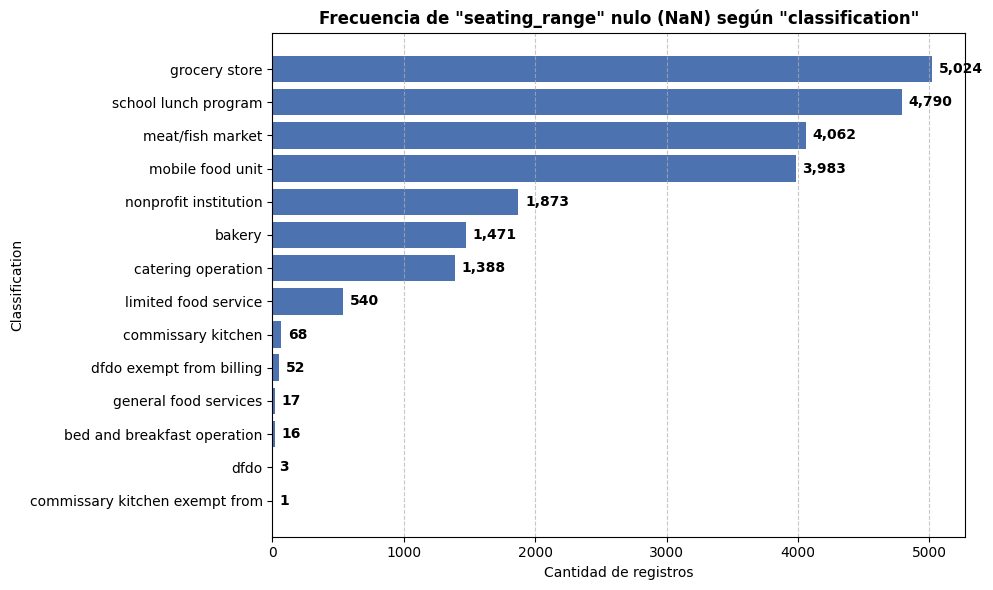

In [ ]:
filtro_nan_seating = (
    raw["seating_range"].isna()
    | (raw["seating_range"].astype(str).str.strip().str.lower() == "nan")
    | (raw["seating_range"].astype(str).str.strip() == "")
)

nan_seating_raw = raw[filtro_nan_seating]

# Agrupar por 'classification' y contar registros
conteo_class = nan_seating_raw["classification"].value_counts(dropna=False)

print("Agrupación de valores 'NaN' en seating_range por clasificación:")
print(conteo_class)

# Dibujar gráfico de barras horizontal para facilitar la lectura
plt.figure(figsize=(10, 6))
barras = plt.barh(
    conteo_class.index.astype(str), conteo_class.values, color="#4C72B0"
)

# Configuración del gráfico
plt.title(
    'Frecuencia de "seating_range" nulo (NaN) según "classification"',
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Cantidad de registros", fontsize=10)
plt.ylabel("Classification", fontsize=10)
plt.gca().invert_yaxis()  # Mostrar la más frecuente arriba
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Añadir valor exacto en cada barra
for barra in barras:
    xval = barra.get_width()
    plt.text(
        xval + (max(conteo_class.values) * 0.01),
        barra.get_y() + barra.get_height() / 2,
        f"{xval:,}",
        ha="left",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

para poder comparar verificamos a qué tipología de establecimientos sí se les aplica el valor de "seating_rate"

Datos agregados de clasificaciones con 'seating_range' informada:
classification
general food services          83197
general food service             507
bed and breakfast operation        1
bakery                             1
Name: count, dtype: Int64


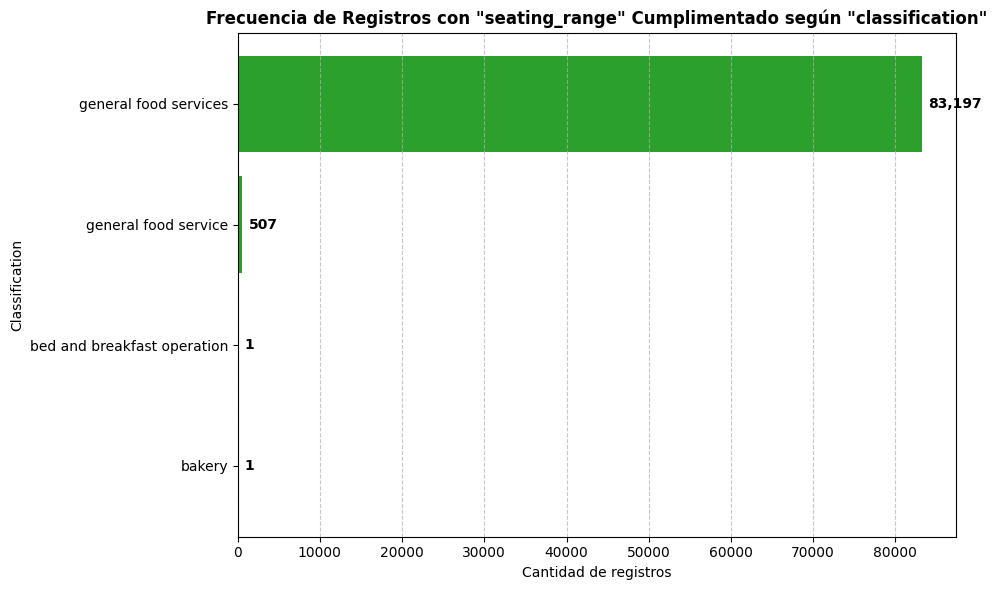

In [ ]:
filtro_con_seating = (
    raw["seating_range"].notna()
    & (raw["seating_range"].astype(str).str.strip().str.lower() != "nan")
    & (raw["seating_range"].astype(str).str.strip() != "")
)

con_seating_raw = raw[filtro_con_seating]

# 2. Agrupar por 'classification' y contar registros
conteo_con_seating = con_seating_raw["classification"].value_counts(
    dropna=False
)

print("Datos agregados de clasificaciones con 'seating_range' informada:")
print(conteo_con_seating)

# 3. Dibujar gráfico de barras horizontal
plt.figure(figsize=(10, 6))
barras = plt.barh(
    conteo_con_seating.index.astype(str),
    conteo_con_seating.values,
    color="#2ca02c",
)

# Configuración del gráfico
plt.title(
    'Frecuencia de Registros con "seating_range" Cumplimentado según "classification"',
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Cantidad de registros", fontsize=10)
plt.ylabel("Classification", fontsize=10)
plt.gca().invert_yaxis()  # Mostrar la más frecuente arriba
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Añadir etiquetas con el valor exacto en cada barra
for barra in barras:
    xval = barra.get_width()
    plt.text(
        xval + (max(conteo_con_seating.values) * 0.01),
        barra.get_y() + barra.get_height() / 2,
        f"{xval:,}",
        ha="left",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

Además de detectar un error en los literales a normalizar, es posible concluir que no son valores nulos, sino que a esa categoría de establecimientos no se les aplica esa variable.

In [ ]:
# Corrijo los literales

raw["classification"] = raw["classification"].str.strip()
raw["classification"] = raw["classification"].str.lower()


raw.loc[raw["classification"].str.lower() == "general food service", "classification"] = "general food services"

raw.loc[raw["classification"].str.lower() == "general food services", "classification"] = "general food services"

# Unificar DFDO
raw.loc[raw["classification"].str.lower()=="dfdo",
   "classification"] = "dfdo exempt from billing"

In [ ]:

print("Conteo tras el renombrado:")
print(raw['classification'].value_counts().loc[lambda x: x.index.str.contains('dfdo', case=False)])

Conteo tras el renombrado:
classification
dfdo exempt from billing    55
Name: count, dtype: Int64


In [ ]:
# creo la clasificación "NOT_APPLICABLE " para seting_range para todas aquellas clasiffication que no sean "general food services"



mask = (
    (raw['classification'] != 'general food services'))

# Asigno NOT_APPLICABLE

raw.loc[mask, 'seating_range'] = 'NOT_APPLICABLE'

# Comprobar resultado
print("Filas modificadas:", mask.sum())
print("NaN en Seating Range después:", raw['seating_range'].isna().sum())

Filas modificadas: 23273
NaN en Seating Range después: 17


In [ ]:
seatting_range_null=raw[raw['seating_range'].isna()]
print(seatting_range_null)

                                  name inspection_date         classification  \
61314                     naan-n-curry      2022-04-13  general food services   
61313                     naan-n-curry      2023-04-27  general food services   
61312                     naan-n-curry      2024-10-10  general food services   
95611              thai by day express      2025-09-19  general food services   
95610              thai by day express      2026-03-02  general food services   
13419                  boss burger inc      2026-07-17  general food services   
44837  joban & supreet enterprises llc      2026-05-20  general food services   
46612                      kb espresso      2026-06-25  general food services   
14358                     buena market      2026-05-01  general food services   
35812           gravity coffee company      2026-05-08  general food services   
35813           gravity coffee company      2026-05-08  general food services   
81488               seattle 

In [ ]:
# Como en supuestos anteriores, establecemos la norma de imputar el seating_range si es nulo por business_id, y si no por la moda

gfs_mask = raw['classification'].astype(str).str.strip().str.lower().isin(['general food services'])

nombre = raw.dropna(subset=['seating_range']).groupby('business_id')['seating_range'].first()
raw.loc[gfs_mask & raw['seating_range'].isna(), 'seating_range'] = raw['business_id'].map(nombre)

moda_gfs = raw.loc[gfs_mask & raw['seating_range'].notna(), 'seating_range'].mode()[0]

# Para el resto, la moda.
raw.loc[gfs_mask & raw['seating_range'].isna(), 'seating_range'] = moda_gfs

print(f"Moda para GENERAL FOOD SERVICES: {moda_gfs}")
print("Nulos restantes en Seating Range:", raw.loc[gfs_mask, 'seating_range'].isna().sum())

Moda para GENERAL FOOD SERVICES: 13-50
Nulos restantes en Seating Range: 0


2. PARCEL NUMBER

In [ ]:
#  VISUALIZAMOS PRIMERO QUÉ REPRESENTA

col = "parcel_number"

print("CALIDAD")
print(f"Filas: {len(raw):,}")
print(f"No nulos: {raw[col].notna().sum():,}")
print(f"% no nulos: {raw[col].notna().mean()*100:.2f}%")
print(f"Parcel Numbers únicos: {raw[col].nunique(dropna=True):,}")

print("\nValores más frecuentes:")
print(raw[col].value_counts(dropna=True).head(20))

CALIDAD
Filas: 106,994
No nulos: 106,632
% no nulos: 99.66%
Parcel Numbers únicos: 6,257

Valores más frecuentes:
parcel_number
7.666205e+09    829
2.823049e+09    678
7.666206e+09    670
1.985200e+09    442
2.725059e+09    393
9.202470e+09    393
2.625059e+09    330
9.240591e+08    299
1.544100e+09    296
3.230492e+08    296
3.123059e+09    258
8.700220e+09    247
4.323350e+09    239
9.250493e+08    238
3.148650e+09    235
2.725059e+09    227
7.137830e+09    200
1.321039e+09    199
2.822059e+09    192
4.037401e+09    184
Name: count, dtype: int64


In [ ]:
# veo cuántos negocios y cuántas inspecciones se han hecho en esas parcelas

parcel_business = (
    raw.dropna(subset=["parcel_number"])
      .groupby("parcel_number")
      .agg(
          businesses=("business_id", "nunique"),
          inspections=("inspection_serial_num", "nunique")
      )
      .sort_values("businesses", ascending=False)
)

print(parcel_business.head(30))

               businesses  inspections
parcel_number                         
7.666205e+09          122          800
2.823049e+09           95          566
7.666206e+09           87          574
3.260591e+08           73          145
1.985200e+09           61          410
3.230492e+08           60          196
9.202470e+09           50          296
8.700220e+09           48          186
2.625059e+09           39          205
7.933300e+09           34          132
5.503000e+09           33          112
9.250493e+08           29          175
1.773102e+09           29          101
1.544100e+09           28          165
3.573200e+09           24           80
3.123059e+09           24          130
9.240591e+08           22          143
2.725059e+09           22          123
1.221049e+09           22          108
4.323350e+09           22          126
7.137830e+09           21          138
2.821049e+09           19          105
9.420006e+08           18          155
1.225059e+09           18

In [ ]:
# exploro la relación de parcel_number con las inspecciones que se han podido repetir en esos negocios

parcel_history = (
    raw.dropna(subset=["parcel_number"])
      .groupby("parcel_number")
      .agg(
          businesses=("business_id", "nunique"),
          first_date=("inspection_date", "min"),
          last_date=("inspection_date", "max"),
          inspections=("inspection_serial_num", "nunique")
      )
)

print(
    parcel_history
    .sort_values(["businesses", "inspections"], ascending=False)
    .head(30)
)

               businesses first_date  last_date  inspections
parcel_number                                               
7.666205e+09          122 2021-07-07 2026-07-31          800
2.823049e+09           95 2021-01-04 2026-07-02          566
7.666206e+09           87 2021-04-07 2026-07-22          574
3.260591e+08           73 2021-10-30 2026-07-06          145
1.985200e+09           61 2021-10-31 2026-03-17          410
3.230492e+08           60 2021-09-05 2026-08-25          196
9.202470e+09           50 2021-05-10 2026-08-07          296
8.700220e+09           48 2021-04-09 2026-08-26          186
2.625059e+09           39 2021-05-11 2026-08-27          205
7.933300e+09           34 2022-08-22 2026-08-27          132
5.503000e+09           33 2022-12-06 2026-08-12          112
9.250493e+08           29 2021-03-18 2026-06-17          175
1.773102e+09           29 2021-11-23 2026-08-21          101
1.544100e+09           28 2021-04-29 2026-07-20          165
3.123059e+09           2

In [ ]:
# y ahora relaciono las parcelas con el riesgo de tener inspecciones con peores resultados

parcel_risk = (
    raw.dropna(subset=["parcel_number"])
      .groupby("parcel_number")
      .agg(
          inspections=("inspection_serial_num", "nunique"),
          businesses=("business_id", "nunique"),
          avg_score=("inspection_score", "mean"),
          avg_violations=("violation_points", "mean"),
          max_violations=("violation_points", "max")
      )
)

# Evitamos parcelas con muy pocas inspecciones
parcel_risk_10 = parcel_risk[
    parcel_risk["inspections"] >= 10
]

print(
    parcel_risk_10
    .sort_values("avg_violations", ascending=False)
    .head(30)
)

               inspections  businesses  avg_score  avg_violations  \
parcel_number                                                       
3.320001e+09            10           1  39.555556       12.666667   
2.044500e+09            10           1  31.052632       12.368421   
1.604601e+09            11           1  25.666667       12.000000   
1.702901e+09            11           1  18.076923       11.923077   
5.247801e+09            13           2  36.666667       11.666667   
2.156400e+09            19           2  37.916667       11.500000   
9.528104e+09            10           1  55.161290       11.064516   
4.385700e+09            13           1  55.069767       10.976744   
6.899300e+09            12           2  46.515152       10.939394   
7.792200e+09            13           1  38.742857       10.857143   
2.124700e+09            12           1  20.000000       10.588235   
5.589900e+09            11           1  26.388889       10.555556   
7.210590e+08            10        

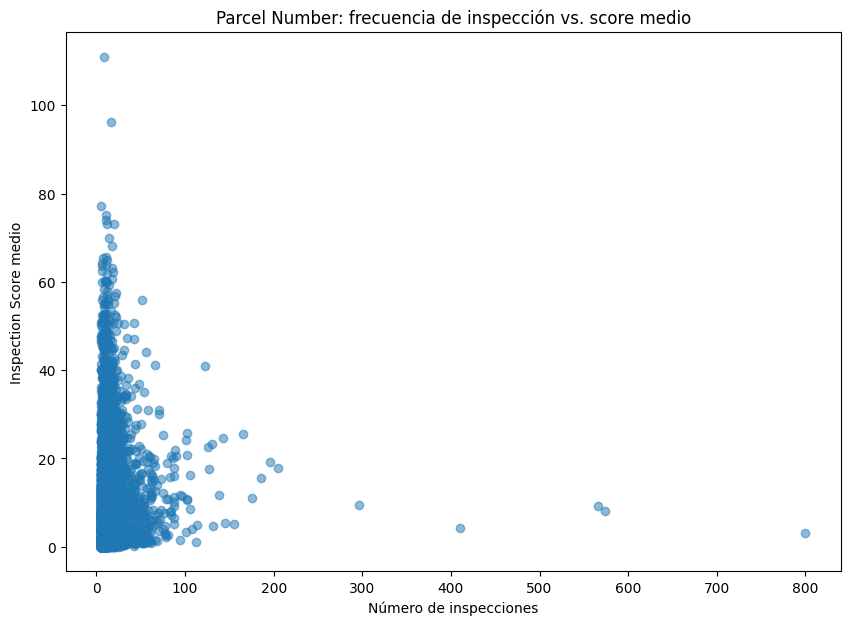

In [ ]:
# visualizo el resultado y las parcelas de los extremos deberían ser de interés para los inspectores

import matplotlib.pyplot as plt

plot_data = parcel_risk[
    parcel_risk["inspections"] >= 5
]

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data["inspections"],
    plot_data["avg_score"],
    alpha=0.5
)

plt.xlabel("Número de inspecciones")
plt.ylabel("Inspection Score medio")
plt.title("Parcel Number: frecuencia de inspección vs. score medio")

plt.show()

In [ ]:
# ahora para verificar la utilidad de la variable vemos si la ubicación en esas parcelas puede ser significativa para predecir la reincidencia


raw = raw.sort_values(
    ["parcel_number", "inspection_date"]
)

# Resultado anterior de la parcela
raw["previous_score"] = (
  raw.groupby("parcel_number")["inspection_score"]
      .shift(1)
)

raw["previous_violations"] = (
    raw.groupby("parcel_number")["violation_points"]
      .shift(1)
)

print(
    raw[
        ["parcel_number",
         "inspection_date",
         "inspection_score",
         "previous_score",
         "violation_points",
         "previous_violations"]
    ].head(20)
)

print(
    raw[
        ["inspection_score", "previous_score",
         "violation_points", "previous_violations"]
    ].corr()
)

       parcel_number inspection_date  inspection_score  previous_score  \
82865       200017.0      2021-04-15                 0             NaN   
1062        200017.0      2021-04-15                10             0.0   
82864       200017.0      2021-08-17                 5            10.0   
1061        200017.0      2021-08-17                 0             5.0   
82863       200017.0      2022-03-15                 0             0.0   
1060        200017.0      2022-03-15                 5             0.0   
1059        200017.0      2022-07-26                 0             5.0   
82861       200017.0      2022-08-16                15             0.0   
82862       200017.0      2022-08-16                15            15.0   
1058        200017.0      2022-12-28                10            15.0   
82860       200017.0      2023-05-04                 5            10.0   
1057        200017.0      2023-05-08                10             5.0   
82859       200017.0      2023-09-28  

In [ ]:
parcel_profile = (
    raw.dropna(subset=["parcel_number"])
      .groupby("parcel_number")
      .agg(
          inspections=("inspection_serial_num", "nunique"),
          businesses=("business_id", "nunique"),
          avg_score=("inspection_score", "mean"),
          avg_violations=("violation_points", "mean"),
          first_inspection=("inspection_date", "min"),
          last_inspection=("inspection_date", "max")
      )
)

parcel_profile["years_active"] = (
    parcel_profile["last_inspection"]
    - parcel_profile["first_inspection"]
).dt.days / 365.25

parcel_profile["inspections_per_year"] = (
    parcel_profile["inspections"]
    / parcel_profile["years_active"].clip(lower=1)
)

parcel_profile.sort_values(
    "avg_violations",
    ascending=False
).head(20)

,inspections,businesses,avg_score,avg_violations,first_inspection,last_inspection,years_active,inspections_per_year
parcel_number,,,,,,,,
2.823049e+09,1,1,30.000000,15.000000,2026-05-04,2026-05-04,0.000000,1.000000
8.113100e+09,4,1,36.428571,13.571429,2025-04-25,2026-03-24,0.911704,4.000000
2.230001e+08,3,1,13.333333,13.333333,2022-11-15,2025-07-25,2.691307,1.114700
1.453601e+09,5,1,50.833333,12.916667,2021-09-30,2026-06-04,4.676249,1.069233
6.003001e+09,6,1,17.142857,12.857143,2021-05-06,2026-03-12,4.848734,1.237436
3.107400e+09,8,1,39.611111,12.833333,2023-05-02,2026-08-25,3.315537,2.412882
3.320001e+09,10,1,39.555556,12.666667,2021-09-30,2026-03-27,4.487337,2.228493
2.011401e+09,5,1,40.000000,12.500000,2025-04-15,2026-05-07,1.059548,4.718992
1.221000e+09,5,1,15.833333,12.500000,2021-11-19,2025-04-30,3.444216,1.451709


Dado que sí parece que parcel number puede ser útil para detectar las concentraciones de infracciones, estudio mecanismos para reducir el número de nulos

In [ ]:
# primero explorando si por business id puedo localizarlo

print("Nulos antes:", raw["parcel_number"].isna().sum())

# Para cada Business_ID, obtener el Parcel Number conocido
parcel_por_business = (
    raw.dropna(subset=["parcel_number"])
      .groupby("business_id")["parcel_number"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

# Rellenar los nulos usando Business_ID
raw["parcel_number"] = (
    raw["parcel_number"]
    .fillna(raw["business_id"].map(parcel_por_business))
)

print("Nulos después:", raw["parcel_number"].isna().sum())


Nulos antes: 362
Nulos después: 362


In [ ]:
# como no se ha subsnado ninguno utilizamos otras alternativas

import pandas as pd

# ahora buscamos si es posible hacerlo por la vía de la dirección y la ciudad , pero sólo para las parcel number que se corresponden con la misma dirección


raw["address_key"] = (
    raw["address"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
raw["city_key"] = (
    raw["city"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

# Solo direcciones que tienen un único Parcel Number
parcel_por_direccion = (
    raw[raw["parcel_number"].notna()]
    .groupby(["address_key", "city_key"])["parcel_number"]
    .agg(["nunique", "first"])
)

parcel_por_direccion = parcel_por_direccion[
    parcel_por_direccion["nunique"] == 1
]["first"]


# Rellenar restantes
mask = raw["parcel_number"].isna()


for idx in raw.index[mask]:
    key = (
        raw.at[idx, "address_key"],
        raw.at[idx, "city_key"]
    )

    if key in parcel_por_direccion.index:
        raw.at[idx, "parcel_number"] = parcel_por_direccion.loc[key]

        if "parcel_source" not in raw.columns:
            raw["parcel_source"] = pd.NA
        raw.at[idx, "parcel_source"] = "address"


# -------------------------------------------------------
# RESULTADO
# -------------------------------------------------------

print("\n=== RESULTADO ===")

# Solo imprimir si 'parcel_source' existe
if "parcel_source" in raw.columns:
    print(
        raw["parcel_source"].value_counts()
    )
else:
    print("No se imputó ningún 'parcel_source' en esta etapa.")

print(
    f"\nNulos finales: "
    f"{raw['parcel_number'].isna().sum():,}"
)

print(
    f"Porcentaje nulos final: "
    f"{raw['parcel_number'].isna().mean()*100:.2f}%"
)


=== RESULTADO ===
parcel_source
address    41
Name: count, dtype: int64

Nulos finales: 321
Porcentaje nulos final: 0.30%


Como sabemos que hay 16 mil actas que tienen documentadas más de una infracción, exploro si por esta vía pueso cumplimentar el parcel_number

In [ ]:
# Registros que tienen Parcel Number vacío
sin_parcel = raw[raw["parcel_number"] == ""].copy()

# Registros que sí tienen Parcel Number
con_parcel = raw[raw["parcel_number"] != ""].copy()

# Buscar coincidencias de Inspection_Serial_Num
coincidencias = sin_parcel.merge(
    con_parcel[["inspection_serial_num", "parcel_number"]],
    on="inspection_serial_num",
    how="inner",
    suffixes=("_vacio", "_encontrado")
)

# Mostrar los resultados
print(coincidencias[
    ["inspection_serial_num", "parcel_number_encontrado"]
].drop_duplicates())

Empty DataFrame
Columns: [inspection_serial_num, parcel_number_encontrado]
Index: []


Como no habría ninguno optamos por identifcar esos parcel number sin información como desconocido

In [ ]:
raw['parcel_number'] = raw['parcel_number'].fillna('unknown')

RISK_CATEGORY

El porcentaje de nulos es pequeño, pero para intentar decidir qué hacer con los nulos, vamos a ver de qué depende, comenzando por clasificación que podría ser determinante por la tipología de establecimiento analizada

In [ ]:
 raw["risk_category"].isna().sum()

np.int64(626)

In [ ]:
pd.crosstab(
    raw['classification'],
    raw['risk_category'],
    normalize='index'
).round(3)

risk_category,1.0,2.0,3.0
classification,,,
bakery,0.005,0.836,0.159
bed and breakfast operation,1.000,0.000,0.000
catering operation,0.029,0.048,0.923
dfdo exempt from billing,0.036,0.018,0.945
general food services,0.033,0.078,0.889
grocery store,0.791,0.209,0.000
meat/fish market,0.000,0.000,1.000
mobile food unit,0.120,0.073,0.808
nonprofit institution,0.127,0.090,0.783


In [ ]:
print(raw['risk_category'].value_counts(dropna=False))

risk_category
3.0    89538
2.0     9319
1.0     7511
NaN      626
Name: count, dtype: int64


In [ ]:

# primero intentamos ver si por business_id es posible rellenarlo

raw["risk_category"] = (
    raw["risk_category"]
    .astype("string")
    .str.strip()
)
raw["risk_category_was_missing"] = (
    raw["risk_category"]
    .isna()
    .astype(int)
)

raw["risk_category_imputed"] = (
    raw
    .groupby("business_id")["risk_category"]
    .ffill()
)





In [ ]:

 raw["risk_category"].isna().sum()

np.int64(626)

Como no ha sido posible, y existen aparentememte varios factores que influyen las imputo con randomforest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix
)



# Variables predictoras

risk_categorical = [
    "classification",
    "inspection_type",
    "inspection_closed_business",
    "seating_range",
    "grade",
    "city"
]

risk_numeric = [
    "inspection_score",
    "violation_points"
]

risk_features = (
    risk_categorical +
    risk_numeric
)


# ------------------------------------------------------------
# Dataset conocido
# ------------------------------------------------------------

risk_features_available = [
    col for col in risk_features
    if col in raw.columns
]

risk_categorical_available = [
    col for col in risk_categorical
    if col in raw.columns
]

risk_numeric_available = [
    col for col in risk_numeric
    if col in raw.columns
]

print("Variables utilizadas:")
print(risk_features_available)

known = raw[
    raw["risk_category"].notna()
].copy()

missing = raw[
    raw["risk_category"].isna()
].copy()

print("\nRegistros con Risk Category conocida:", len(known))
print("Registros con Risk Category nula:", len(missing))

X = known[risk_features_available].copy()
y = known["risk_category"].astype(str).str.strip()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            categorical_transformer,
            risk_categorical_available
        ),
        (
            "num",
            numeric_transformer,
            risk_numeric_available
        )
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_features="sqrt"
)

# Definir el pipeline combinando el preprocesador y el modelo
risk_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf_model)])

risk_pipeline.fit(
    X_train,
    y_train
)


y_pred_valid = risk_pipeline.predict(X_valid)

accuracy = accuracy_score(
    y_valid,
    y_pred_valid
)

balanced_accuracy = balanced_accuracy_score(
    y_valid,
    y_pred_valid
)

print("\n==============================")
print("EVALUACIÓN DEL MODELO")
print("==============================")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_pred_valid,
        zero_division=0
    )
)

print("\nMatriz de confusión:")
print(
    confusion_matrix(
        y_valid,
        y_pred_valid
    )
)

# ------------------------------------------------------------
# 11. Preparar los 626 registros con Risk Category nula
# ------------------------------------------------------------

X_missing = missing[
    risk_features_available
].copy()


# ------------------------------------------------------------
# 12. Predecir Risk Category para los registros nulos
# ------------------------------------------------------------

predicted_risk = risk_pipeline.predict(
    X_missing
)


# ------------------------------------------------------------
# 13. Obtener probabilidad de la predicción
# ------------------------------------------------------------

predicted_probabilities = (
    risk_pipeline.predict_proba(X_missing)
)

prediction_confidence = (
    predicted_probabilities.max(axis=1)
)


# ------------------------------------------------------------
# 14. Guardar la imputación
# ------------------------------------------------------------

raw.loc[
    raw["risk_category"].isna(),
    "risk_category"
] = predicted_risk


# ------------------------------------------------------------
# 15. Registrar que esos valores fueron imputados
# ------------------------------------------------------------

raw["risk_category_imputed"] = (
    raw["risk_category_was_missing"]
    .fillna(0)
    .astype(int)
)

# Inicializar columna de confianza
raw["risk_category_imputation_confidence"] = np.nan

missing_indices = missing.index

raw.loc[
    missing_indices,
    "risk_category_imputation_confidence"
] = prediction_confidence


# ------------------------------------------------------------
# 16. Comprobación final
# ------------------------------------------------------------

print("\n==============================")
print("RESULTADO DE LA IMPUTACIÓN")
print("==============================")

print(
    "\nValores imputados:",
    len(predicted_risk)
)

print(
    "Nulos restantes en Risk Category:",
    raw["risk_category"].isna().sum()
)

print(
    "\nDistribución final de Risk Category:"
)

print(
    raw["risk_category"].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 17. Distribución de las categorías imputadas
# ------------------------------------------------------------

print(
    "\nDistribución de las 626 categorías imputadas:"
)

print(
    pd.Series(
        predicted_risk,
        name="risk_category_imputada"
    ).value_counts()
)


# ------------------------------------------------------------
# 18. Resumen de confianza de las imputaciones
# ------------------------------------------------------------

print(
    "\nConfianza media de las imputaciones:",
    f"{prediction_confidence.mean():.4f}"
)

print(
    "Imputaciones con confianza >= 0.80:",
    (prediction_confidence >= 0.80).sum()
)

print(
    "Imputaciones con confianza >= 0.90:",
    (prediction_confidence >= 0.90).sum()
)

Variables utilizadas:
['classification', 'inspection_type', 'inspection_closed_business', 'seating_range', 'grade', 'city', 'inspection_score', 'violation_points']

Registros con Risk Category conocida: 106368
Registros con Risk Category nula: 626

EVALUACIÓN DEL MODELO

Accuracy: 0.7218
Balanced Accuracy: 0.6905

Classification Report:
              precision    recall  f1-score   support

         1.0       0.37      0.77      0.50      1502
         2.0       0.23      0.57      0.33      1864
         3.0       0.97      0.73      0.83     17908

    accuracy                           0.72     21274
   macro avg       0.52      0.69      0.56     21274
weighted avg       0.86      0.72      0.77     21274


Matriz de confusión:
[[ 1153   210   139]
 [  478  1063   323]
 [ 1475  3294 13139]]

RESULTADO DE LA IMPUTACIÓN

Valores imputados: 626
Nulos restantes en Risk Category: 0

Distribución final de Risk Category:
risk_category
3.0    90139
2.0     9337
1.0     7518
Name: count, dt

In [ ]:
 raw.isna().sum()

,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,12
inspection_type,0
inspection_score,0
inspection_result,0
inspection_closed_business,0


GRADE

In [ ]:
# Primero analizamos en qué supuestos se producen los nulos y si es posible establecer alguna característica que compartan las inspecciones en las que esa información no se suministra


raw['grade_clean'] = raw['grade'].fillna('NOT RATED').astype(str).str.strip().str.lower()

# Identificar si una calificación se considera 'no clasificada'
raw['is_not_rated'] = raw['grade_clean'].isin(['NOT RATED', 'RATING NOT AVAILABLE', 'NAN', 'NONE'])

# Porcentaje de NOT RATED por Clasificación de Establecimiento
analisis_clasificacion = pd.crosstab(
    raw['classification'],
    raw['is_not_rated'],
    normalize='index'
) * 100

# Crear un mapeo para los nombres de las columnas para hacerlas más descriptivas
column_rename_map = {
    False: '% Evaluado con Nota',
    True: '% Estado Administrativo NOT RATED'
}

# Renombrar las columnas que existen en el resultado de la tabla cruzada

analisis_clasificacion = analisis_clasificacion.rename(columns=column_rename_map).copy()

# Añadir columnas con 0% si faltan (por ejemplo, si no hay casos True o False)
if '% Evaluado con Nota' not in analisis_clasificacion.columns:
    analisis_clasificacion['% Evaluado con Nota'] = 0.0
if '% Estado Administrativo NOT RATED' not in analisis_clasificacion.columns:
    analisis_clasificacion['% Estado Administrativo NOT RATED'] = 0.0

# Asegurar el orden deseado de las columnas para una salida consistente
analisis_clasificacion = analisis_clasificacion[[
    '% Evaluado con Nota',
    '% Estado Administrativo NOT RATED'
]]

print(analisis_clasificacion.sort_values(by='% Estado Administrativo NOT RATED', ascending=False).round(2))

is_not_rated                    % Evaluado con Nota  \
classification                                        
bakery                                        100.0   
bed and breakfast operation                   100.0   
catering operation                            100.0   
commissary kitchen                            100.0   
commissary kitchen exempt from                100.0   
dfdo exempt from billing                      100.0   
general food services                         100.0   
grocery store                                 100.0   
limited food service                          100.0   
meat/fish market                              100.0   
mobile food unit                              100.0   
nonprofit institution                         100.0   
school lunch program                          100.0   

is_not_rated                    % Estado Administrativo NOT RATED  
classification                                                     
bakery                                

Dado que es evidente que existen una serie de clasificaciones que no se evaluan, vamos a separar el tratamiento de esos nulos

In [ ]:
CLASIFICACIONES_SIN_NOTA = [
    'school lunch program', 'grocery store', 'nonprofit institution',
    'bed and breakfast operation', 'commissary kitchen',
    'dfdo exempt from billing', 'commissary kitchen exempt from'
]

# 1. Normalizar nulos e inconsistencias a la categoría explícita 'NOT_RATED'
variantes_not_rated = ['Not Rated', 'Rating Not Available', 'NOT RATED', ' NOT_RATED', 'rating not available',' rating not available', 'rating not available', 'not rated', 'RATING NOT AVAILABLE']
raw['grade_treated'] = raw['grade'].replace(variantes_not_rated, 'NOT_RATED')

#
# Si pertenece a una categoría exenta de nota, forzar 'NOT_RATED'
mask_exentos = raw['classification'].isin(CLASIFICACIONES_SIN_NOTA)
raw.loc[mask_exentos, 'grade_treated'] = 'NOT_RATED'

# 3. Marcar si la ausencia de nota es por normativa
raw['is_exempt_from_rating'] = raw['classification'].isin(CLASIFICACIONES_SIN_NOTA).astype(int)

print("\nDistribución final de Grade_Treated:")
print(raw['grade_treated'].value_counts())


Distribución final de Grade_Treated:
grade_treated
excellent           45285
good                32407
okay                15708
NOT_RATED           12371
needs to improve     1223
Name: count, dtype: Int64


ZIP CODE

In [ ]:
# Al ser tan pocos los registros los localizamos
zip_code_null=raw[raw['zip_code'].isna()]
print(zip_code_null)


                                                 name inspection_date  \
88975                                   subway #26996      2026-05-14   
80706              san wok espress chinese restaurant      2026-08-24   
106861                             zoco cafe and wine      2026-04-10   
24416   deleo pizza company, llc dba deleo bros pizza      2025-10-07   
24415   deleo pizza company, llc dba deleo bros pizza      2026-06-10   
36149                                green apple deli      2026-04-02   
36150                                green apple deli      2026-04-02   
36151                                green apple deli      2026-04-02   
36152                                green apple deli      2026-04-02   
54565                                 makai island co      2026-03-05   
65531                                 pal-man kitchen      2026-06-08   
88272                       stoup brewing seatac city      2026-07-07   

               classification                     

In [ ]:
# como todos tienen ciudad y dirección, establecemos la regla de imputar el por id_businnes y si no código dominante en que la ciudad sean coincidentes


zip_code_by_business = ( raw.dropna(subset=["name", "business_id", "zip_code"])
 .groupby(["name", "business_id"])["zip_code"]
 .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )

# primero business id

mask_zip_code_null = raw["zip_code"].isna()
raw.loc[mask_zip_code_null, "zip_code"] = (
raw.loc[mask_zip_code_null]
    .set_index(["name", "business_id"])
    .index .map(zip_code_by_business) .to_numpy() )

# Si no es posible, código postal predominante

zip_code_by_city = (
    raw.dropna(subset=["city", "zip_code"])
     .groupby("city")["zip_code"]
     .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA) )


mask_zip_code_null = raw["zip_code"].isna()
raw.loc[mask_zip_code_null, "zip_code"] = (
    raw.loc[mask_zip_code_null, "city"]
    .map(zip_code_by_city)
)

# Y si no tienen tampoco zip_code lo elimino

raw=raw.dropna(subset=["zip_code"])

# lo guardo:

raw.to_csv("dataset_con_sip_code_imputado.csv", index=False)

In [ ]:
raw.isnull().sum()

,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
inspection_type,0
inspection_score,0
inspection_result,0
inspection_closed_business,0


VIOLATION TYPE_VIOLATION DESCRIPCION
Todo parede apuntar a que los nulos realmente se trata de supuestos en los que no se ha cometido una infracción

In [ ]:
descripcion_vacia = (
    raw["violation_description"].isna() |
    (raw["violation_description"].astype(str).str.strip() == "")
)

tipo_vacio = (
    raw["violation_type"].isna() |
    (raw["violation_type"].astype(str).str.strip() == "")

  )


# Registros donde AL MENOS UNO de los dos campos está vacío
filtro = descripcion_vacia | tipo_vacio

# Normalizar inspection_result
resultado = (
    raw["inspection_result"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Contar los resultados
satisfactory = (filtro & (resultado == "satisfactory")).sum()
complete = (filtro & (resultado == "complete")).sum()
unsatisfactory = (filtro & (resultado == "unsatisfactory")).sum()

print("satisfactory:", satisfactory)
print("complete:", complete)
print("unsatisfactory:", unsatisfactory)

print("Total con algún campo de violación vacío:", filtro.sum())

satisfactory: 37442
complete: 2294
unsatisfactory: 74
Total con algún campo de violación vacío: 39810


In [ ]:
# depuro los nulos para los supuestos en los que el resultado es "satisfactory"

satisfactory_mask = raw["inspection_result"] == "satisfactory"

raw.loc[satisfactory_mask & raw["violation_type"].isna(), "violation_type"] = "no violation"


raw.loc[satisfactory_mask & raw["violation_description"].isna(), "violation_description"] = "no violation"

print("Updated null counts for 'violation_type' and 'violation_description' after handling 'satisfactory' inspections:")
print(f"violation_type nulls: {raw['violation_type'].isnull().sum()}")
print(f"violation_description nulls: {raw['violation_description'].isnull().sum()}")


print("\nSample of rows with 'satisfactory' result and now 'no violation':")
print(raw[(satisfactory_mask) & (raw['violation_type'] == 'no violation')][
    ['inspection_result', 'violation_type', 'violation_description']
].head())

Updated null counts for 'violation_type' and 'violation_description' after handling 'satisfactory' inspections:
violation_type nulls: 2368
violation_description nulls: 2368

Sample of rows with 'satisfactory' result and now 'no violation':
      inspection_result violation_type violation_description
82865      satisfactory   no violation          no violation
1061       satisfactory   no violation          no violation
82863      satisfactory   no violation          no violation
1059       satisfactory   no violation          no violation
82858      satisfactory   no violation          no violation


In [ ]:
# analizo qué sucede en los supuestos en los que el resultado es unsatisfactory pero no hay descripción de la violación
filtro = (
    (raw["inspection_result"].str.lower().str.strip() == "unsatisfactory")
    &
    (
        raw["violation_description"].isna()
        |
        (raw["violation_description"].astype(str).str.strip() == "")
    )
    &
    (
        raw["violation_type"].isna()
        | (raw["violation_type"].astype(str).str.strip() == "")
    )
)

inspecciones_filtradas = raw[filtro]

# Número de inspecciones
print(
    f"Número de inspecciones 'unsatisfactory' sin descripción: {len(inspecciones_filtradas)}"
)

Número de inspecciones 'unsatisfactory' sin descripción: 74


In [ ]:
filas_73=raw[filtro]
print(filas_73)

                                            name inspection_date  \
81378                         seatac cuisine llc      2023-07-19   
84418                       skooder's hotdog co.      2025-12-05   
21441                                 coffee bae      2025-09-23   
42951                         iyara thai cuisine      2024-12-09   
66735   pasion tequila family mexican restaurant      2026-05-27   
70978                     potbelly sandwich shop      2022-12-06   
4684                             amazon block 21      2023-12-22   
13458                 bothell senior high school      2022-11-07   
10393                           beehive espresso      2024-02-09   
39758   honey bear vietnamese sandwich - banh mi      2023-02-13   
93732                     taqueria jalisco i llc      2023-07-12   
85208                              soa's kitchen      2024-10-24   
44119                              java junction      2024-07-23   
49131               la fogata maple valley, inc.

In [ ]:
# me cercioro de que tampoco hay violations points registrados

#ahora verifico si en alguna de esas filas hay documentada algún punto vulnerado
conteo_puntos = filas_73["violation_points"].value_counts(
    dropna=False
)

print("Valores de 'violation_points' y su frecuencia:")
print(conteo_puntos)

Valores de 'violation_points' y su frecuencia:
violation_points
0    74
Name: count, dtype: int64


Es posible concluir que esos registros son realmente inspecciones satisfactorias, y lo solventamos estableciendo esa regla.

In [ ]:
raw.loc[filtro, "inspection_result"] = "satisfactory"
raw.loc[filtro, "violation_description"] = "no violation"
raw.loc[filtro, "violation_type"] = "no violation"

Ahora analizo lo sucedido con las inspecciones que aún quedan con resultado complete

In [ ]:
filas_complete = (
    (raw["inspection_result"].str.lower().str.strip() == "complete")
    &
    (
        raw["violation_description"].isna()
        |
        (raw["violation_description"].astype(str).str.strip() == "")
    )
    &
    (
        raw["violation_type"].isna()
        | (raw["violation_type"].astype(str).str.strip() == "")
    )
)

inspecciones_filtradas = raw[filas_complete]
# Número de inspecciones
print(
    f"Número de inspecciones 'complete' sin descripción ni tipo vulnerado: {len(inspecciones_filtradas)}"
)

Número de inspecciones 'complete' sin descripción ni tipo vulnerado: 2294


In [ ]:
# hacemos el mismo tratamiento

filas_complete_casos = filas_complete
print(filas_complete_casos)

82865    False
1062     False
82864    False
1061     False
82863    False
         ...  
27685    False
63935     True
50678    False
50679    False
81257    False
Length: 106994, dtype: boolean


In [ ]:
filas_complete = raw[filas_complete]
print(filas_complete)

                       name inspection_date         classification  \
104828           wok & bowl      2026-06-17  general food services   
68292           pho emerald      2026-07-17  general food services   
67586     performance grill      2026-08-25  general food services   
38264   haveli indian grill      2026-03-04  general food services   
25437              disfruta      2026-03-04  general food services   
...                     ...             ...                    ...   
81488    seattle bento pops      2026-07-27  general food services   
45832     k-vibe korean bbq      2026-08-06  general food services   
23102             crespella      2026-08-11  general food services   
82485    seoul bowl redmond      2026-08-19  general food services   
63935       oh yeah banh mi      2026-08-26  general food services   

                             address       city zip_code  \
104828       18012 w valley hwy, 103       kent    98032   
68292                   1525 a st ne   

In [ ]:
conteo_puntos = filas_complete["violation_points"].value_counts(
    dropna=False
)

print("Valores de 'violation_points' y su frecuencia:")
print(conteo_puntos)

Valores de 'violation_points' y su frecuencia:
violation_points
0    2294
Name: count, dtype: int64


Al igual que en el caso anterior, estos registros se guardaron como colete pero no hay infracción, por lo que hacemos el mismo tratamiento

In [ ]:
filtro_complete_zero = (
    # Requisito 1: inspection_result es "complete"
    (raw["inspection_result"].str.lower().str.strip() == "complete")
    &
    # Requisito 2: violation_points es 0
    (pd.to_numeric(raw["violation_points"], errors="coerce") == 0)
    &
    # Requisito 3: violation_description vacío o NaN
    (
        raw["violation_description"].isna()
        | (raw["violation_description"].astype(str).str.strip() == "")
    )
    &
    # Requisito 4: violation_type vacío o NaN
    (
        raw["violation_type"].isna()
        | (raw["violation_type"].astype(str).str.strip() == "")
    )
)

# Modificar los valores de las columnas mediante .loc[]
raw.loc[filtro_complete_zero, "inspection_result"] = "satisfactory"
raw.loc[filtro_complete_zero, "violation_description"] = "no violation"
raw.loc[filtro_complete_zero, "violation_type"] = "no violation"


In [ ]:
# analizo ahora el resultado de los registros que quedan como "complete"

conteo_complete = (raw['inspection_result'].astype(str).str.strip().str.lower() == 'complete').sum()
print(f"Total de inspecciones con resultado 'Complete': {conteo_complete}")

Total de inspecciones con resultado 'Complete': 153


In [ ]:
# con un número tan pequeño vemos si es posible integrarlas en alguna de las dos clasificaciones, bajo el criterio de si tiene documentadas violaciones, registrarla como unsatisfactory o viceversa

es_complete = raw['inspection_result'].astype(str).str.strip().str.lower() == 'complete'

# Normalizar columnas de violación a minúsculas y sin espacios
v_type = raw['violation_type'].astype(str).str.strip().str.lower()
v_desc = raw['violation_description'].astype(str).str.strip().str.lower()

# Evaluar si existe una violación registrada (excluyendo vacíos, NaN o "no violation")
valores_nulos_o_limpios = ['', 'nan', 'none', 'no violation']
tiene_violacion = es_complete & (~v_type.isin(valores_nulos_o_limpios) | ~v_desc.isin(valores_nulos_o_limpios))
sin_violacion = es_complete & ~tiene_violacion

# Reclasificar resultados
raw.loc[tiene_violacion, 'inspection_result'] = 'unsatisfactory'
raw.loc[sin_violacion, 'inspection_result'] = 'satisfactory'

# Confirmar cambios
print("\nNueva distribución de 'Inspection Result':")
print(raw['inspection_result'].value_counts())


Nueva distribución de 'Inspection Result':
inspection_result
satisfactory      54731
unsatisfactory    52263
Name: count, dtype: Int64


VALORES ATÍPICOS

In [ ]:

# localización de valores atípicos en variables numéricas

variables_numericas = [
    "inspection_score",
    "violation_points",
    "risk_category"
]

print("\nResumen estadístico:")
print(raw[variables_numericas].describe())



Resumen estadístico:
       inspection_score  violation_points
count     106994.000000     106994.000000
mean          15.574098          4.614735
std           21.398360          5.737112
min           -1.000000          0.000000
25%            0.000000          0.000000
50%            8.000000          5.000000
75%           23.000000          5.000000
max          167.000000         25.000000


In [ ]:
# localizo los valores atípicos numéricos para detectar si son errores

# 1. Inspection Score = -1
score_menos_uno = raw[raw["inspection_score"] == -1]

# 2. Inspection Score > 23
score_mayor_23 = raw[raw["inspection_score"] > 23]

# 3. Violation Points > 5
violation_mayor_5 = raw[raw["violation_points"] > 5]

# MOSTRAR RESULTADOS


print("==============================================")
print("INSPECTION SCORE = -1")
print("==============================================")

print("Número de registros:", len(score_menos_uno))
print(score_menos_uno)


print("\n==============================================")
print("INSPECTION SCORE > 23")
print("==============================================")

print("Número de registros:", len(score_mayor_23))
print(score_mayor_23)


print("\n==============================================")
print("VIOLATION POINTS > 5")
print("==============================================")

print("Número de registros:", len(violation_mayor_5))
print(violation_mayor_5)

INSPECTION SCORE = -1
Número de registros: 1
                  name inspection_date         classification  \
57515  menuderia maria      2024-12-09  general food services   

                  address        city zip_code    inspection_type  \
57515  23060 pacifc hwy s  des moines    98198  return inspection   

       inspection_score inspection_result inspection_closed_business  \
57515                -1      satisfactory                         no   

      seating_range risk_category violation_type violation_description  \
57515         13-50           3.0   no violation          no violation   

       violation_points grade parcel_number     business_id  \
57515                 0  okay  2500600250.0  pfe-pr-3146132   

      inspection_serial_num inspection_result_clean  has_violation_row  \
57515         pfe-dasjpfagj          unsatisfactory              False   

      city_original_inicial          address_normalized city_original  \
57515            des moines  23060 PACIFC 

El valor negativo en el campo "inspection_score" se trata de un error humano pues de los datos de la inspección refleja que la inspección ha sido insatisfactoria pero no se incorpora ninguna violation_description ni violation points  .

In [ ]:
# elimino el registro con valor de inspección negativo
raw = raw[raw["inspection_score"] >= 0]


if "program_identifier" in raw.columns:
    raw.drop("program_identifier", axis=1, inplace=True)

INFRACCIONES A NIVEL ACTA

In [ ]:
#Creamos primero la condición a nivel de acta para no decidir
#sobre Complete fila a fila.
inspection_flags = (
    raw.groupby("inspection_serial_num")
       .agg(
           has_violation=("has_violation_row", "any"),
           total_violation_points=("violation_points", "sum"),
           original_result=("inspection_result", "first")
       )
)

def clean_inspection_result(row):
    result = row["original_result"]
    if result == "complete":
        return "unsatisfactory" if (row["has_violation"] or row["total_violation_points"] > 0) else "satisfactory"
    if result == "unsatisfactory" and (not row["has_violation"]) and row["total_violation_points"] == 0:
        return "satisfactory"
    return result

inspection_flags["inspection_result"] = inspection_flags.apply(
    clean_inspection_result, axis=1
)

print("\nResultado original a nivel de acta:")
print(inspection_flags["original_result"].value_counts(dropna=False))

print("\nResultado tras limpieza:")
print(inspection_flags["inspection_result"].value_counts(dropna=False))



Resultado original a nivel de acta:
original_result
satisfactory      50569
unsatisfactory    21499
Name: count, dtype: Int64

Resultado tras limpieza:


KeyError: 'inspection_result'

GENERACIÓN DATASET LIMPIO

In [ ]:
dataset_limpio_final = raw.copy()

variables_auxiliares = (
    ["city_original_inicial",
     "city_original",
     "city_was_imputed",
     "city_imputation_method",
     "city_imputation_confidence",
     "address_normalized",
      "address_key",
      "city_key",
      "parcel_source",
      "risk_category_was_missing",
      "risk_category_imputed",
      "risk_category_imputation_confidence",
     "previous_score",
     "previous_violations",
     ]
)

variables_auxiliares_existentes = [
    col for col in variables_auxiliares if col in dataset_limpio_final.columns
]

dataset_limpio_final = dataset_limpio_final.drop(columns=variables_auxiliares_existentes)

# compruebo las columnas

print("=" * 70)
print("DATASET LIMPIO FINAL")
print("=" * 70)
print(
    f"Número de registros: "
    f"{dataset_limpio_final.shape[0]:,}"
)
print(
    f"Número de variables: "
    f"{dataset_limpio_final.shape[1]}"
)

print("\nVariables incluidas:")

for i, col in enumerate(
    dataset_limpio_final.columns, start=1
):
    print(f"{i:02d}. {col}")

# verifico los nulos

resumen_nulos = (
    dataset_limpio_final
    .isna().sum().to_frame("nulos")
)
resumen_nulos["porcentaje"] = (
    resumen_nulos["nulos"] / len(dataset_limpio_final) * 100
).round(2)

print("\n" + "=" * 70)
print("VALORES NULOS DEL DATASET FINAL")
print("=" * 70)
display(resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("porcentaje", ascending=False))

# compruebo los duplicados

print("\n" + "=" * 70)
print("DUPLICADOS")
print("=" * 70)
print("Registros duplicados:", dataset_limpio_final.duplicated().sum())

#lo guardo:

dataset_limpio_final.to_csv("dataset_limpio_final.csv", index=False)

# lo visualizo

display(dataset_limpio_final.head())

DATASET LIMPIO FINAL
Número de registros: 106,993
Número de variables: 25

Variables incluidas:
01. name
02. inspection_date
03. classification
04. address
05. city
06. zip_code
07. inspection_type
08. inspection_score
09. inspection_result
10. inspection_closed_business
11. seating_range
12. risk_category
13. violation_type
14. violation_description
15. violation_points
16. grade
17. parcel_number
18. business_id
19. inspection_serial_num
20. inspection_result_clean
21. has_violation_row
22. grade_clean
23. is_not_rated
24. grade_treated
25. is_exempt_from_rating

VALORES NULOS DEL DATASET FINAL


,nulos,porcentaje



DUPLICADOS
Registros duplicados: 0


,name,inspection_date,classification,address,city,zip_code,inspection_type,inspection_score,inspection_result,inspection_closed_business,seating_range,risk_category,violation_type,violation_description,violation_points,grade,parcel_number,business_id,inspection_serial_num,inspection_result_clean,has_violation_row,grade_clean,is_not_rated,grade_treated,is_exempt_from_rating
82865,shake & go,2021-04-15,general food services,"18012 68th ave s, #104",kent,98032,routine inspection/field review,0,satisfactory,no,13-50,3.0,no violation,no violation,0,excellent,200017.0,pfe-pr-3138895,pfe-da0u3ipj4,satisfactory,False,excellent,False,excellent,0
1062,7-eleven - 34144b,2021-04-15,general food services,18012 west valley hwy s,kent,98032,routine inspection/field review,10,unsatisfactory,no,0-12,3.0,red,0600 - adequate handwashing facilities,10,good,200017.0,pfe-pr-3139238,pfe-dahxbl9q8,unsatisfactory,True,good,False,good,0
82864,shake & go,2021-08-17,general food services,"18012 68th ave s, #104",kent,98032,routine inspection/field review,5,satisfactory,no,13-50,3.0,blue,"4200 - food-contact surfaces maintained, clean...",5,excellent,200017.0,pfe-pr-3138895,pfe-dazkqykkj,satisfactory,True,excellent,False,excellent,0
1061,7-eleven - 34144b,2021-08-17,general food services,18012 west valley hwy s,kent,98032,routine inspection/field review,0,satisfactory,no,0-12,3.0,no violation,no violation,0,good,200017.0,pfe-pr-3139238,pfe-daewlg038,satisfactory,False,good,False,good,0
82863,shake & go,2022-03-15,general food services,"18012 68th ave s, #104",kent,98032,routine inspection/field review,0,satisfactory,no,13-50,3.0,no violation,no violation,0,excellent,200017.0,pfe-pr-3138895,pfe-dat7mwiy3,satisfactory,False,excellent,False,excellent,0


Descartada la correlación completa entre ellas, vamos a analizar qué variables resultan determinantes para nuestra variable objetivo, primero analizando su frecuencia. Para ello, definimos el concepto de reincidencia y teniendo en cuenta que existen actas con más de una inspección.

CARDINALIDAD

In [ ]:
# análisis de la cardinalidad

cardinalidad = pd.DataFrame({
    "Tipo de dato": dataset_limpio_final.dtypes,
    "Nº registros": len(dataset_limpio_final),
    "Valores únicos": dataset_limpio_final.nunique(dropna=True),
    "Valores nulos": dataset_limpio_final.isnull().sum(),
})

# Porcentaje de cardinalidad
cardinalidad["% cardinalidad"] = (
    cardinalidad["Valores únicos"] / len(dataset_limpio_final) * 100
).round(2)

# Porcentaje de nulos
cardinalidad["% nulos"] = (
    cardinalidad["Valores nulos"] / len(dataset_limpio_final) * 100
).round(2)

# Ordenar de mayor a menor cardinalidad
cardinalidad = cardinalidad.sort_values(
    by="Valores únicos",
    ascending=False
)

print(cardinalidad)

                              Tipo de dato  Nº registros  Valores únicos  \
inspection_serial_num       string[python]        106993           72068   
business_id                 string[python]        106993           12298   
name                        string[python]        106993            9728   
address                     string[python]        106993            9366   
parcel_number                       object        106993            6258   
inspection_date             datetime64[ns]        106993            1666   
inspection_score                     int64        106993             126   
zip_code                            object        106993             112   
city                        string[python]        106993              69   
violation_description       string[python]        106993              54   
classification              string[python]        106993              13   
violation_points                     int64        106993               7   
grade_clean 

In [ ]:
# Descripción de valores únicos
unique_violation_descriptions = dataset_limpio_final['violation_description'].unique()
print(unique_violation_descriptions)

<StringArray>
[                                                                                                                          'no violation',
                                                                                                 '0600 - adequate handwashing facilities',
                                                                            '4200 - food-contact surfaces maintained, cleaned, sanitized',
                                                        '0200 - food worker cards current for all food workers; new food workers trained',
                                                                    '3400 - wiping cloths properly used, stored; sanitizer concentration',
                                '2110 - proper cold holding temperatures; greater than 45 degrees fahrenheit (f) (7 degrees celsius (c))',
                          '2120 - proper cold holding temperatures; between 42 to 45 degrees fahrenheit (f) (6 to 7 degrees celsius (c))',
             

In [ ]:
unique_Classification = dataset_limpio_final['classification'].unique()
print(unique_Classification)

<StringArray>
[         'general food services',                  'grocery store',
               'mobile food unit',           'school lunch program',
               'meat/fish market',                         'bakery',
          'nonprofit institution',           'limited food service',
             'catering operation',             'commissary kitchen',
       'dfdo exempt from billing',    'bed and breakfast operation',
 'commissary kitchen exempt from']
Length: 13, dtype: string


In [ ]:
unique_violation_points = dataset_limpio_final['violation_points'].unique()
print(unique_violation_points)

[ 0 10  5 25  3  2 15]


In [ ]:
unique_grade= dataset_limpio_final['grade'].unique()
print(unique_grade)

<StringArray>
[           'excellent',                 'good',            'not rated',
 'rating not available',                 'okay',     'needs to improve']
Length: 6, dtype: string


In [ ]:
unique_seating_range= dataset_limpio_final['seating_range'].unique()
print(unique_seating_range)

<StringArray>
['13-50', '0-12', '51-150', 'NOT_APPLICABLE', '151-250', '> 250']
Length: 6, dtype: string


In [ ]:
unique_inspection_type= dataset_limpio_final['inspection_type'].unique()
print(unique_inspection_type)

<StringArray>
['routine inspection/field review',          'educational inspection',
               'return inspection']
Length: 3, dtype: string


In [ ]:
unique_Risk_category= dataset_limpio_final['risk_category'].unique()
print(unique_Risk_category)

<StringArray>
['3.0', '2.0', '1.0']
Length: 3, dtype: string


In [ ]:
unique_Inspection_result= dataset_limpio_final['inspection_result'].unique()
print(unique_Inspection_result)

<StringArray>
['satisfactory', 'unsatisfactory']
Length: 2, dtype: string


In [ ]:
unique_inpection_closed_business= dataset_limpio_final['inspection_closed_business'].unique()
print(unique_inpection_closed_business)

<StringArray>
['no', 'yes']
Length: 2, dtype: string


In [ ]:
unique_violation_type= dataset_limpio_final['violation_type'].unique()
print(unique_violation_type)

<StringArray>
['no violation', 'red', 'blue']
Length: 3, dtype: string


SUGERENCIAS LIMPIEZA DE DATOS

In [ ]:
impieza de datos
! pip install autoviz
from autoviz import data_cleaning_suggestions
data_cleaning_suggestions(dataset_limpio_final)

    Removing ['parcel_number'] column(s) due to mixed data type detected...
name of type=string is not classified
classification of type=string is not classified
address of type=string is not classified
city of type=string is not classified
inspection_type of type=string is not classified
inspection_result of type=string is not classified
inspection_closed_business of type=string is not classified
seating_range of type=string is not classified
risk_category of type=string is not classified
violation_type of type=string is not classified
violation_description of type=string is not classified
grade of type=string is not classified
business_id of type=string is not classified
inspection_serial_num of type=string is not classified
inspection_result_clean of type=string is not classified
grade_treated of type=string is not classified
No of columns classified 9 does not match 25 total cols. Continuing...
 Missing columns = ['name', 'classification', 'address', 'city', 'inspection_type', 'ins

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
name,string,0.000000,9,,,No issue
inspection_date,datetime64[ns],0.000000,1,,,Possible date-time colum: transform before modeling step.
classification,string,0.000000,0,,,No issue
address,string,0.000000,8,,,No issue
city,string,0.000000,0,,,No issue
zip_code,object,0.000000,0,,,Possible high cardinality column with 112 unique values: Use hash encoding or text embedding to reduce dimension.
inspection_type,string,0.000000,0,,,No issue
inspection_score,int64,0.000000,0,0.000000,167.000000,Column has 6278 outliers greater than upper bound (57.50) or lower than lower bound(-34.50). Cap them or remove them.
inspection_result,string,0.000000,0,,,No issue
inspection_closed_business,string,0.000000,0,,,No issue


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
name,string[python],0.0,9,,,No issue
inspection_date,datetime64[ns],0.0,1,,,Possible date-time colum: transform before modeling step.
classification,string[python],0.0,0,,,No issue
address,string[python],0.0,8,,,No issue
city,string[python],0.0,0,,,No issue
zip_code,object,0.0,0,,,Possible high cardinality column with 112 unique values: Use hash encoding or text embedding to reduce dimension.
inspection_type,string[python],0.0,0,,,No issue
inspection_score,int64,0.0,0,0.0,167.0,Column has 6278 outliers greater than upper bound (57.50) or lower than lower bound(-34.50). Cap them or remove them.
inspection_result,string[python],0.0,0,,,No issue
inspection_closed_business,string[python],0.0,0,,,No issue


ACTAS CON MÁS DE UNA INFRACCIÓN DOCUMENTADA
Dado que consta que existen varias filas para la misma inspección, se debe trabajar a nivel inspection_serial_num, con el fin de poder valorar realmente la reincidencia.

In [ ]:
 # Contabilización de actas con más de una infracción documentada

valores_repetidos = dataset_limpio_final['inspection_serial_num'].value_counts()

cantidad_valores_repetidos = (valores_repetidos > 1).sum()

print(f'Cantidad de inspection_serial_num distintos que están repetidos: {cantidad_valores_repetidos}')

Cantidad de inspection_serial_num distintos que están repetidos: 16431


In [ ]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def unique_join(s):
    vals = (
        s.dropna().astype(str).str.strip()
        .replace({"": np.nan})
        .dropna().unique()
    )
    return " | ".join(sorted(vals))

inspections = (
    dataset_limpio_final.sort_values(["business_id", "inspection_date", "inspection_serial_num"])
       .groupby("inspection_serial_num", as_index=False)
       .agg(
           business_id=("business_id", first_non_null),
           name=("name", first_non_null),
           inspection_date=("inspection_date", "first"),
           classification=("classification", first_non_null),
           address=("address", first_non_null),
           city=("city", first_non_null),
           zip_code=("zip_code", first_non_null),
           parcel_number=("parcel_number", first_non_null),
           inspection_type=("inspection_type", first_non_null),
           inspection_closed_business=("inspection_closed_business", first_non_null),
           seating_range=("seating_range", first_non_null),
           risk_category=("risk_category", first_non_null),
           inspection_score=("inspection_score", "first"),
           grade=("grade", first_non_null),
           violation_points=("violation_points", "sum"),
           number_violations=("has_violation_row", "sum"),
           violation_descriptions=("violation_description", unique_join),
           violation_types=("violation_type", unique_join),
           inspection_result=("inspection_result", "first"),
       )
)


# y normalizo las infracciones también a ese nivel
inspections["violation_set"] = (
    inspections["violation_descriptions"]
     .fillna("")
    .apply(lambda x: {v.strip() for v in x.split(" | ") if v.strip()})
)

inspections = inspections.sort_values(
    ["business_id", "inspection_date", "inspection_serial_num"]
).reset_index(drop=True)

print("Inspecciones:", f"{len(inspections):,}")
print("Establecimientos:", f"{inspections['business_id'].nunique():,}")
print("\nResultado:")
print(inspections["inspection_result"].value_counts())

Inspecciones: 72,068
Establecimientos: 12,298

Resultado:
inspection_result
satisfactory      50569
unsatisfactory    21499
Name: count, dtype: Int64


In [ ]:
inspections.isnull().sum()

,0
inspection_serial_num,0
business_id,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
parcel_number,0
inspection_type,0


ANÁLISIS DE LA PROBLÉMATICA: INSPECCIONES INSATISFACTORIAS Y REINCIDENCIA

In [ ]:
# Total de inspecciones insatisfactorias en porcentaje
total_unsatisfactory = (
    inspections["inspection_result"]
    .str.lower()
    .str.strip()
    .eq("unsatisfactory")
    .sum()
)

total_inspecciones = len(inspections)

porcentaje = (total_unsatisfactory / total_inspecciones) * 100

inspecciones_sin_descripcion = dataset_limpio_final[dataset_limpio_final["violation_description"].isnull()]
print("Total de inspecciones unsatisfactory:", total_unsatisfactory)
print("Total de inspecciones:", total_inspecciones)
print("Porcentaje de inspecciones unsatisfactory:", round(porcentaje, 2), "%")


Total de inspecciones unsatisfactory: 21499
Total de inspecciones: 72068
Porcentaje de inspecciones unsatisfactory: 29.83 %


intentamos reducir la cardinalidad

In [ ]:
import pandas as pd


categoricas_inspecciones = [
    'classification',
    'city',
    'zip_code',
    'inspection_type',
    'inspection_closed_business',
    'seating_range',
    'risk_category',
    'grade',
    'violation_types',
    'inspection_result'
]

for columna in categoricas_inspecciones:
    print("="*60)
    print(columna.capitalize())
    print("="*60)


    if columna in inspections.columns:
        display(inspections[columna].value_counts().head(10))
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")

    print("\n")

Classification


,count
classification,
general food services,52918
school lunch program,4469
grocery store,4387
meat/fish market,2975
mobile food unit,2747
nonprofit institution,1561
bakery,1254
catering operation,1202
limited food service,434




City


,count
city,
seattle,32903
bellevue,4489
kent,3703
federal way,3656
renton,3419
redmond,2894
kirkland,2855
auburn,2541
tukwila,1879




Zip_code


...

,count
grade,
excellent,37123
good,17934
not rated,10687
okay,5663
needs to improve,393
rating not available,268




Violation_types


,count
violation_types,
no violation,39809
red,11046
blue,10731
blue | red,10482




Inspection_result


,count
inspection_result,
satisfactory,50569
unsatisfactory,21499


Gráfico para: Classification


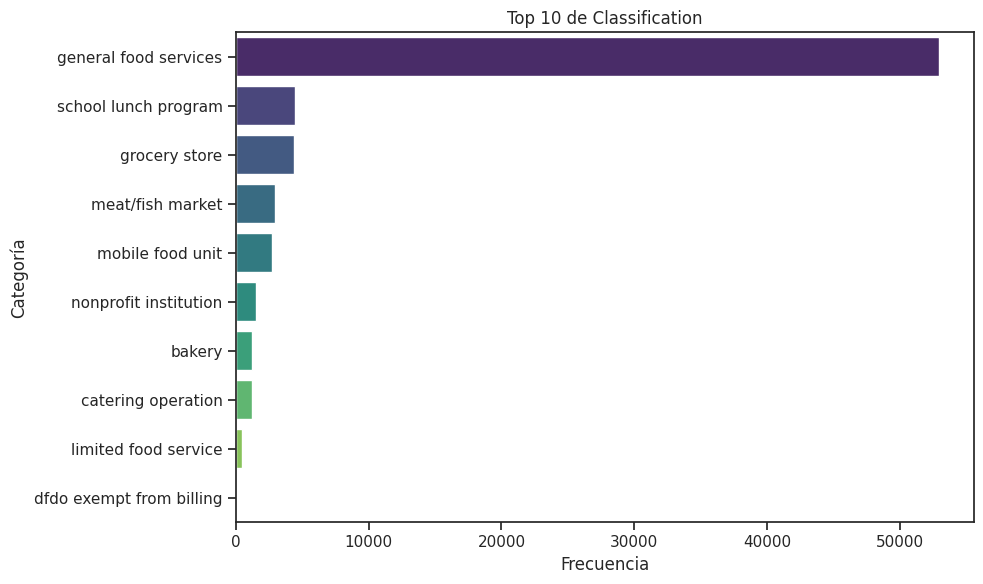



Gráfico para: City


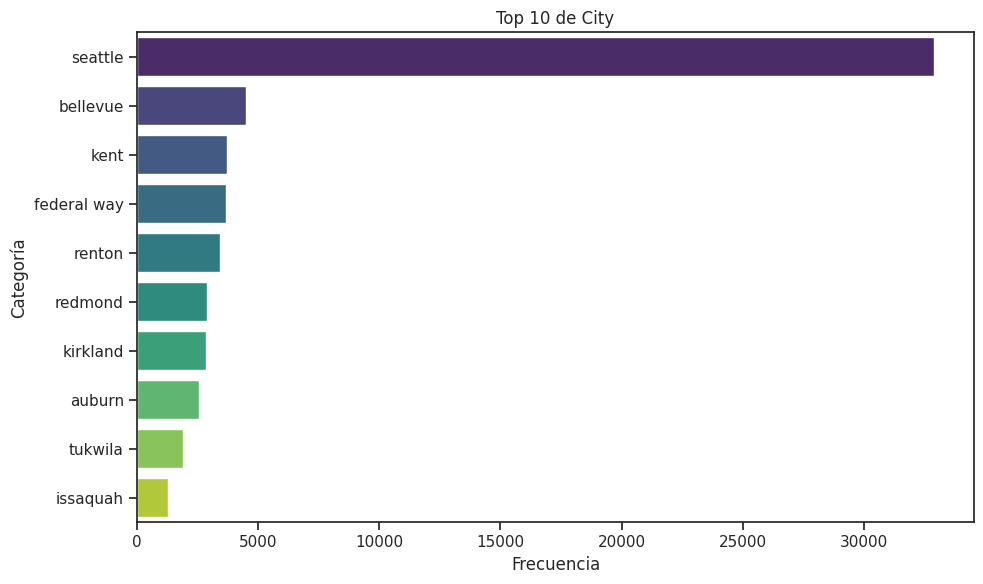



Gráfico para: Zip_code


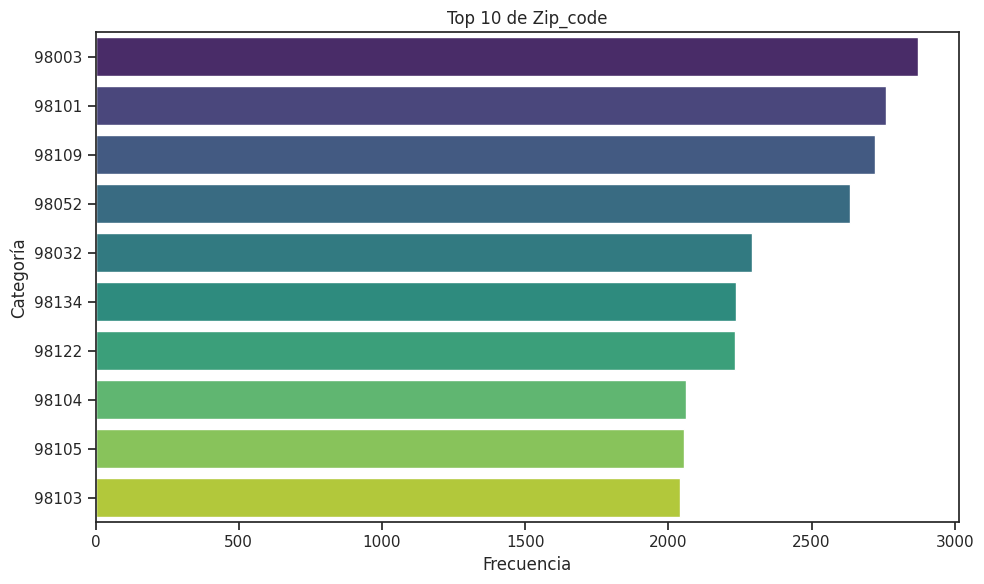



Gráfico para: Inspection_type


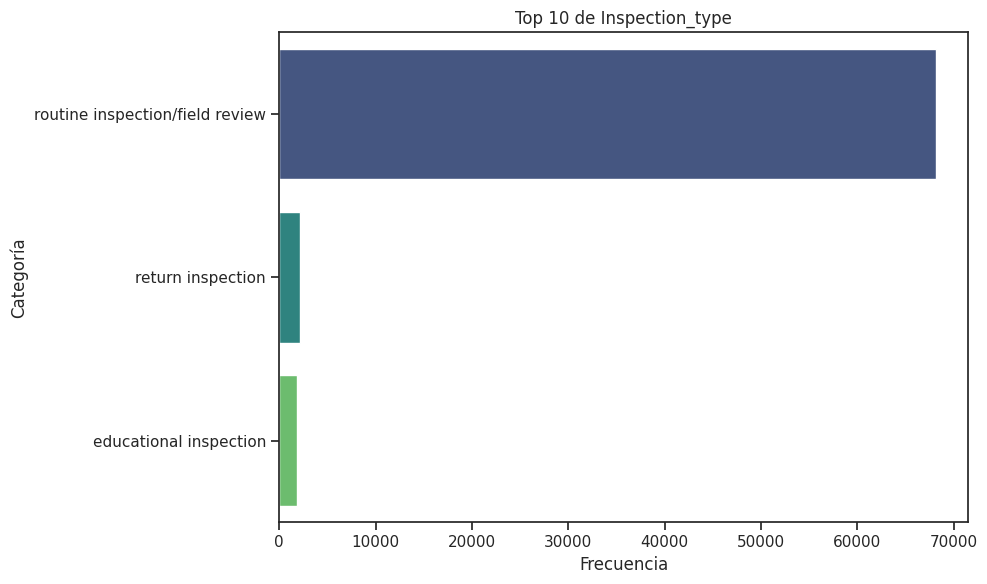



Gráfico para: Inspection_closed_business


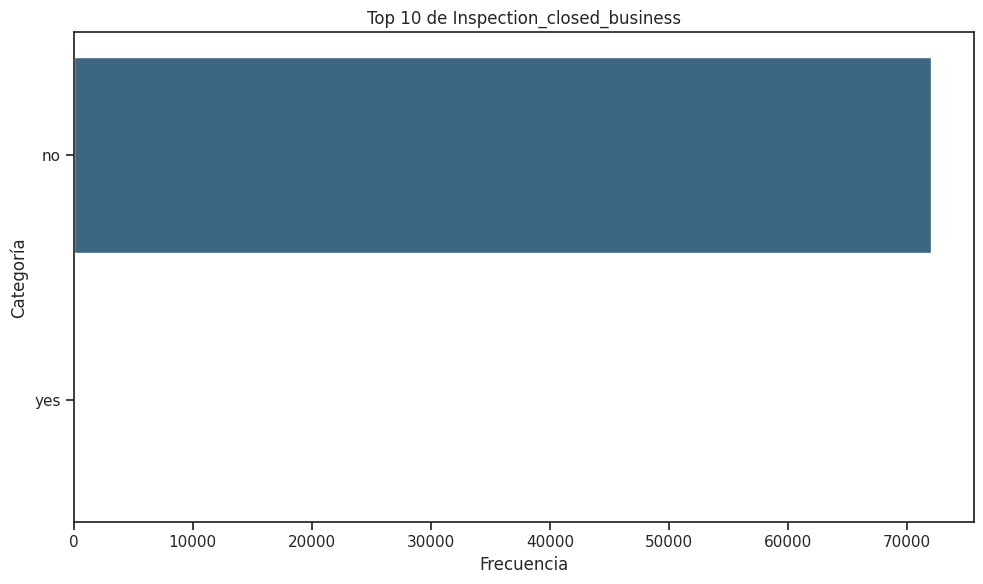



Gráfico para: Seating_range


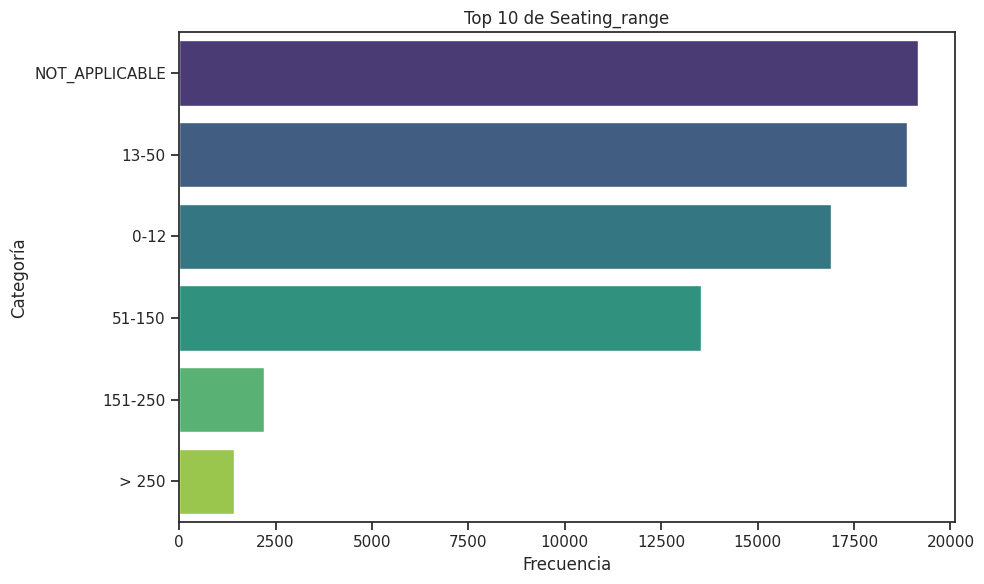



Gráfico para: Risk_category


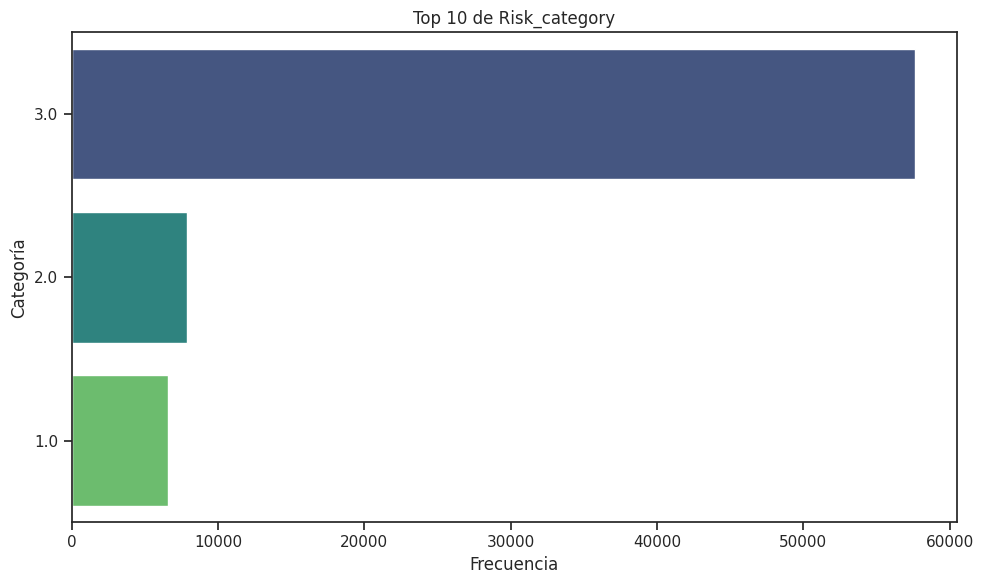



Gráfico para: Grade


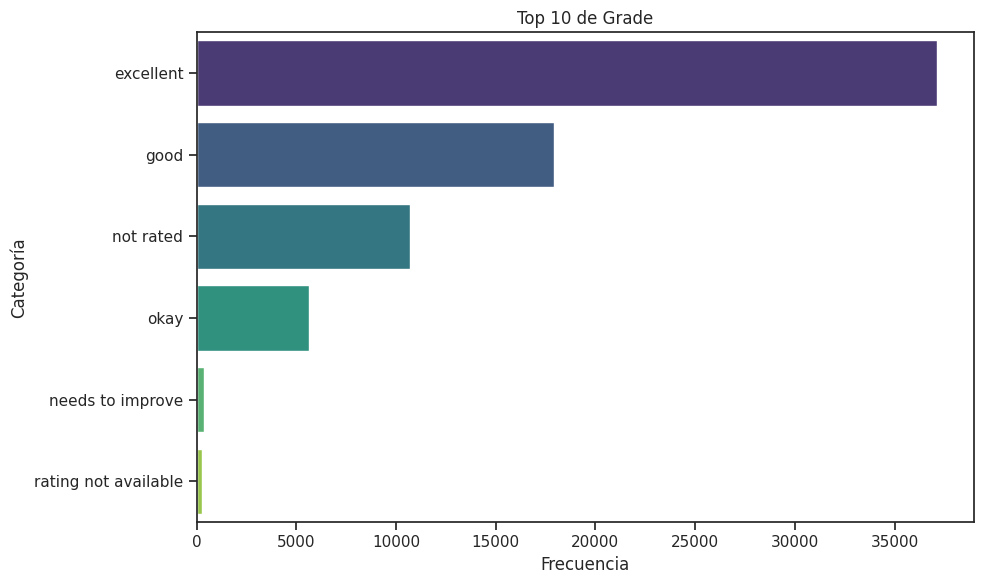



Gráfico para: Violation_types


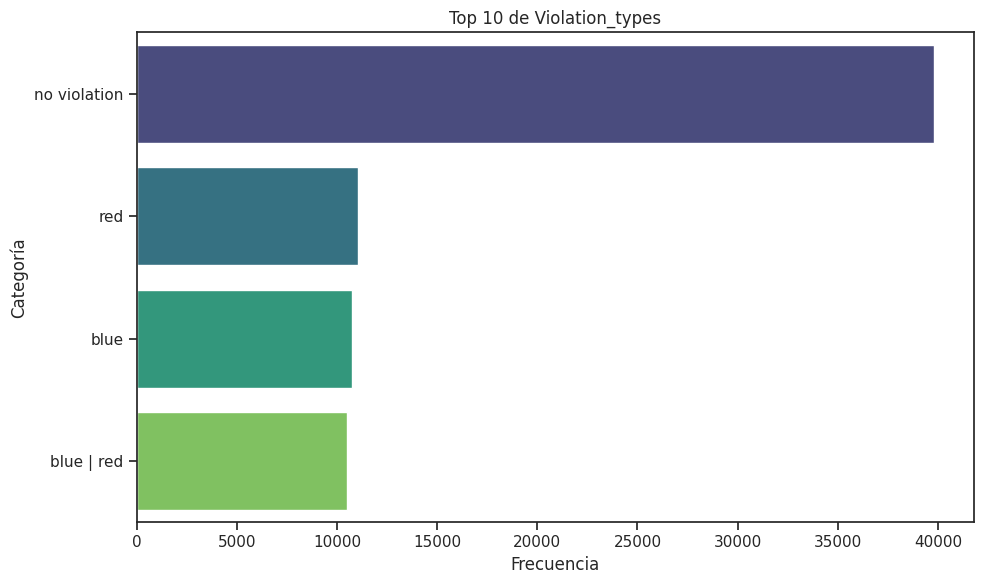



Gráfico para: Inspection_result


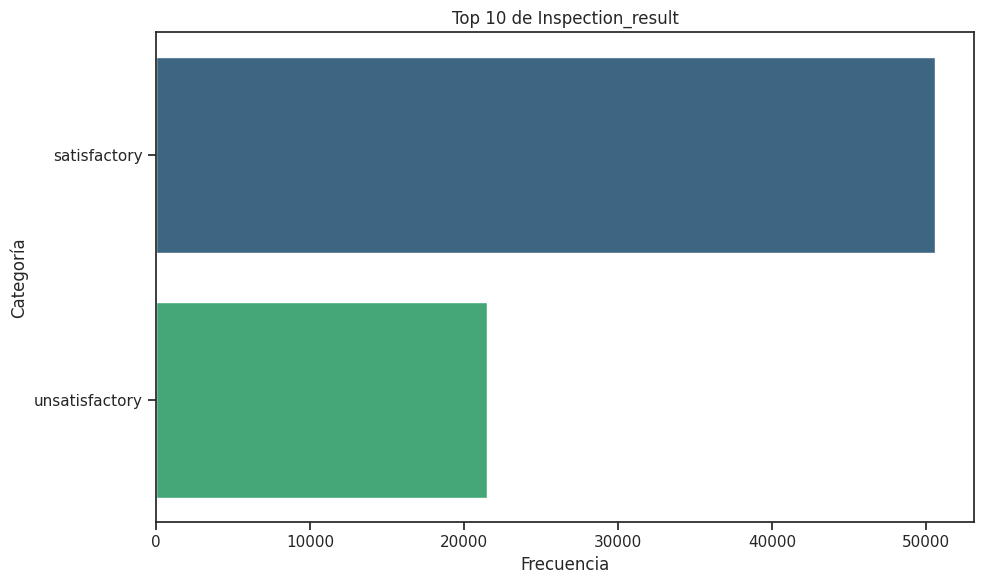

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

categoricas_inspecciones_para_grafico = [
    'classification',
    'city',
    'zip_code',
    'inspection_type',
    'inspection_closed_business',
    'seating_range',
    'risk_category',
    'grade',
    'violation_types',
    'inspection_result'
]

for columna in categoricas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico para: {columna.capitalize()}")
    print("="*60)

    if columna in inspections.columns:
        fig, ax = plt.subplots(figsize=(10, 6))

        top_values = inspections[columna].value_counts().head(10)

        if not top_values.empty:
            sns.barplot(
                x=top_values.values,
                y=top_values.index,
                palette="viridis",
                ax=ax
            )
            ax.set_title(f"Top 10 de {columna.capitalize()}")
            ax.set_xlabel("Frecuencia")
            ax.set_ylabel("Categoría")
            plt.tight_layout()
            display(fig)
            plt.close(fig)
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")

    print("\n")

Y ahora analizo la relación entre las categóricas y el resultado de la inspección

Gráfico de Proporción por Classification vs. Resultado de Inspección


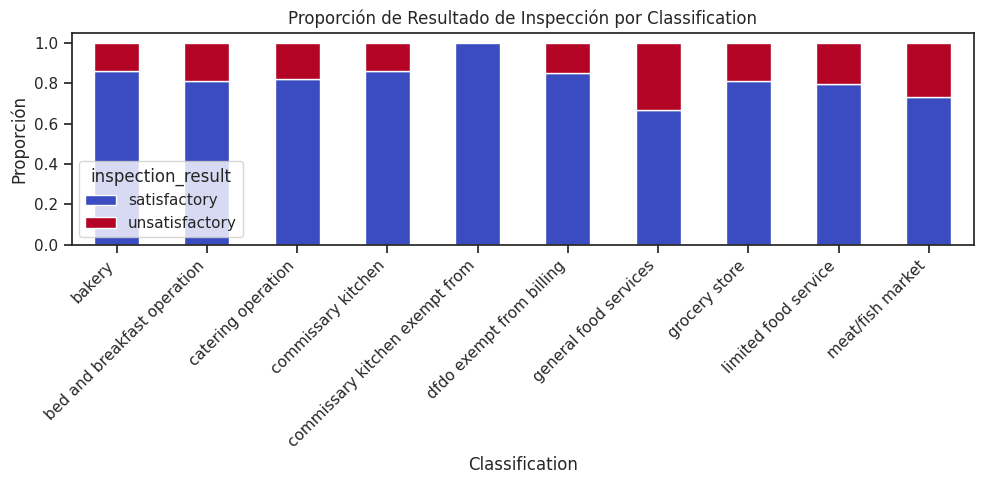



Gráfico de Proporción por City vs. Resultado de Inspección


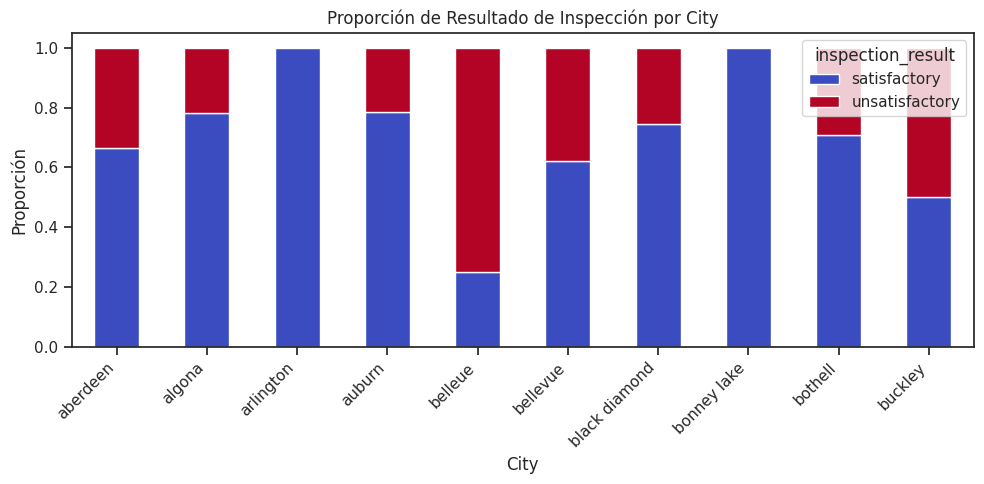



Gráfico de Proporción por Zip_code vs. Resultado de Inspección


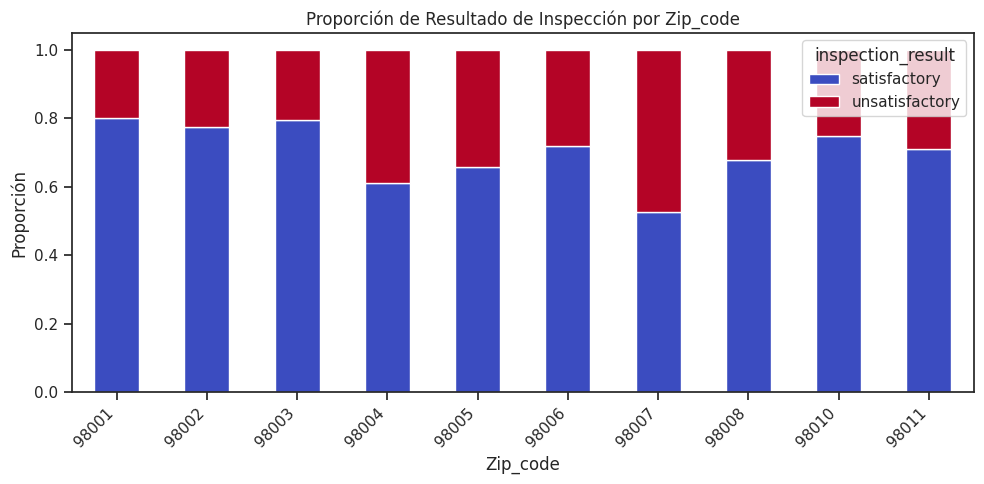



Gráfico de Proporción por Inspection_type vs. Resultado de Inspección


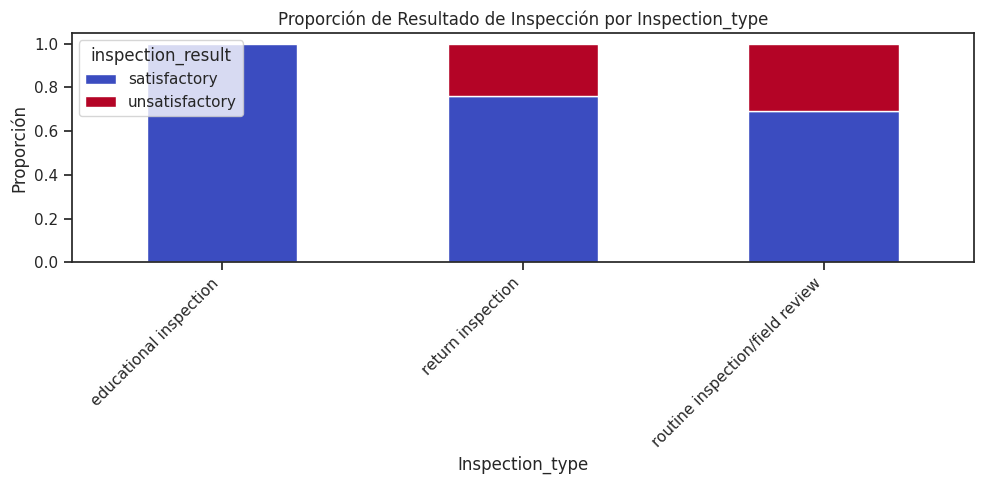



Gráfico de Proporción por Inspection_closed_business vs. Resultado de Inspección


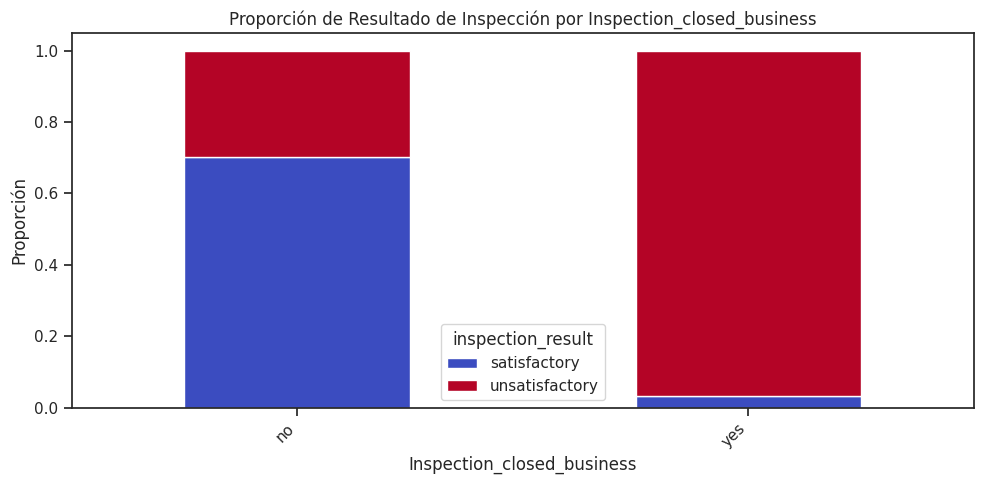



Gráfico de Proporción por Seating_range vs. Resultado de Inspección


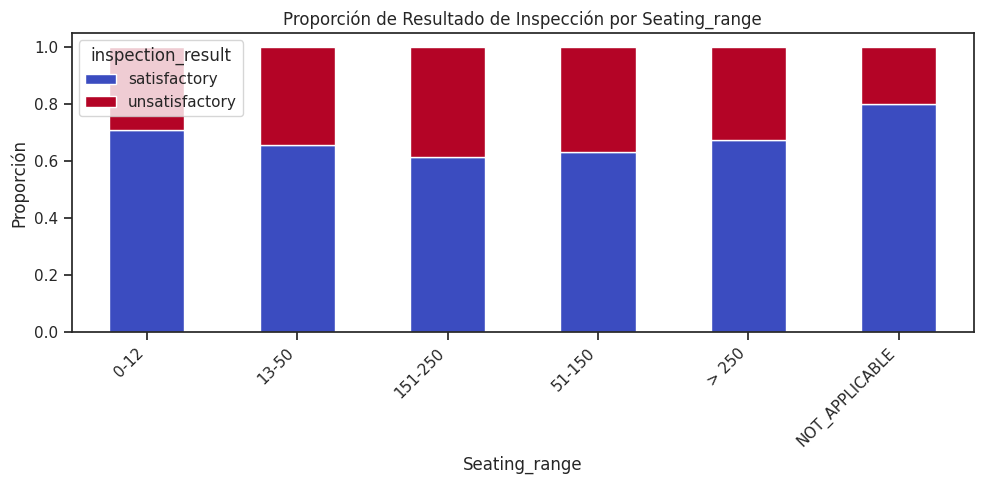



Gráfico de Proporción por Risk_category vs. Resultado de Inspección


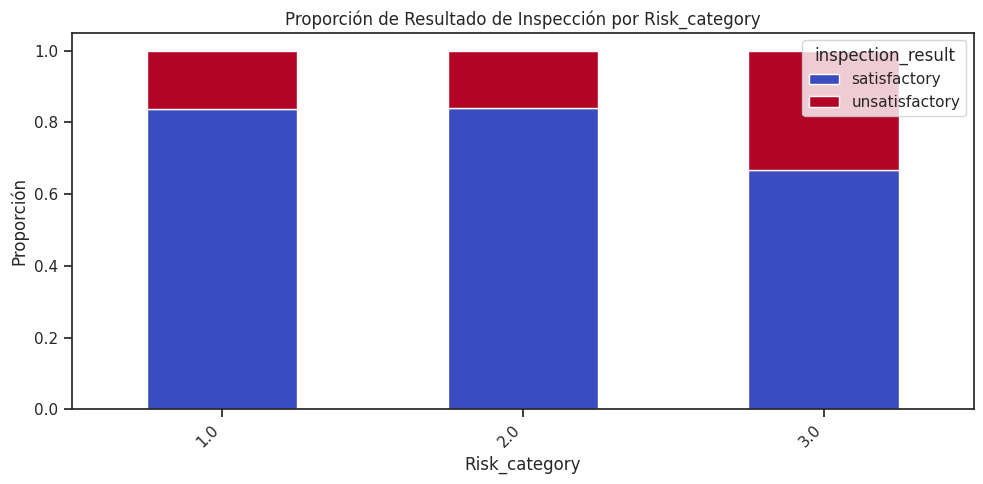



Gráfico de Proporción por Grade vs. Resultado de Inspección


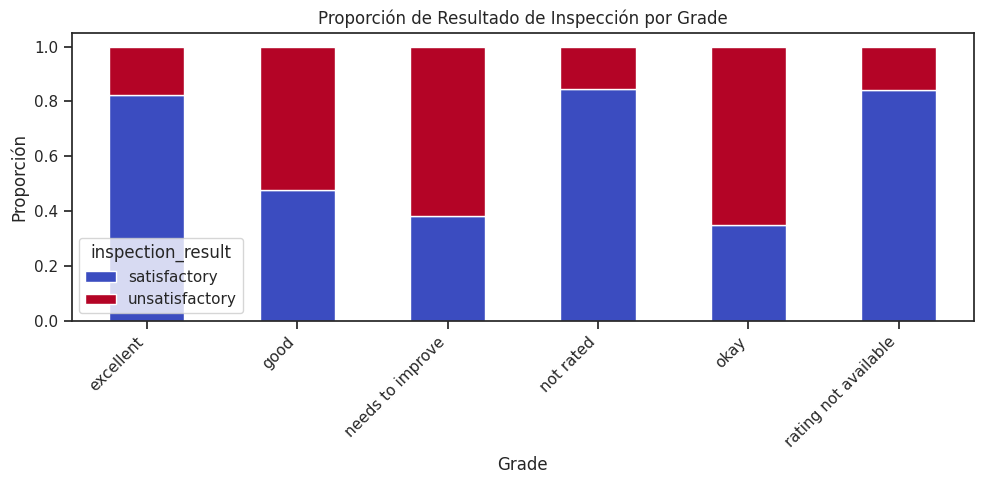



Gráfico de Proporción por Violation_types vs. Resultado de Inspección


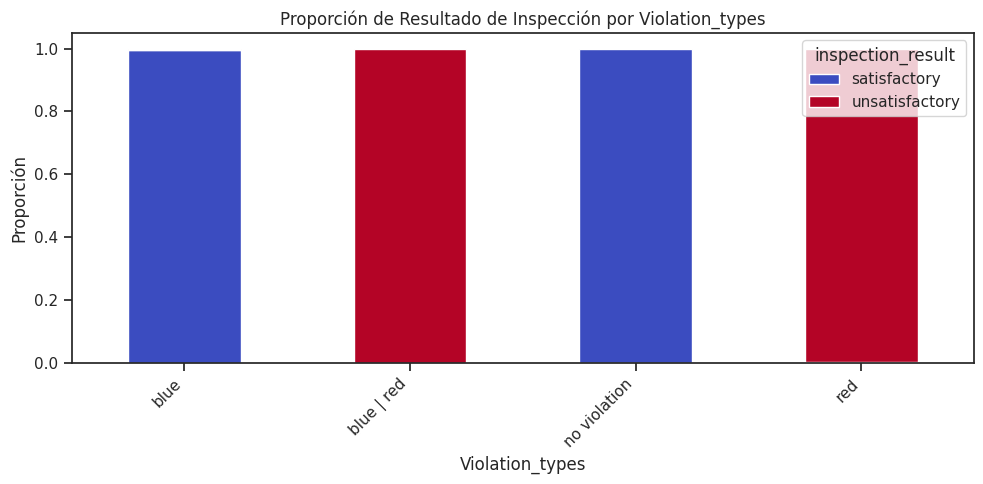



Gráfico de Proporción por Inspection_result vs. Resultado de Inspección


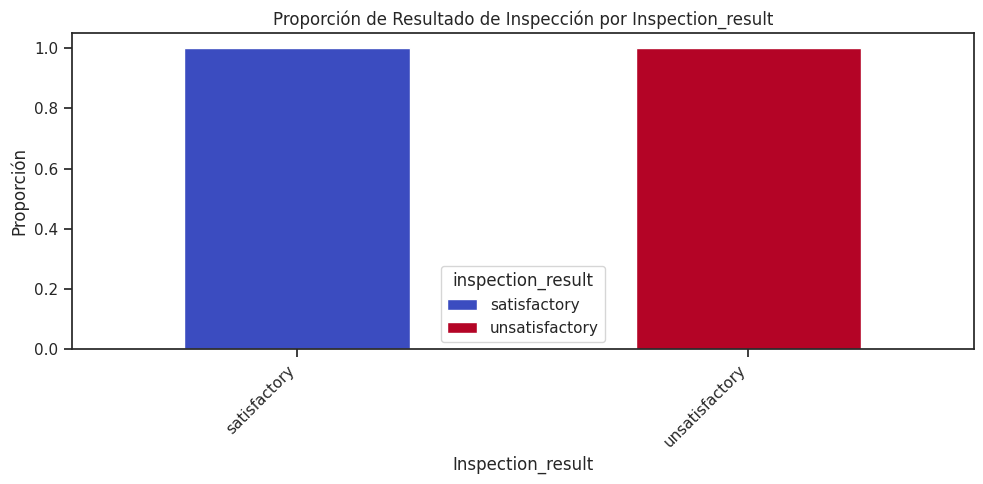

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

for columna in categoricas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:
            # Create figure and axes explicitly
            fig, ax = plt.subplots(figsize=(10, 5))

            tabla.head(10).plot(
                kind="bar",
                stacked=True,
                ax=ax,  # Plot on the created axes
                cmap="coolwarm" # Use a distinct colormap
            )

            ax.set_title(f"Proporción de Resultado de Inspección por {columna.capitalize()}")
            ax.set_xlabel(columna.capitalize())
            ax.set_ylabel("Proporción")
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
            plt.tight_layout() # Adjust layout to prevent overlapping
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para mostrar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

In [ ]:
for columna in categoricas_inspecciones:

    frecuencia = inspections[columna].value_counts()

    raras = (frecuencia < 10).sum()

    print(f"{columna:25} -> {raras} categorías aparecen menos de 10 veces")

classification            -> 1 categorías aparecen menos de 10 veces
city                      -> 24 categorías aparecen menos de 10 veces
zip_code                  -> 29 categorías aparecen menos de 10 veces
inspection_type           -> 0 categorías aparecen menos de 10 veces
inspection_closed_business -> 0 categorías aparecen menos de 10 veces
seating_range             -> 0 categorías aparecen menos de 10 veces
risk_category             -> 0 categorías aparecen menos de 10 veces
grade                     -> 0 categorías aparecen menos de 10 veces
violation_types           -> 0 categorías aparecen menos de 10 veces
inspection_result         -> 0 categorías aparecen menos de 10 veces


Y con las numéricas

Gráfico de Proporción por Inspection_score vs. Resultado de Inspección


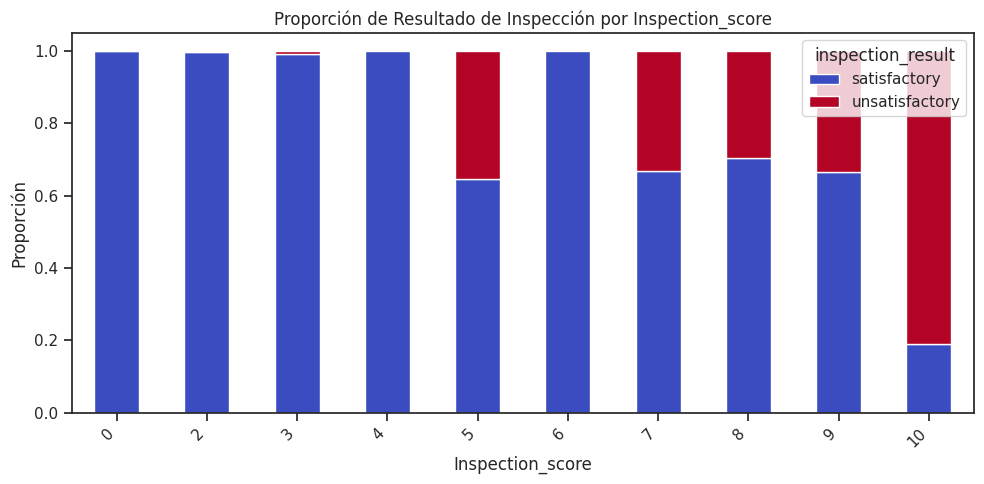



Gráfico de Proporción por Violation_points vs. Resultado de Inspección


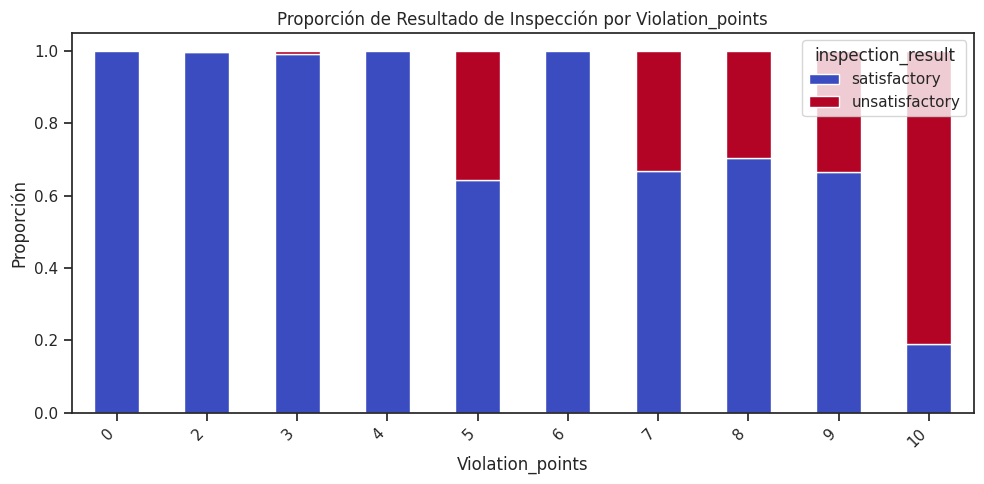



Gráfico de Proporción por Number_violations vs. Resultado de Inspección


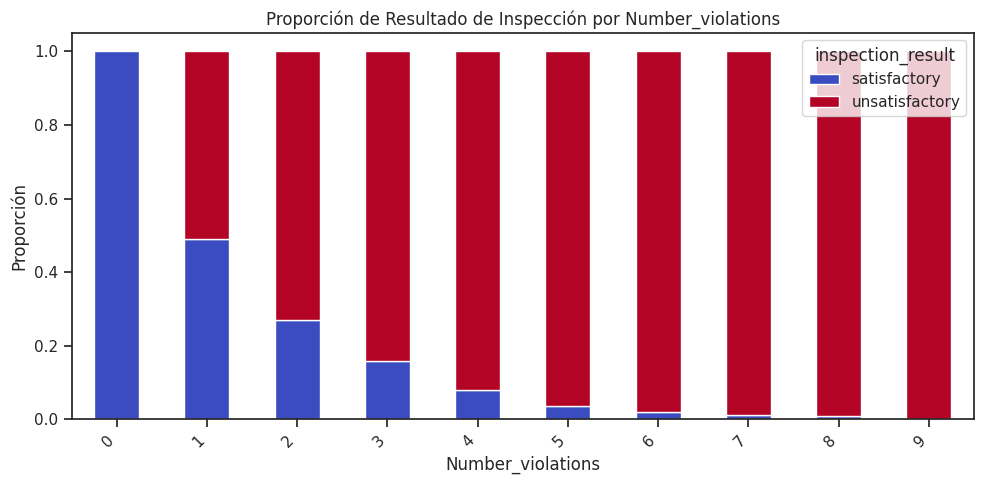

In [ ]:
numericas_inspecciones_para_grafico = [
    'inspection_score',
    'violation_points',
    'number_violations'
]
for columna in numericas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:

            fig, ax = plt.subplots(figsize=(10, 5))

            tabla.head(10).plot(
                kind="bar",
                stacked=True,
                ax=ax,  # Plot on the created axes
                cmap="coolwarm" # Use a distinct colormap
            )

            ax.set_title(f"Proporción de Resultado de Inspección por {columna.capitalize()}")
            ax.set_xlabel(columna.capitalize())
            ax.set_ylabel("Proporción")
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
            plt.tight_layout() # Adjust layout to prevent overlapping
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

Gráfico de Proporción por Inspection_score vs. Resultado de Inspección


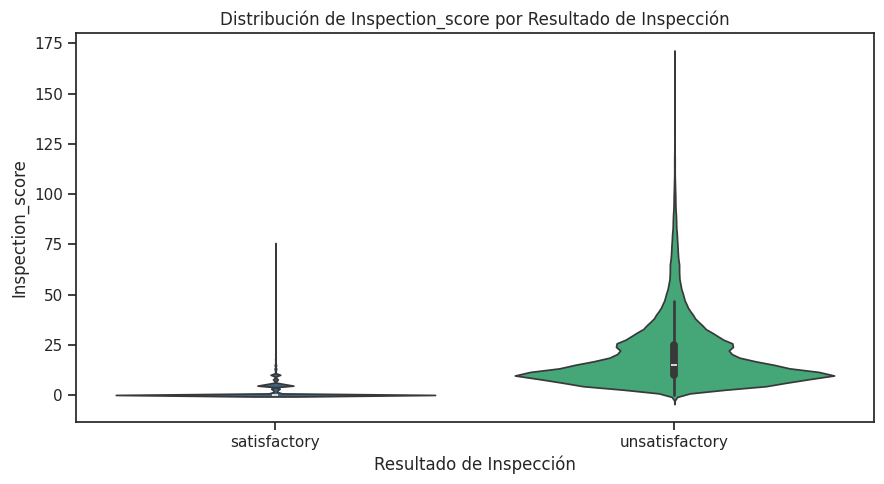



Gráfico de Proporción por Violation_points vs. Resultado de Inspección


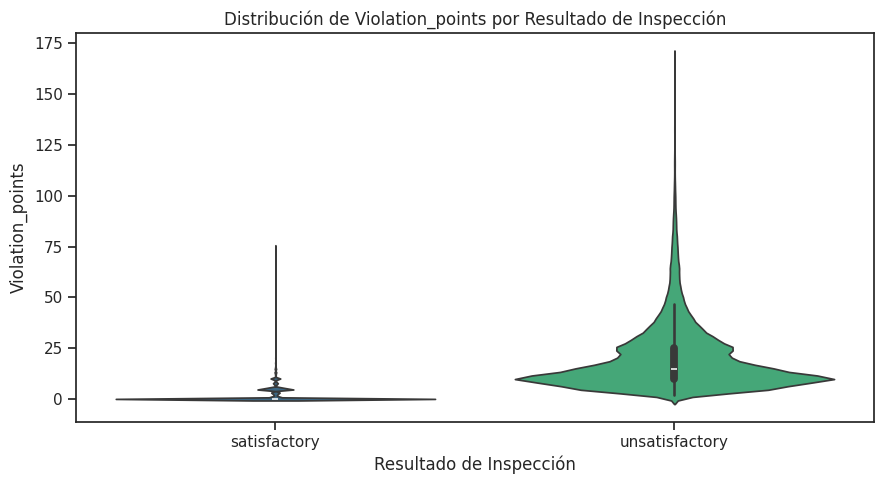



Gráfico de Proporción por Number_violations vs. Resultado de Inspección


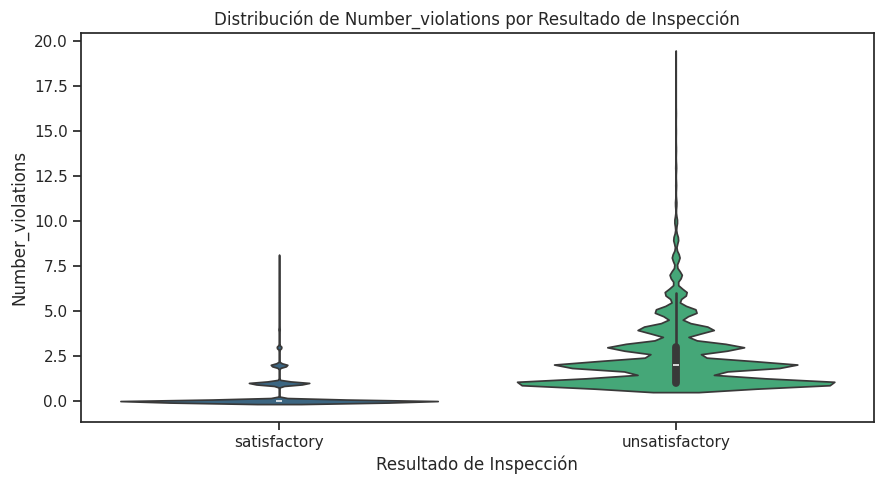

In [ ]:
for columna in numericas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:
            # Create figure and axes explicitly
            fig, ax = plt.subplots(figsize=(9,5)) # Changed plt.figure to plt.subplots

            sns.violinplot(
                data=inspections,
                x="inspection_result",
                y=columna,
                palette="viridis",
                ax=ax # Directed plot to the created axes
            )

            ax.set_title(f"Distribución de {columna.capitalize()} por Resultado de Inspección") # Use ax.set_title
            ax.set_xlabel("Resultado de Inspección")
            ax.set_ylabel(columna.capitalize())
            plt.tight_layout() # Adjust layout
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

REINCIDENCIA

In [ ]:
# para analizar la reincidencia tengo que conocer cuántos establecimientos tienen más de una inspección, cuánto tiempo transcurre entre inspecciones y de ellas cuantas son desfavorables

g = inspections.groupby("business_id", group_keys=False)

inspections["next_inspection_date"] = g["inspection_date"].shift(-1)
inspections["next_inspection_result"] = g["inspection_result"].shift(-1)
inspections["days_to_next_inspection"] = (
    inspections["next_inspection_date"] - inspections["inspection_date"]
).dt.days

inspections["next_violation_set"] = g["violation_set"].shift(-1)

# Handle NaNs before converting to int
inspections["reincidence"] = (
    inspections["next_inspection_result"].eq("unsatisfactory").fillna(False).astype(int)
)

def overlap(row):
    current = row["violation_set"]
    nxt = row["next_violation_set"]
    if not isinstance(current, set) or not current:
        return 0
    if not isinstance(nxt, set) or not nxt:
        return 0
    return int(bool(current.intersection(nxt)))

inspections["specific_recurrence"] = inspections.apply(overlap, axis=1)

model_base = inspections[inspections["next_inspection_date"].notna()].copy()

print("Inspecciones con siguiente inspección:", f"{len(model_base):,}")
print("Reincidencia general:", f"{model_base['reincidence'].mean()*100:.2f}%")
print(
    "Reincidencia específica entre inspecciones con infracción actual:",
    f"{model_base.loc[model_base['number_violations']>0, 'specific_recurrence'].mean()*100:.2f}%"
)


Inspecciones con siguiente inspección: 59,770
Reincidencia general: 0.00%
Reincidencia específica entre inspecciones con infracción actual: 0.00%


In [ ]:
inspections = inspections.sort_values(
    ["business_id", "inspection_date"]
).copy()

g = inspections.groupby("business_id")


# ------------------------------------------------------------
# Número de inspecciones anteriores
# ------------------------------------------------------------

inspections["previous_inspections"] = (
    g.cumcount()
)


# ------------------------------------------------------------
# Número de inspecciones insatisfactorias anteriores
# ------------------------------------------------------------

inspections["previous_unsatisfactory"] = (
    g["inspection_result"]
    .transform(
        lambda x:
        x.eq("unsatisfactory")
        .shift(1)
        .fillna(0)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Tasa histórica de inspecciones insatisfactorias
# ------------------------------------------------------------

inspections["previous_unsatisfactory_rate"] = (
    inspections["previous_unsatisfactory"]
    /
    inspections["previous_inspections"]
    .replace(0, np.nan)
)


# ------------------------------------------------------------
# Infracciones anteriores
# ------------------------------------------------------------

inspections["previous_violations"] = (
    g["number_violations"]
    .transform(
        lambda x:
        x.shift(1)
        .fillna(0)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Puntos de infracción anteriores
# ------------------------------------------------------------

inspections["previous_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1)
        .fillna(0)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Media histórica de puntos
# ------------------------------------------------------------

inspections["previous_avg_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1).expanding().mean()
    )
)


# ------------------------------------------------------------
# Máximo histórico de puntos
# ------------------------------------------------------------

inspections["previous_max_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1).expanding().max()
    )
)


# ------------------------------------------------------------
# Tiempo desde inspección anterior
# ------------------------------------------------------------

inspections["days_since_previous"] = (
    inspections
    .groupby("business_id")["inspection_date"]
    .diff()
    .dt.days
)


# ------------------------------------------------------------
# Resultado anterior
# ------------------------------------------------------------

inspections["previous_result"] = (
    g["inspection_result"]
    .shift(1)
)


# ------------------------------------------------------------
# Puntos de la inspección anterior
# ------------------------------------------------------------

inspections["previous_inspection_points"] = (
    g["violation_points"]
    .shift(1)
)


# ------------------------------------------------------------
# Resultado actual de la inspección
# ------------------------------------------------------------

inspections["current_unsatisfactory"] = (
    inspections["inspection_result"]
    == "unsatisfactory"
).astype(int)

AttributeError: 'DecisionTreeClassifier' object has no attribute 'sort_values'

PREPROCESADO
Cuando ya conozco mis variables, transformo las categóricas con labelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categoricas = inspections.select_dtypes(include=["object", "string"]).columns

for columna in categoricas:

    le = LabelEncoder()

    inspections[columna] = le.fit_transform(
        inspections[columna].astype(str)
    )

    label_encoders[columna] = le

In [ ]:
inspections.isnull().sum()

,0
inspection_serial_num,0
business_id,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
parcel_number,0
inspection_type,0


In [ ]:
next_inspection_result_null=inspections[inspections['next_inspection_result'].isna()]
print(next_inspection_result_null)

       inspection_serial_num  business_id  name inspection_date  \
6              61197                 0     6000    2026-02-23     
13             47137                 1     9723    2025-07-16     
14             43004                 2      103    2025-11-19     
28             61198                 3      110    2025-12-11     
35             34670                 4      109    2025-08-25     
...                      ...          ...   ...             ...   
72063          60972             12293     7281    2026-06-22     
72064          72054             12294     4793    2026-07-08     
72065          72050             12295     5428    2026-07-27     
72066          72051             12296     9607    2026-07-15     
72067          72052             12297     9608    2026-07-07     

       classification  address  city  zip_code  parcel_number  \
6             6         8861     53      58         5849        
13            6         5060     53      58          942        


In [ ]:
# divido el dataset en train y test

inspections["inspection_date"] = pd.to_datetime(
    inspections["inspection_date"],
    errors="coerce"
)

# Ordenar cronológicamente
inspections = inspections.sort_values(
    "inspection_date"
).reset_index(drop=True)

# Punto de corte: 80% train / 20% test
split_idx = int(len(inspections) * 0.80)

# Crear train y test respetando el orden temporal porque nos interesa saber si precide bien el futuro
train = inspections.iloc[:split_idx].copy()
test = inspections.iloc[split_idx:].copy()

# ------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------

print("Tamaño total:", len(inspections))
print("Train:", len(train))
print("Test:", len(test))

print("\nProporciones:")
print(f"Train: {len(train) / len(inspections):.2%}")
print(f"Test:  {len(test) / len(inspections):.2%}")

print("\nPeriodo TRAIN:")
print("Desde:", train["inspection_date"].min())

Tamaño total: 72068
Train: 57654
Test: 14414

Proporciones:
Train: 80.00%
Test:  20.00%

Periodo TRAIN:
Desde: 2021-01-04 00:00:00


In [ ]:
# definimos las variables objetivo

x_train=inspections.drop(columns=['inspection_result'])
y_train=inspections['inspection_result']

x_test=test.drop(columns=['inspection_result'])
y_test=test['inspection_result']

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns



# Crear una copia para evitar modificar el DataFrame X original si se usa en otro lugar en su estado original
X_processed = X.copy()

# Identificar columnas categóricas en X_processed
categorical_cols_in_X = X_processed.select_dtypes(include=['object', 'string']).columns

# Aplicar LabelEncoder a las columnas categóricas identificadas
label_encoders_for_mi = {}
for col in categorical_cols_in_X:
    le = LabelEncoder()
    # Convertir a cadena para manejar posibles tipos mixtos y NaNs, luego rellenar NaNs
    # El método .fillna('__missing__') asigna una categoría numérica a los valores faltantes.
    X_processed[col] = le.fit_transform(X_processed[col].astype(str).fillna('__missing__'))
    label_encoders_for_mi[col] = le

# Ahora todas las columnas en X_processed deberían ser numéricas.
# Aplicar el imputador de mediana.
imputer_mi = SimpleImputer(strategy='median')
X_imputed = imputer_mi.fit_transform(X_processed)

# Convertir el resultado de nuevo a un DataFrame para mantener los nombres de las columnas y el índice
X_imputed = pd.DataFrame(X_imputed, columns=X_processed.columns, index=X.index)

mi = mutual_info_classif(
    X_imputed,
    y,
    random_state=42
)

mi_scores = pd.DataFrame({
    "Variable": X_processed.columns,
    "Mutual Information": mi
})

mi_scores.sort_values(
    by="Mutual Information",
    ascending=False,
    inplace=True
)

display(mi_scores.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_scores.head(20),
    y="Variable",
    x="Mutual Information",
    palette="magma"
)

plt.title("Top variables según Mutual Information")
plt.show()

,Variable,Mutual Information
0,classification,0.158654
4,grade,0.068720
3,seating_range,0.061280
6,inspection_score,0.035593
7,violation_points,0.027190
1,inspection_type,0.017363
5,city,0.010088
2,inspection_closed_business,0.000106


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia de X para no modificar el DataFrame original si se usa en otro lugar
X_encoded = X.copy()

# Identificar columnas categóricas en X_encoded que aún no son numéricas
categorical_cols_for_et = X_encoded.select_dtypes(include=['object', 'string']).columns

# Aplicar LabelEncoder a las columnas categóricas
label_encoders_for_et = {}
for col in categorical_cols_for_et:
    le = LabelEncoder()
    # Convertir a cadena y rellenar NaNs antes de codificar para evitar errores
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str).fillna('__missing__'))
    label_encoders_for_et[col] = le

# El modelo ExtraTreesClassifier no necesita imputación de valores NaN después de Label Encoding si '__missing__' fue manejado como una categoría.
# Sin embargo, si hubiera NaNs numéricos, un SimpleImputer podría ser necesario. Para este caso, asumimos que LabelEncoder con fillna ya los manejó.

modelo = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Entrenar el modelo con el DataFrame codificado
modelo.fit(X_encoded,y)

extra_scores = pd.DataFrame({
    "Variable":X_encoded.columns,
    "Importancia":modelo.feature_importances_
})

extra_scores.sort_values(
    by="Importancia",
    ascending=False,
    inplace=True
)

display(extra_scores.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=extra_scores.head(20),
    y="Variable",
    x="Importancia",
    palette="crest"
)

plt.title("Importancia según Extra Trees")

plt.show()

,Variable,Importancia
0,classification,0.402466
4,grade,0.152285
3,seating_range,0.139710
5,city,0.136264
6,inspection_score,0.114477
7,violation_points,0.043435
1,inspection_type,0.011021
2,inspection_closed_business,0.000341


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Crear una copia de X para no modificar el DataFrame original
X_encoded_rf = X.copy()

# Identificar columnas categóricas en X_encoded_rf
categorical_cols_for_rf = X_encoded_rf.select_dtypes(include=['object', 'string']).columns

# Aplicar LabelEncoder a las columnas categóricas
label_encoders_for_rf = {}
for col in categorical_cols_for_rf:
    le = LabelEncoder()
    # Convertir a cadena y rellenar NaNs antes de codificar para evitar errores
    X_encoded_rf[col] = le.fit_transform(X_encoded_rf[col].astype(str).fillna('__missing__'))
    label_encoders_for_rf[col] = le

rf = RandomForestClassifier(

    n_estimators=500,

    random_state=42,

    n_jobs=-1

)

# Entrenar el modelo con el DataFrame codificado
rf.fit(X_encoded_rf,y)

rf_scores = pd.DataFrame({

    "Variable":X_encoded_rf.columns,

    "Importancia":rf.feature_importances_

})

rf_scores.sort_values(

    by="Importancia",

    ascending=False,

    inplace=True

)
display(rf_scores.head(20))

,Variable,Importancia
0,classification,0.467754
5,city,0.155060
6,inspection_score,0.113625
3,seating_range,0.111668
4,grade,0.098510
7,violation_points,0.041605
1,inspection_type,0.011462
2,inspection_closed_business,0.000314


In [ ]:
comparacion = pd.DataFrame({

    "Mutual Information":mi_scores.set_index("Variable")["Mutual Information"],

    "Extra Trees":extra_scores.set_index("Variable")["Importancia"],
    "Random Forest":rf_scores.set_index("Variable")["Importancia"],


})


comparacion.head(20)


,Mutual Information,Extra Trees,Random Forest
Variable,,,
city,0.010088,0.136264,0.155060
classification,0.158654,0.402466,0.467754
grade,0.068720,0.152285,0.098510
inspection_closed_business,0.000106,0.000341,0.000314
inspection_score,0.035593,0.114477,0.113625
inspection_type,0.017363,0.011021,0.011462
seating_range,0.061280,0.139710,0.111668
violation_points,0.027190,0.043435,0.041605


In [ ]:
# y creo un ranking para no confiar en un único método

ranking = pd.DataFrame({

    "MI":mi_scores.set_index("Variable")["Mutual Information"],

    "RF":rf_scores.set_index("Variable")["Importancia"],

    "ExtraTrees":extra_scores.set_index("Variable")["Importancia"],

})

ranking = ranking.rank(

    ascending=False

)

ranking["Ranking Medio"] = ranking.mean(axis=1)

ranking.sort_values(

    "Ranking Medio",

    inplace=True

)

display(ranking.head(20))

,MI,RF,ExtraTrees,Ranking Medio
Variable,,,,
classification,1.0,1.0,1.0,1.000000
grade,2.0,5.0,2.0,3.000000
seating_range,3.0,4.0,3.0,3.333333
inspection_score,4.0,3.0,5.0,4.000000
city,7.0,2.0,4.0,4.333333
violation_points,5.0,6.0,6.0,5.666667
inspection_type,6.0,7.0,7.0,6.666667
inspection_closed_business,8.0,8.0,8.0,8.000000


In [ ]:
# reviso los nulos antes de entrenar

print("Nulos en entrenamiento:", train.isnull().sum().sum())
print("Nulos en validación:", test.isnull().sum().sum())

Nulos en entrenamiento: 9628
Nulos en validación: 39564


In [ ]:
train.isnull().sum()

,0
inspection_serial_num,0
business_id,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
parcel_number,0
inspection_type,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

# creo el modelo con un parámetro ni demasiado alto ni demasiado bajo
inspections = DecisionTreeClassifier(
    random_state=42
)

inicio = time.time()
inspections.fit(X_train, y_train)
fin = time.time()

print(f"Tiempo de entrenamiento: {fin-inicio:.3f} segundos")

y_pred_dt = inspections.predict(X_test)

# y reviso las predicciones para después ver las métricas del modelo
comparacion = pd.DataFrame({
    "Valor real": y_train,
    "Predicción": y_pred_dt
})

display(comparacion.head(15))

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print(f"Precision: {precision_dt:.4f}")

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print(f"Recall: {recall_dt:.4f}")

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print(f"F1-score: {f1_dt:.4f}")

# Y dibujo un rsumen
metricas_dt = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Valor": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ]
})

display(metricas_dt)

# y que saque el informe
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)


ValueError: could not convert string to float: 'general food services'

In [ ]:
# ahora analizamos la ubicación y su efecto sobre la reincidencia
def historical_group_rate(df, group_col):
    tmp = df[["inspection_date", group_col, "inspection_result"]].copy()
    tmp["_unsat"] = tmp["inspection_result"].eq("unsatisfactory").astype(int)
    tmp = tmp.sort_values("inspection_date")

    # Número de casos y unsatisfactory anteriores al momento actual.
    prev_n = tmp.groupby(group_col).cumcount()
    prev_unsat = (
        tmp.groupby(group_col)["_unsat"]
           .transform(lambda s: s.shift(1).fillna(0).cumsum())
    )

    rate = prev_unsat / prev_n.replace(0, np.nan)
    return rate.reindex(df.index).fillna(0) # Impute NaN with 0 for initial entries

# Para evitar problemas de índice tras transformaciones, calculamos sobre
# un dataframe ordenado y asignamos por índice.
inspections = inspections.sort_values(
    ["inspection_date", "inspection_serial_num"]
).copy()

for col, out_col in [
    ("city", "city_previous_unsat_rate"),
    ("zip_code", "zip_previous_unsat_rate"),
    ("parcel_number", "parcel_previous_unsat_rate"),
]:
    inspections[out_col] = historical_group_rate(inspections, col)

# Tamaño histórico de actividad en la zona
for col, out_col in [
    ("city", "city_previous_inspections"),
    ("zip_code", "zip_previous_inspections"),
    ("parcel_number", "parcel_previous_inspections"),
]:
    tmp = inspections[["inspection_date", col]].sort_values("inspection_date")
    prev_n = tmp.groupby(col).cumcount()
    inspections[out_col] = prev_n.reindex(inspections.index).fillna(0) # Impute NaN with 0 (should already be 0, but good practice)

# Volvemos al orden por establecimiento.
inspections = inspections.sort_values(
    ["business_id", "inspection_date", "inspection_serial_num"]
).reset_index(drop=True)

print("Variables históricas geográficas creadas.")

AttributeError: 'DecisionTreeClassifier' object has no attribute 'sort_values'

In [ ]:
# ahora trabajamos el modelo A, que es la información que conocemos antes de realizar la siguiente inspección


model_data = inspections[
    inspections["next_inspection_date"].notna()
    & (inspections["previous_inspections"] >= 1)
].copy()

categorical_pre = [
    "classification",
    "city",
    "inspection_type",
    "seating_range",
    "risk_category",
    "previous_result",
]

numeric_pre = [
    "zip_code",
    "previous_inspections",
    "previous_unsatisfactory",
    "previous_unsatisfactory_rate",
    "days_since_previous",
    "previous_inspection_points",
    "previous_inspection_score",
    "previous_number_violations",
    "unsat_last_3",
    "unsat_last_5",
    "violations_last_3",
    "violations_last_5",
    "points_last_3",
    "points_last_5",
    "score_mean_last_3",
    "score_mean_last_5",
    "previous_avg_violation_points",
    "previous_max_violation_points",
    "points_trend_last_5",
    "previous_unique_violations",
    "city_previous_unsat_rate",
    "zip_previous_unsat_rate",
    "parcel_previous_unsat_rate",
    "city_previous_inspections",
    "zip_previous_inspections",
    "parcel_previous_inspections",
]

# Filter features_pre to only include columns that exist in model_data
features_pre = [
    col for col in (categorical_pre + numeric_pre) if col in model_data.columns
]

X = model_data[features_pre].copy()
y = model_data["reincidence"].astype(int)

# División temporal: 80% inicial para entrenamiento, 20% final para test.
cutoff = model_data["inspection_date"].quantile(0.80)

train = model_data[model_data["inspection_date"] <= cutoff].copy()
test = model_data[model_data["inspection_date"] > cutoff].copy()

X_train, y_train = train[features_pre], train["reincidence"]
X_test, y_test = test[features_pre], test["reincidence"]

print("TRAIN:", len(train), "|", train["inspection_date"].min().date(), "→", train["inspection_date"].max().date())
print("TEST :", len(test), "|", test["inspection_date"].min().date(), "→", test["inspection_date"].max().date())
print("Tasa train:", round(y_train.mean()*100, 2), "%")
print("Tasa test :", round(y_test.mean()*100, 2), "%")

TRAIN: 38703 | 2021-01-28 → 2025-04-16
TEST : 9670 | 2025-04-17 → 2026-08-26
Tasa train: 32.18 %
Tasa test : 23.6 %


In [ ]:
# limpieza de datos
! pip install autoviz
from autoviz import data_cleaning_suggestions
data_cleaning_suggestions(dataset_limpio_final)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.4.1
    Uninstalling xgboost-3.4.1:
      Successfully uninstalled xgboost-3.4.1
Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
    Removing ['parcel_number'] column(s) due to mixed data type detected...
name of type=string is not classified
classification of type=string

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
name,string,0.000000,9,,,No issue
inspection_date,datetime64[ns],0.000000,1,,,Possible date-time colum: transform before modeling step.
classification,string,0.000000,0,,,No issue
address,string,0.000000,8,,,No issue
city,string,0.000000,0,,,No issue
zip_code,object,0.000000,0,,,Possible high cardinality column with 112 unique values: Use hash encoding or text embedding to reduce dimension.
inspection_type,string,0.000000,0,,,No issue
inspection_score,int64,0.000000,0,0.000000,167.000000,Column has 6278 outliers greater than upper bound (57.50) or lower than lower bound(-34.50). Cap them or remove them.
inspection_result,string,0.000000,0,,,No issue
inspection_closed_business,string,0.000000,0,,,No issue


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
name,string[python],0.0,9,,,No issue
inspection_date,datetime64[ns],0.0,1,,,Possible date-time colum: transform before modeling step.
classification,string[python],0.0,0,,,No issue
address,string[python],0.0,8,,,No issue
city,string[python],0.0,0,,,No issue
zip_code,object,0.0,0,,,Possible high cardinality column with 112 unique values: Use hash encoding or text embedding to reduce dimension.
inspection_type,string[python],0.0,0,,,No issue
inspection_score,int64,0.0,0,0.0,167.0,Column has 6278 outliers greater than upper bound (57.50) or lower than lower bound(-34.50). Cap them or remove them.
inspection_result,string[python],0.0,0,,,No issue
inspection_closed_business,string[python],0.0,0,,,No issue


MATRIZ DE CONFUSIÓN

In [ ]:
def saca_metricas (y_true, y_pred):

  print ('Matriz de confusion')
  print (confusion_matrix(y_true, y_pred))
  print ('Metricas')
  print (classification_report(y_true, y_pred))
  print ('Accuracy: ', accuracy_score(y_true, y_pred))



ACTAS CON MÁS DE UNA INFRACCIÓN DOCUMENTADA
Dado que consta que existen varias filas para la misma inspección, se debe trabajar a nivel inspection_serial_num, con el fin de poder valorar realmente la reincidencia.

In [ ]:
# Contabilización de actas con más de una infracción documentada

valores_repetidos = dataset_limpio_final['inspection_serial_num'].value_counts()

cantidad_valores_repetidos = (valores_repetidos > 1).sum()

print(f'Cantidad de inspection_serial_num distintos que están repetidos: {cantidad_valores_repetidos}')

Cantidad de inspection_serial_num distintos que están repetidos: 16431


In [ ]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def unique_join(s):
    vals = (
        s.dropna().astype(str).str.strip()
        .replace({"": np.nan})
        .dropna().unique()
    )
    return " | ".join(sorted(vals))

inspections = (
    dataset_limpio_final.sort_values(["business_id", "inspection_date", "inspection_serial_num"])
       .groupby("inspection_serial_num", as_index=False)
       .agg(
           business_id=("business_id", first_non_null),
           name=("name", first_non_null),
           inspection_date=("inspection_date", "first"),
           classification=("classification", first_non_null),
           address=("address", first_non_null),
           city=("city", first_non_null),
           zip_code=("zip_code", first_non_null),
           parcel_number=("parcel_number", first_non_null),
           inspection_type=("inspection_type", first_non_null),
           inspection_closed_business=("inspection_closed_business", first_non_null),
           seating_range=("seating_range", first_non_null),
           risk_category=("risk_category", first_non_null),
           inspection_score=("inspection_score", "first"),
           grade=("grade", first_non_null),
           violation_points=("violation_points", "sum"),
           number_violations=("has_violation_row", "sum"),
           violation_descriptions=("violation_description", unique_join),
           violation_types=("violation_type", unique_join),

           inspection_result=("inspection_result", "first"),
       )
)

# The merge with inspection_flags is no longer needed here as inspection_result# is already aggregated directly from dataset_limpio_final

# y normalizo las infracciones también a ese nivel
inspections["violation_set"] = (
    inspections["violation_descriptions"]
    .fillna("")
    .apply(lambda x: {v.strip() for v in x.split(" | ") if v.strip()})
)

inspections = inspections.sort_values(
    ["business_id", "inspection_date", "inspection_serial_num"]
).reset_index(drop=True)

print("Inspecciones:", f"{len(inspections):,}")
print("Establecimientos:", f"{inspections['business_id'].nunique():,}")
print("\nResultado:")
print(inspections["inspection_result"].value_counts())

Inspecciones: 72,068
Establecimientos: 12,298

Resultado:
inspection_result_clean
satisfactory      48202
unsatisfactory    21480
complete           2386
Name: count, dtype: Int64


In [ ]:
inspections.isnull().sum()

,0
inspection_serial_num,0
business_id,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
parcel_number,0
inspection_type,0


ANÁLISIS DE LA PROBLEMÁTICA: INSPECCIONES INSATISFACTORIAS Y REINCIDENCIA

In [ ]:
# Total de inspecciones insatisfactorias en porcentaje
total_unsatisfactory = (
    inspections["inspection_result"]
    .str.lower()
    .str.strip()
    .eq("unsatisfactory")
    .sum()
)

total_inspecciones = len(inspections)

porcentaje = (total_unsatisfactory / total_inspecciones) * 100

inspecciones_sin_descripcion = dataset_limpio_final[dataset_limpio_final["violation_description"].isnull()]
print("Total de inspecciones unsatisfactory:", total_unsatisfactory)
print("Total de inspecciones:", total_inspecciones)
print("Porcentaje de inspecciones unsatisfactory:", round(porcentaje, 2), "%")


Total de inspecciones unsatisfactory: 21480
Total de inspecciones: 72068
Porcentaje de inspecciones unsatisfactory: 29.81 %


ahora intentamos reducir la cardinalidad

In [ ]:
import pandas as pd


categoricas_inspecciones = [
    'classification',
    'city',
    'zip_code',
    'inspection_type',
    'inspection_closed_business',
    'seating_range',
    'risk_category',
    'grade',
    'violation_types',
    'inspection_result'
]

for columna in categoricas_inspecciones:
    print("="*60)
    print(columna.capitalize())
    print("="*60)


    if columna in inspections.columns:
        display(inspections[columna].value_counts().head(10))
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")

    print("\n")

Classification


,count
classification,
general food services,52918
school lunch program,4469
grocery store,4387
meat/fish market,2975
mobile food unit,2747
nonprofit institution,1561
bakery,1254
catering operation,1202
limited food service,434




City


,count
city,
seattle,32903
bellevue,4489
kent,3703
federal way,3656
renton,3419
redmond,2894
kirkland,2855
auburn,2541
tukwila,1879




Zip_code


...

,count
grade,
excellent,37123
good,17934
not rated,10687
okay,5663
needs to improve,393
rating not available,268




Violation_types


,count
violation_types,
no violation,39809
red,11046
blue,10731
blue | red,10482




Inspection_result_clean


,count
inspection_result_clean,
satisfactory,48202
unsatisfactory,21480
complete,2386


Gráfico para: Classification


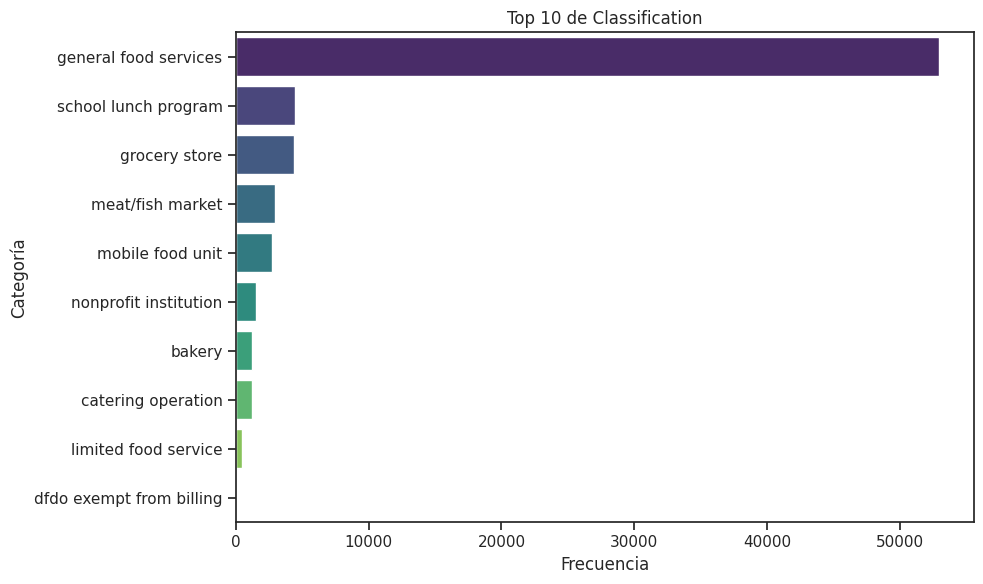



Gráfico para: City


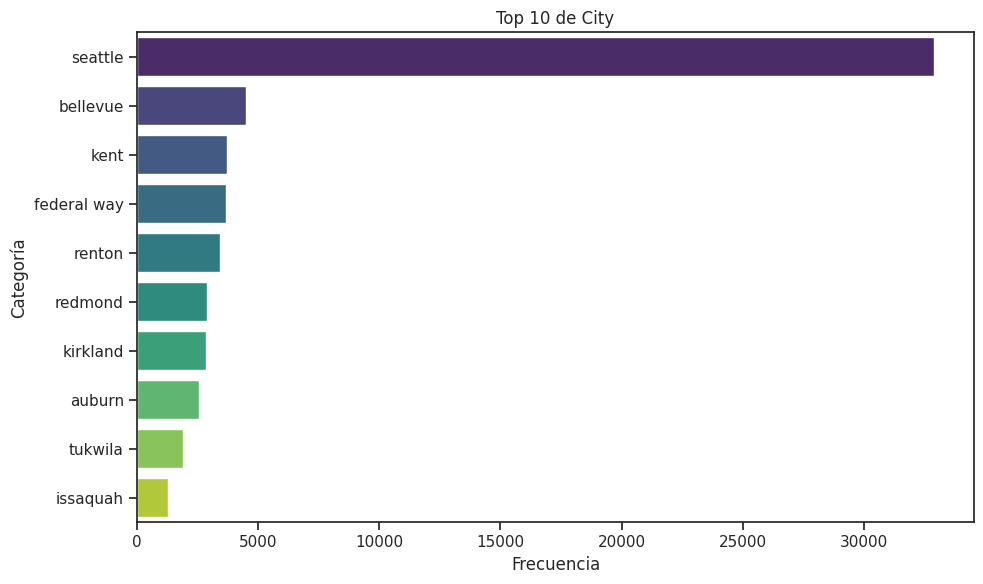



Gráfico para: Zip_code


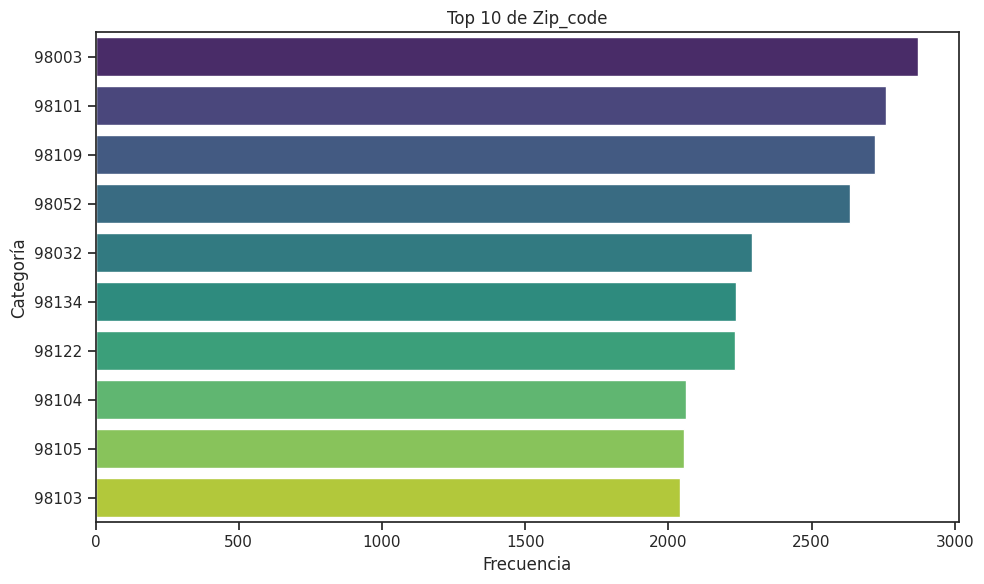



Gráfico para: Inspection_type


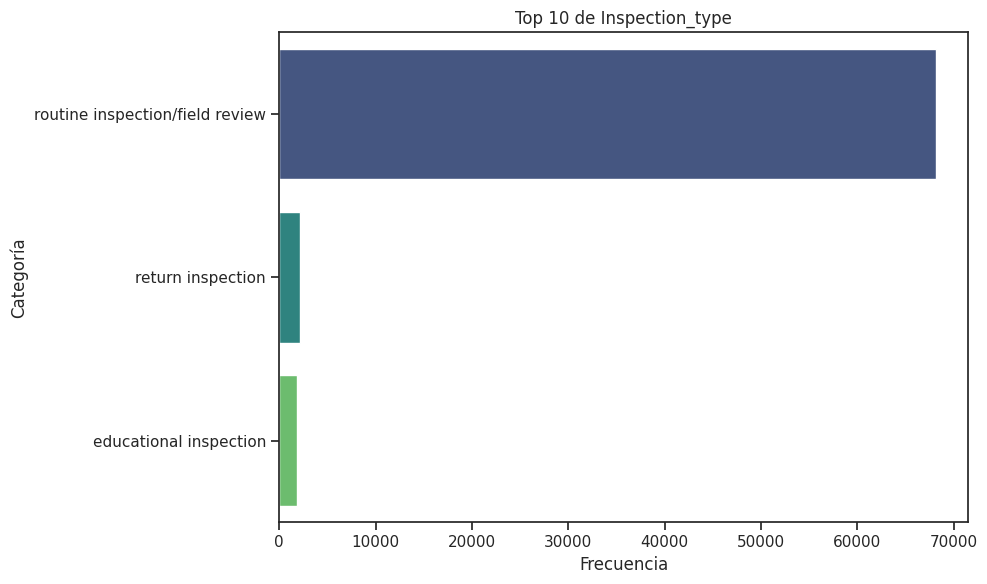



Gráfico para: Inspection_closed_business


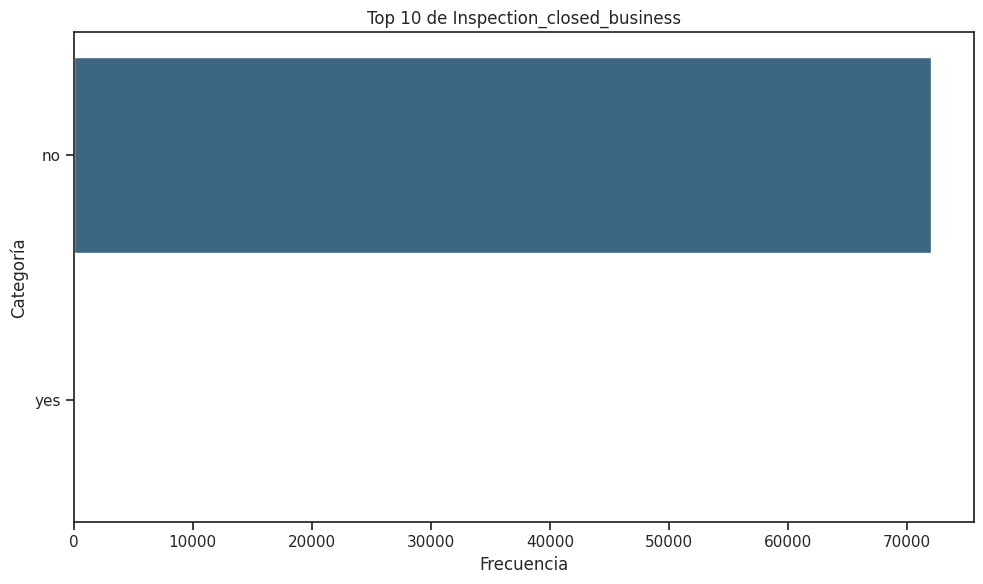



Gráfico para: Seating_range


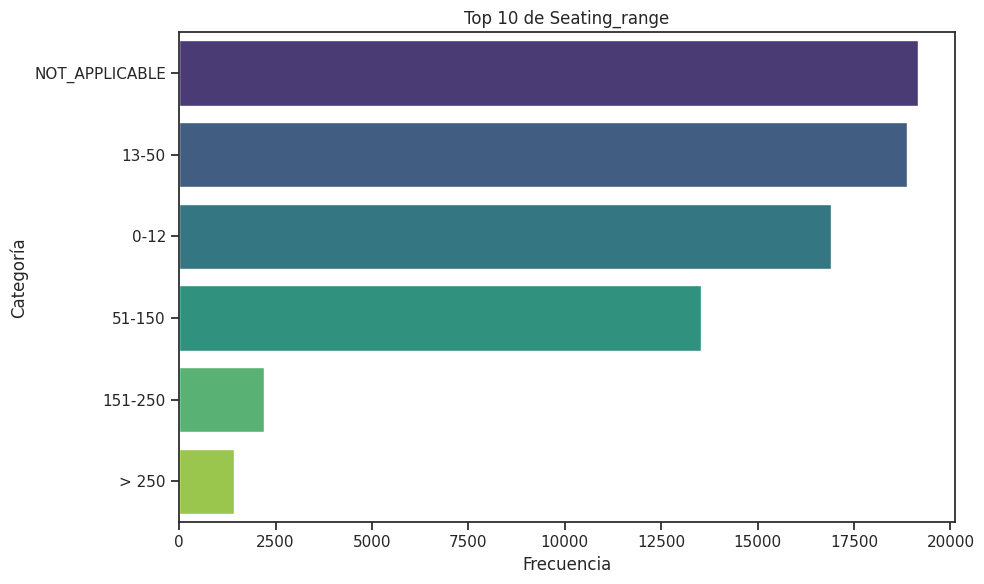



Gráfico para: Risk_category


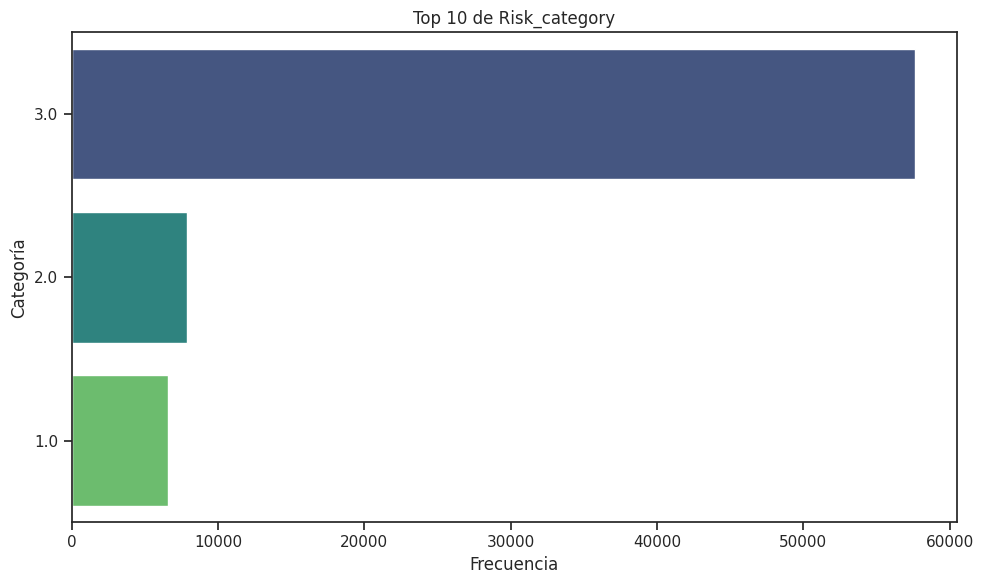



Gráfico para: Grade


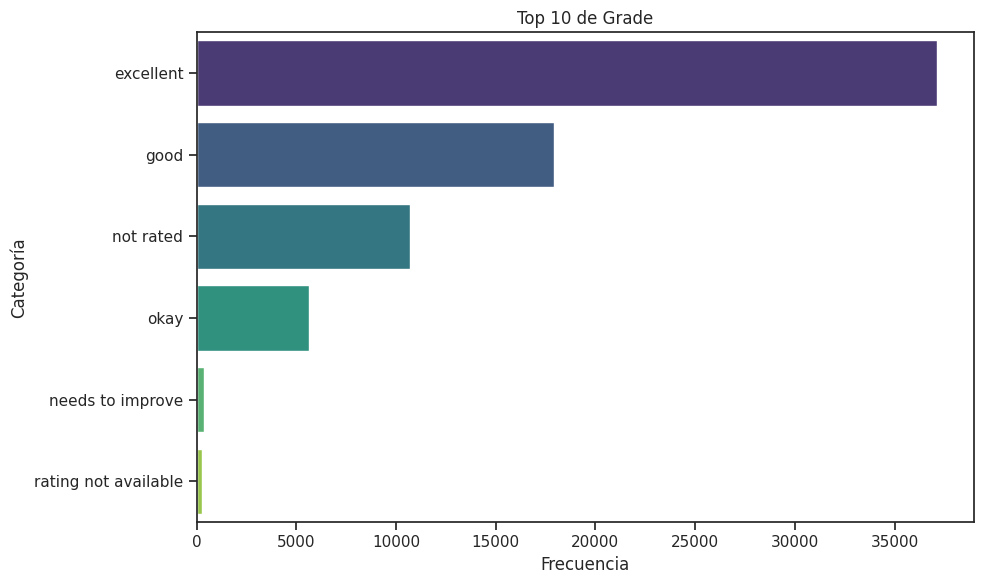



Gráfico para: Violation_types


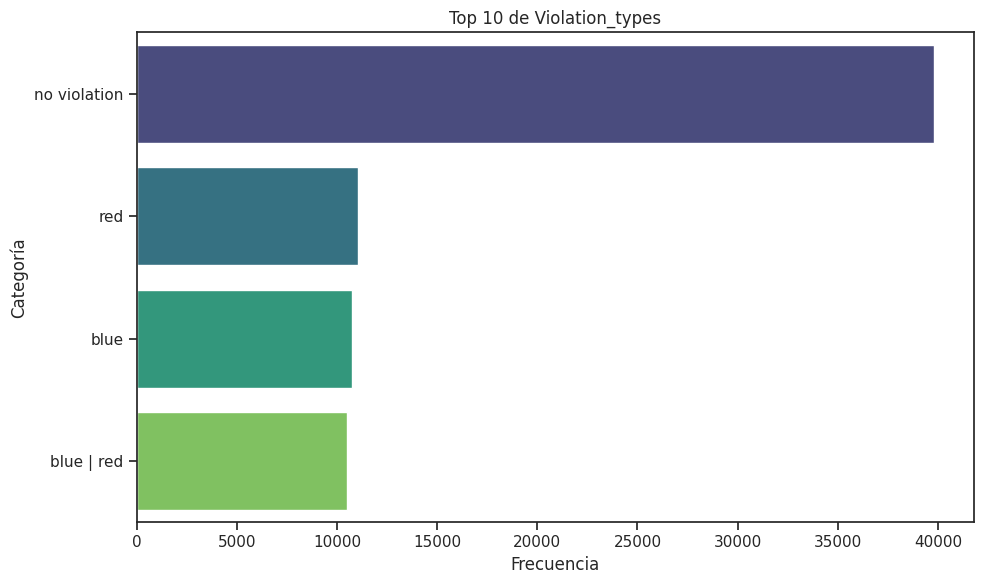



Gráfico para: Inspection_result_clean


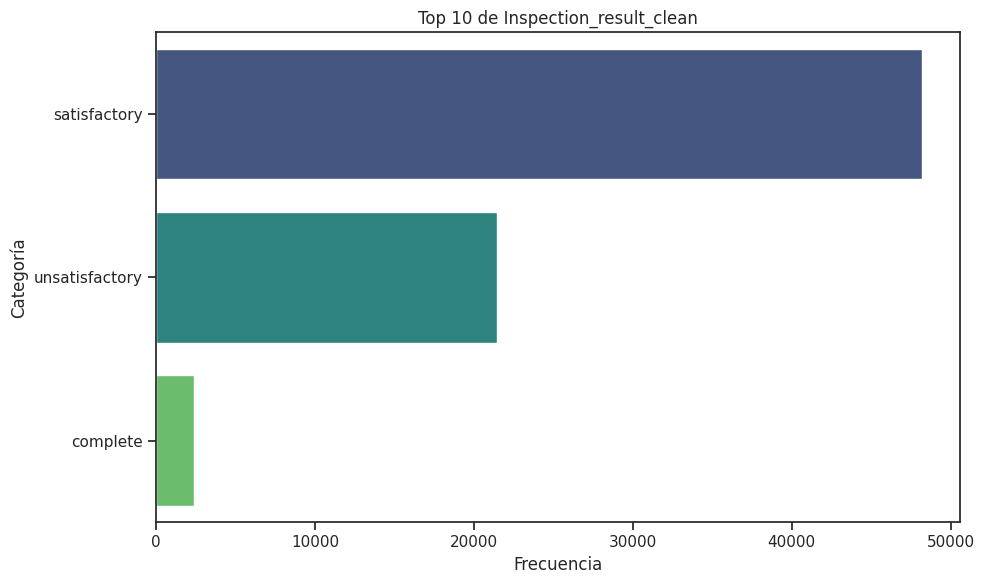

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

categoricas_inspecciones_para_grafico = [
    'classification',
    'city',
    'zip_code',
    'inspection_type',
    'inspection_closed_business',
    'seating_range',
    'risk_category',
    'grade',
    'violation_types',
    'inspection_result'
]

for columna in categoricas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico para: {columna.capitalize()}")
    print("="*60)

    if columna in inspections.columns:
        fig, ax = plt.subplots(figsize=(10, 6))

        top_values = inspections[columna].value_counts().head(10)

        if not top_values.empty:
            sns.barplot(
                x=top_values.values,
                y=top_values.index,
                palette="viridis",
                ax=ax
            )
            ax.set_title(f"Top 10 de {columna.capitalize()}")
            ax.set_xlabel("Frecuencia")
            ax.set_ylabel("Categoría")
            plt.tight_layout()
            display(fig)
            plt.close(fig)
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")

    print("\n")

Y anora se analiza la relación entre las variables categóricas y el resultado de la inspección

Gráfico de Proporción por Classification vs. Resultado de Inspección


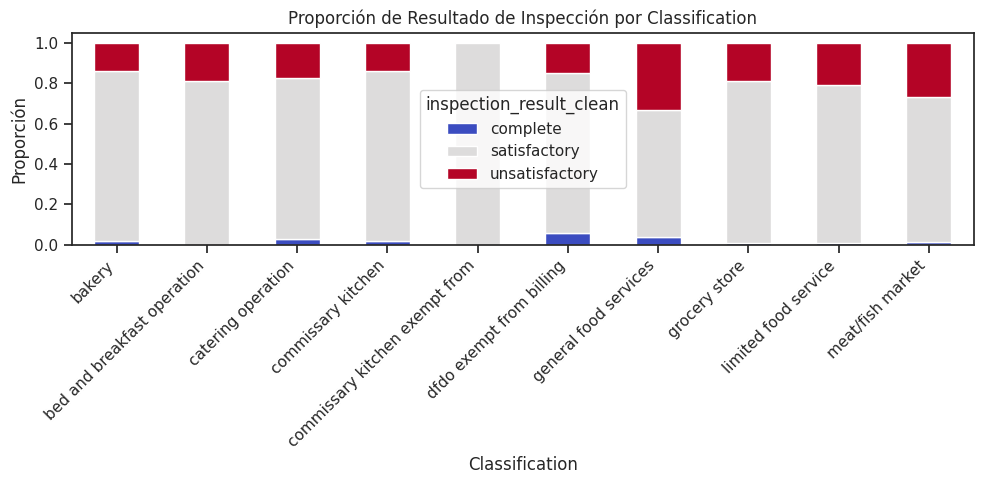



Gráfico de Proporción por City vs. Resultado de Inspección


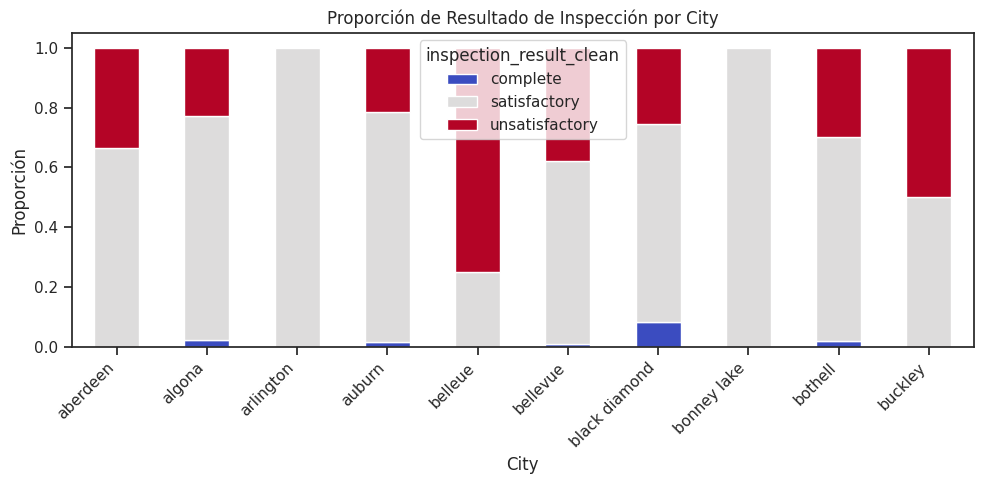



Gráfico de Proporción por Zip_code vs. Resultado de Inspección


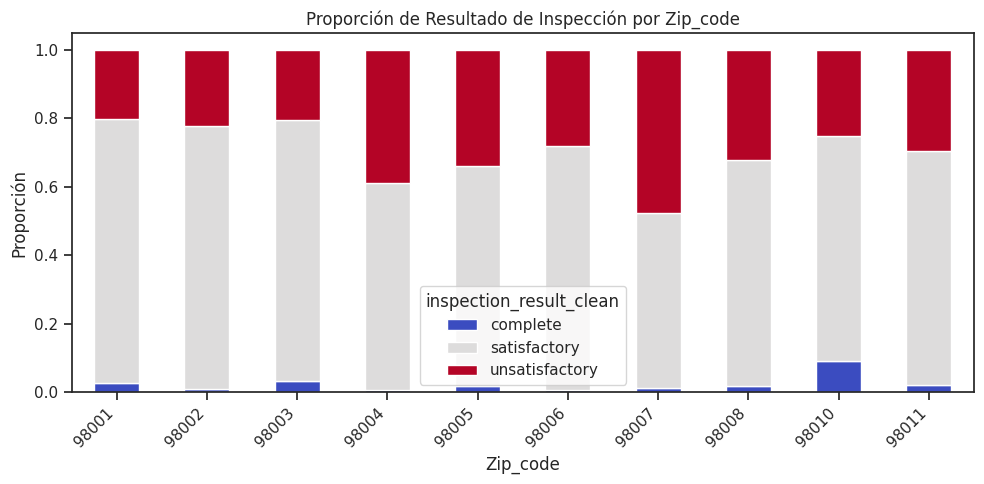



Gráfico de Proporción por Inspection_type vs. Resultado de Inspección


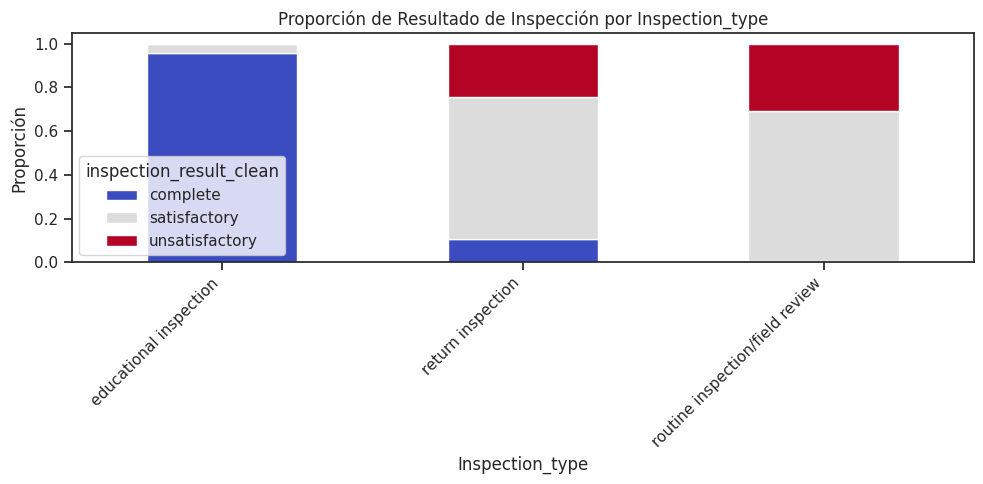



Gráfico de Proporción por Inspection_closed_business vs. Resultado de Inspección


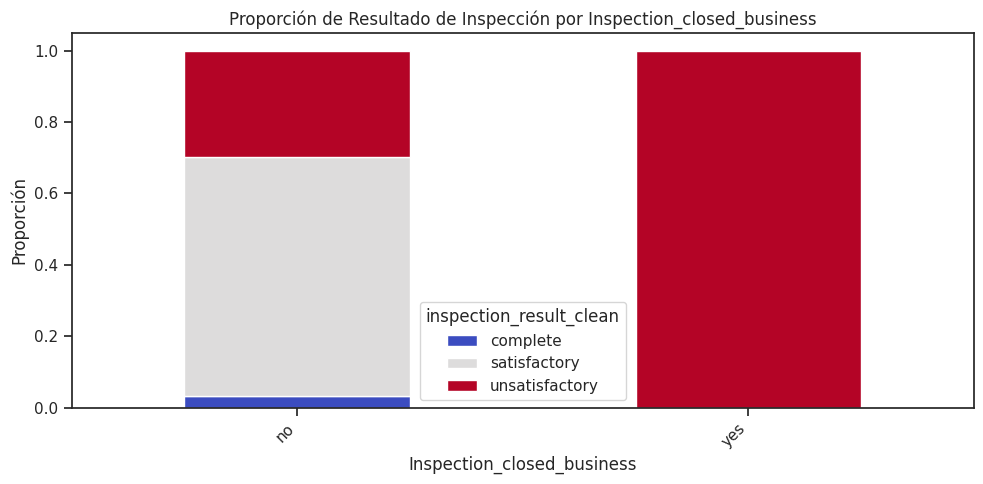



Gráfico de Proporción por Seating_range vs. Resultado de Inspección


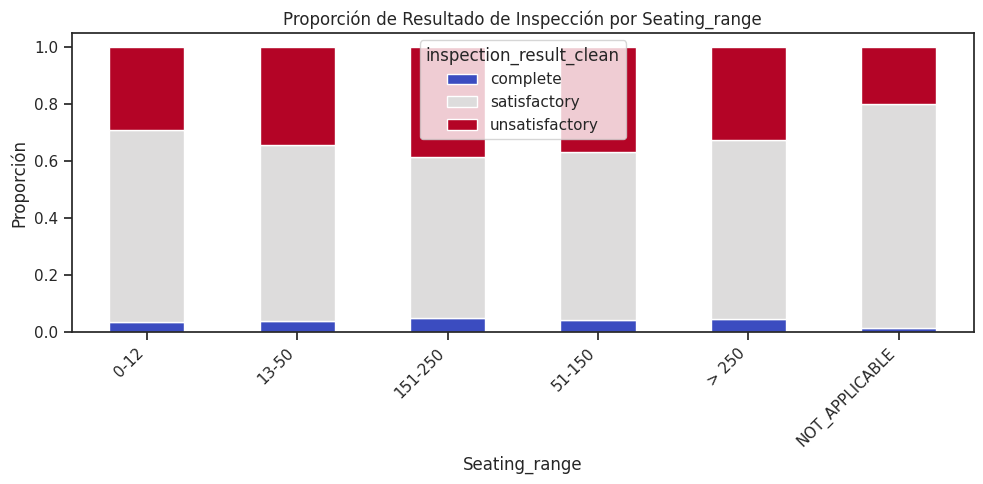



Gráfico de Proporción por Risk_category vs. Resultado de Inspección


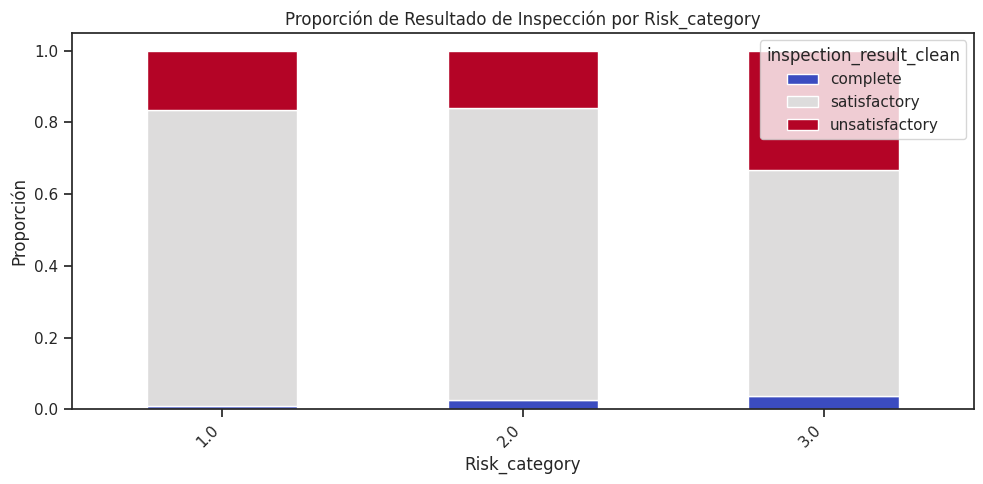



Gráfico de Proporción por Grade vs. Resultado de Inspección


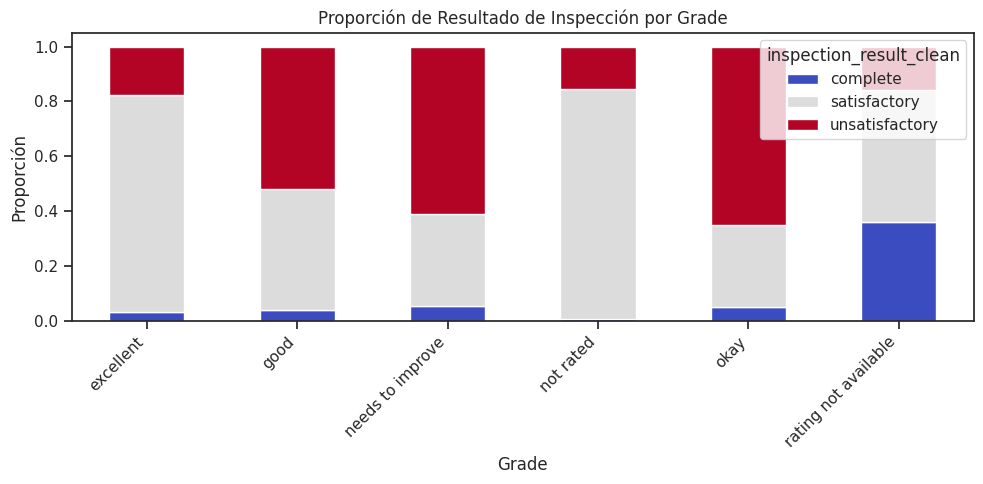



Gráfico de Proporción por Violation_types vs. Resultado de Inspección


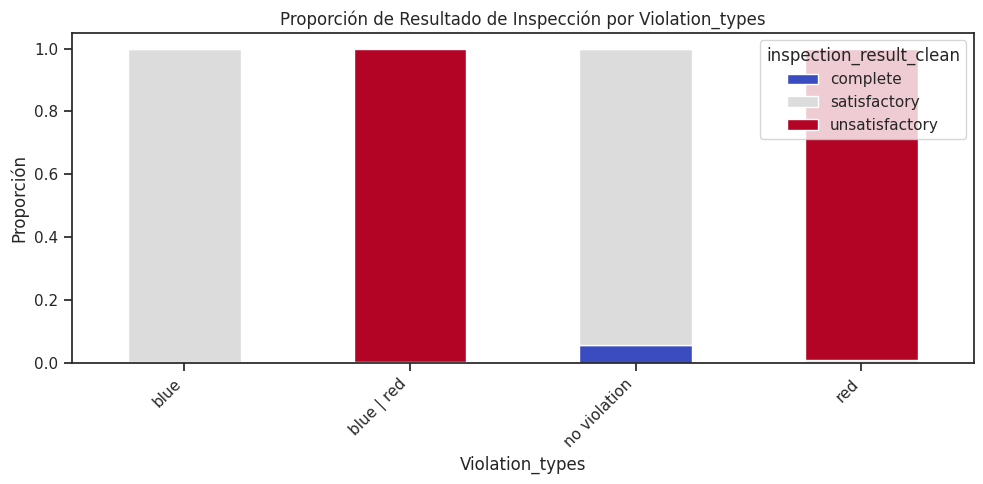



Gráfico de Proporción por Inspection_result_clean vs. Resultado de Inspección


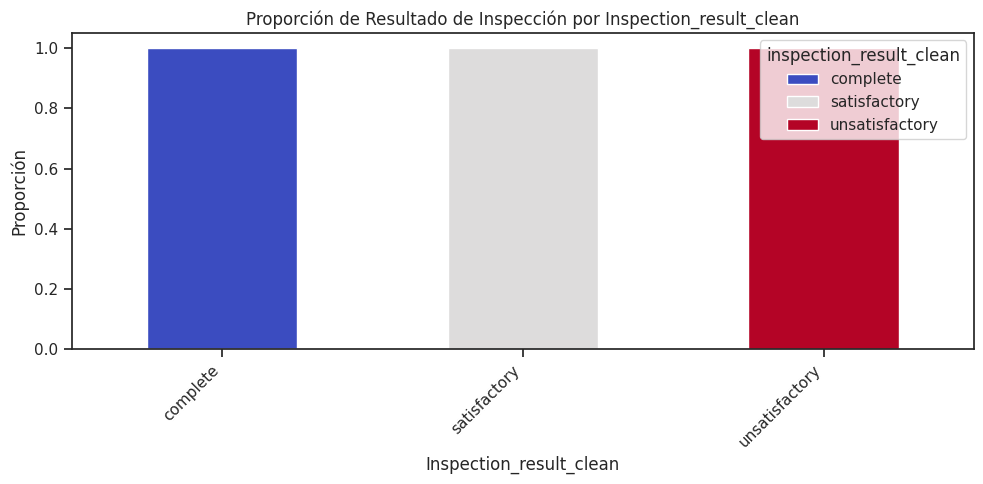

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

for columna in categoricas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:
            # Create figure and axes explicitly
            fig, ax = plt.subplots(figsize=(10, 5))

            tabla.head(10).plot(
                kind="bar",
                stacked=True,
                ax=ax,  # Plot on the created axes
                cmap="coolwarm" # Use a distinct colormap
            )

            ax.set_title(f"Proporción de Resultado de Inspección por {columna.capitalize()}")
            ax.set_xlabel(columna.capitalize())
            ax.set_ylabel("Proporción")
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
            plt.tight_layout() # Adjust layout to prevent overlapping
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para mostrar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

Y ahora repetimos el tratamiento con las numéricas

Gráfico de Proporción por Inspection_score vs. Resultado de Inspección


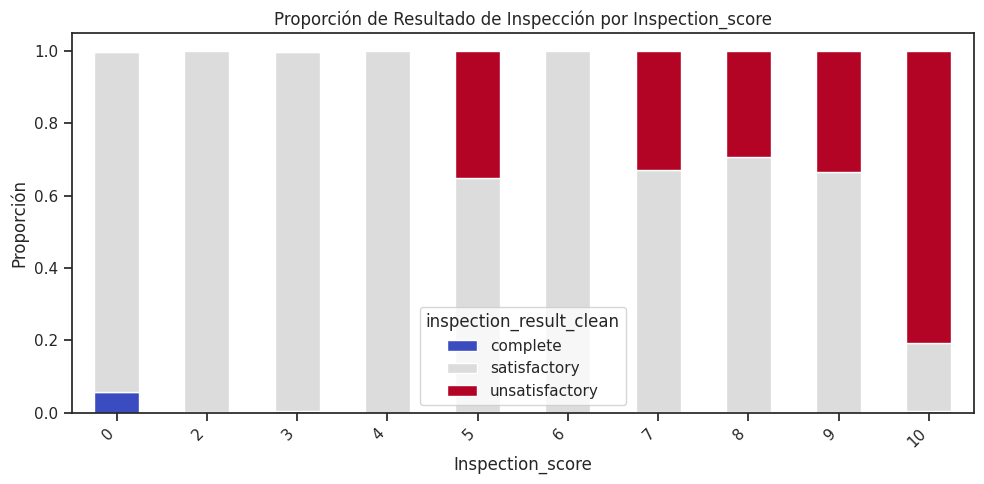



Gráfico de Proporción por Violation_points vs. Resultado de Inspección


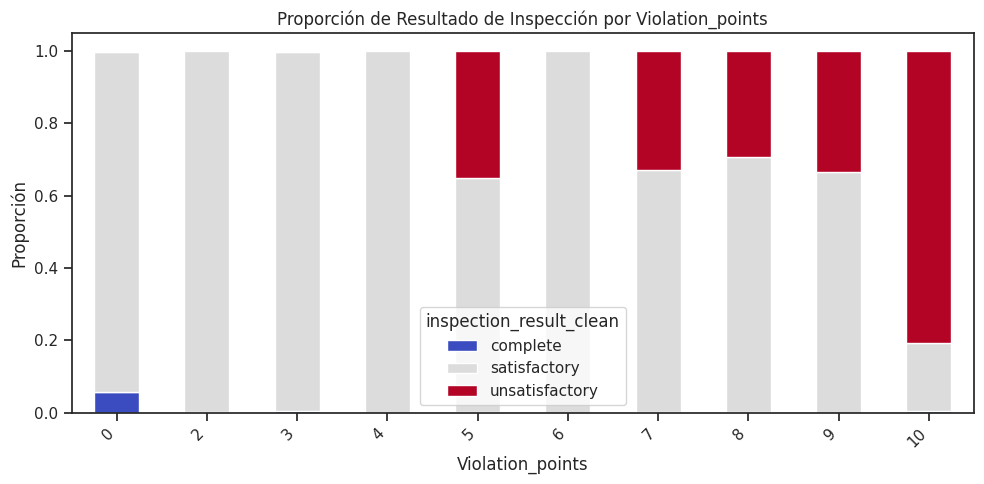



Gráfico de Proporción por Number_violations vs. Resultado de Inspección


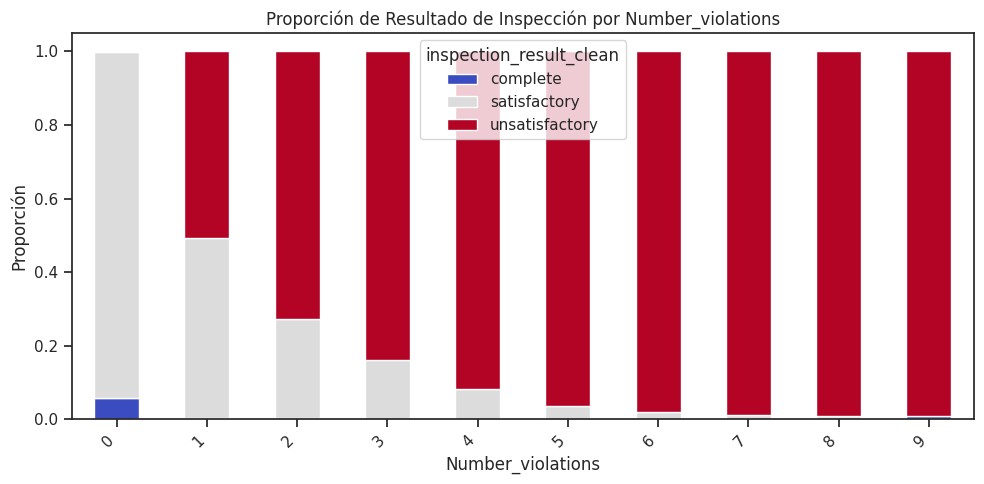

In [ ]:
numericas_inspecciones_para_grafico = [
    'inspection_score',
    'violation_points',
    'number_violations'
]
for columna in numericas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:

            fig, ax = plt.subplots(figsize=(10, 5))

            tabla.head(10).plot(
                kind="bar",
                stacked=True,
                ax=ax,  # Plot on the created axes
                cmap="coolwarm" # Use a distinct colormap
            )

            ax.set_title(f"Proporción de Resultado de Inspección por {columna.capitalize()}")
            ax.set_xlabel(columna.capitalize())
            ax.set_ylabel("Proporción")
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
            plt.tight_layout() # Adjust layout to prevent overlapping
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

Gráfico de Proporción por Inspection_score vs. Resultado de Inspección


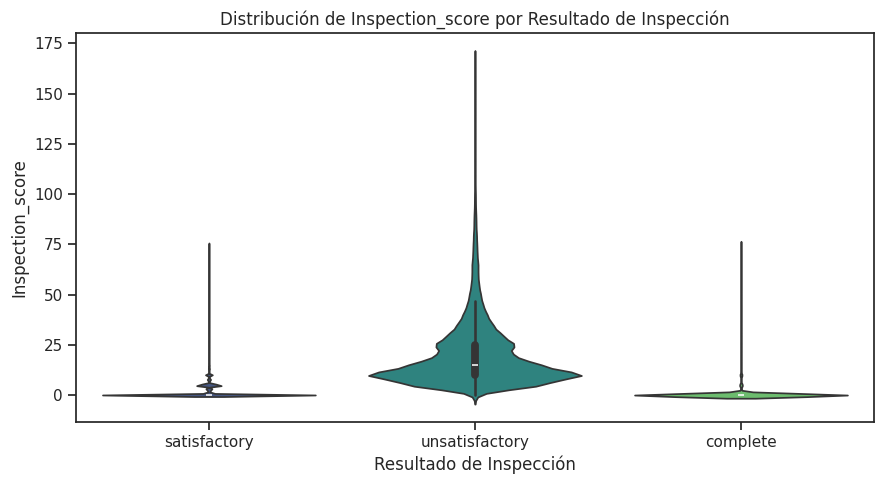



Gráfico de Proporción por Violation_points vs. Resultado de Inspección


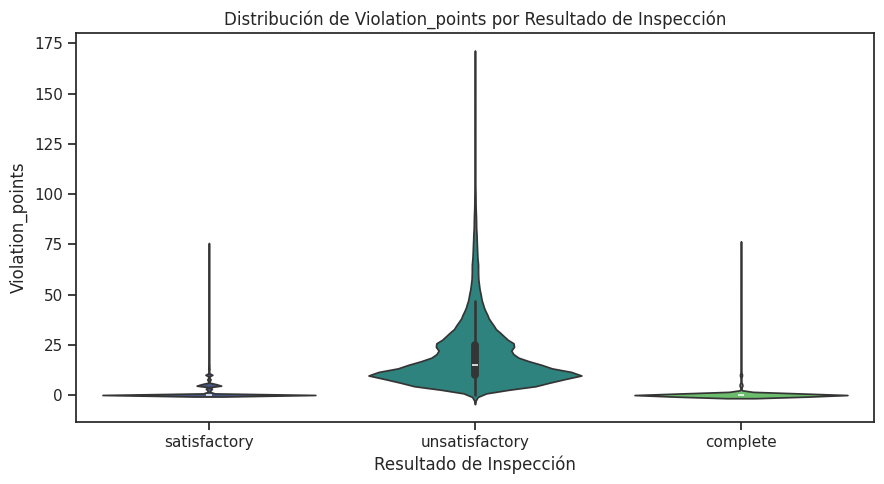



Gráfico de Proporción por Number_violations vs. Resultado de Inspección


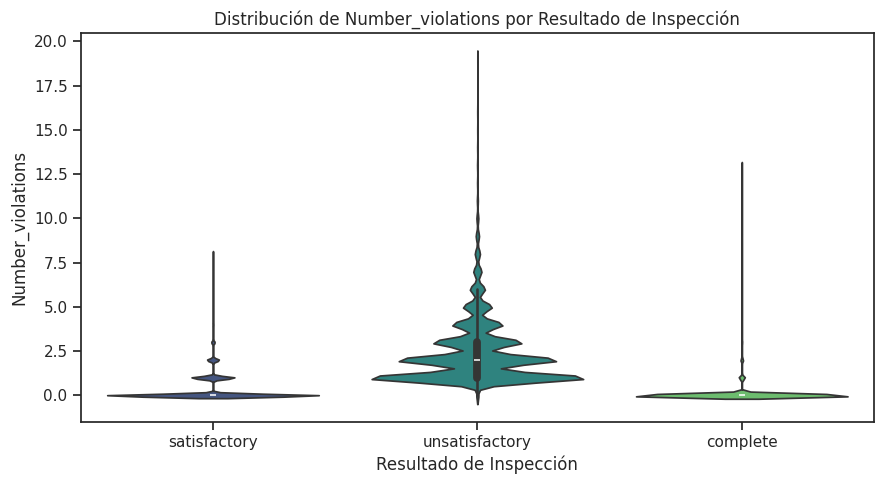

In [ ]:
for columna in numericas_inspecciones_para_grafico:
    print("="*60)
    print(f"Gráfico de Proporción por {columna.capitalize()} vs. Resultado de Inspección")
    print("="*60)

    if columna in inspections.columns:
        tabla = pd.crosstab(
            inspections[columna],
            inspections["inspection_result"],
            normalize="index"
        )

        if not tabla.empty:
            # Create figure and axes explicitly
            fig, ax = plt.subplots(figsize=(9,5)) # Changed plt.figure to plt.subplots

            sns.violinplot(
                data=inspections,
                x="inspection_result",
                y=columna,
                palette="viridis",
                ax=ax # Directed plot to the created axes
            )

            ax.set_title(f"Distribución de {columna.capitalize()} por Resultado de Inspección") # Use ax.set_title
            ax.set_xlabel("Resultado de Inspección")
            ax.set_ylabel(columna.capitalize())
            plt.tight_layout() # Adjust layout
            display(fig) # Explicitly display the figure
            plt.close(fig) # Close the figure to free up memory
        else:
            print(f"No hay datos para graficar en la columna '{columna}'.")
    else:
        print(f"Advertencia: La columna '{columna}' no se encontró en el DataFrame 'inspections'.")
    print("\n")

In [ ]:
for columna in categoricas_inspecciones:

    frecuencia = inspections[columna].value_counts()

    raras = (frecuencia < 10).sum()

    print(f"{columna:25} -> {raras} categorías aparecen menos de 10 veces")

classification            -> 1 categorías aparecen menos de 10 veces
city                      -> 24 categorías aparecen menos de 10 veces
zip_code                  -> 29 categorías aparecen menos de 10 veces
inspection_type           -> 0 categorías aparecen menos de 10 veces
inspection_closed_business -> 0 categorías aparecen menos de 10 veces
seating_range             -> 0 categorías aparecen menos de 10 veces
risk_category             -> 0 categorías aparecen menos de 10 veces
grade                     -> 0 categorías aparecen menos de 10 veces
violation_types           -> 0 categorías aparecen menos de 10 veces
inspection_result_clean   -> 0 categorías aparecen menos de 10 veces


REINCIDENCIA

In [ ]:
# para analizar la reincidencia tengo que conocer cuántos establecimientos tienen más de una inspección, cuánto tiempo transcurre entre inspecciones y de ellas cuantas son desfavorables

g = inspections.groupby("business_id", group_keys=False)

inspections["next_inspection_date"] = g["inspection_date"].shift(-1)
inspections["next_inspection_result"] = g["inspection_result"].shift(-1)
inspections["days_to_next_inspection"] = (
    inspections["next_inspection_date"] - inspections["inspection_date"]
).dt.days

inspections["next_violation_set"] = g["violation_set"].shift(-1)

# Handle NaNs before converting to int
inspections["reincidence"] = (
    inspections["next_inspection_result"].eq("unsatisfactory").fillna(False).astype(int)
)

def overlap(row):
    current = row["violation_set"]
    nxt = row["next_violation_set"]
    if not isinstance(current, set) or not current:
        return 0
    if not isinstance(nxt, set) or not nxt:
        return 0
    return int(bool(current.intersection(nxt)))

inspections["specific_recurrence"] = inspections.apply(overlap, axis=1)

model_base = inspections[inspections["next_inspection_date"].notna()].copy()

print("Inspecciones con siguiente inspección:", f"{len(model_base):,}")
print("Reincidencia general:", f"{model_base['reincidence'].mean()*100:.2f}%")
print(
    "Reincidencia específica entre inspecciones con infracción actual:",
    f"{model_base.loc[model_base['number_violations']>0, 'specific_recurrence'].mean()*100:.2f}%"
)


Inspecciones con siguiente inspección: 59,770
Reincidencia general: 30.76%
Reincidencia específica entre inspecciones con infracción actual: 27.79%


PREPROCESADO
Cuando ya he establecido estas nuevas variables, transformos las categóricas con labelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categoricas = inspections.select_dtypes(include=["object", "string"]).columns

for columna in categoricas:

    le = LabelEncoder()

    inspections[columna] = le.fit_transform(
        inspections[columna].astype(str)
    )

    label_encoders[columna] = le

In [ ]:
inspections.isnull().sum()

,0
inspection_serial_num,0
business_id,0
name,0
inspection_date,0
classification,0
address,0
city,0
zip_code,0
parcel_number,0
inspection_type,0


In [ ]:
# divido el dataset en train y test

inspections["inspection_date"] = pd.to_datetime(
    inspections["inspection_date"],
    errors="coerce"
)

# Ordenar cronológicamente
inspections = inspections.sort_values(
    "inspection_date"
).reset_index(drop=True)

# Punto de corte: 80% train / 20% test
split_idx = int(len(inspections) * 0.80)

# Crear train y test respetando el orden temporal porque nos interesa saber si precide bien el futuro
train = inspections.iloc[:split_idx].copy()
test = inspections.iloc[split_idx:].copy()

# ------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------

print("Tamaño total:", len(inspections))
print("Train:", len(train))
print("Test:", len(test))

print("\nProporciones:")
print(f"Train: {len(train) / len(inspections):.2%}")
print(f"Test:  {len(test) / len(inspections):.2%}")

print("\nPeriodo TRAIN:")
print("Desde:", train["inspection_date"].min())
print("Hasta:", train["inspection_date"].max())

print("\nPeriodo TEST:")
print("Desde:", test["inspection_date"].min())
print("Hasta:", test["inspection_date"].max())

Tamaño total: 72068
Train: 57654
Test: 14414

Proporciones:
Train: 80.00%
Test:  20.00%

Periodo TRAIN:
Desde: 2021-01-04 00:00:00
Hasta: 2025-10-09 00:00:00

Periodo TEST:
Desde: 2025-10-09 00:00:00
Hasta: 2026-08-27 00:00:00


In [ ]:
# definimos las variables objetivo

x=inspections.drop(columns=['inspection_result'])
y=inspections['inspection_result']

x_test=test.drop(columns=['inspection_result'])
y_test=test['inspection_result']

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia para evitar modificar el DataFrame x original si se usa en otro lugar en su estado original
X_processed = x.copy()

# Convertir columnas de fecha a timestamp numérico para que SimpleImputer pueda manejarlas
# y mutual_info_classif pueda usarlas como características numéricas.
for col in ['inspection_date', 'next_inspection_date']:
    if col in X_processed.columns:
        # Convertir a Unix timestamp (número de segundos desde el Epoch)
        # Rellenar NaNs con un valor numérico (e.g., 0 o mediana de la columna después de la conversión)
        # Aquí, simplemente reemplazamos pd.NaT con np.nan para que SimpleImputer pueda manejarlo.
        X_processed[col] = pd.to_numeric(X_processed[col].astype(int) / 10**9, errors='coerce')

# Identificar columnas categóricas en X_processed
categorical_cols_in_X = X_processed.select_dtypes(include=['object', 'string']).columns

# Aplicar LabelEncoder a las columnas categóricas identificadas
label_encoders_for_mi = {}
for col in categorical_cols_in_X:
    le = LabelEncoder()
    # Convertir a cadena para manejar posibles tipos mixtos y NaNs, luego rellenar NaNs
    # El método .fillna('__missing__') asigna una categoría numérica a los valores faltantes.
    X_processed[col] = le.fit_transform(X_processed[col].astype(str).fillna('__missing__'))
    label_encoders_for_mi[col] = le

# Ahora todas las columnas en X_processed deberían ser numéricas (incluyendo los timestamps y las categóricas codificadas).
# Aplicar el imputador de mediana.
imputer_mi = SimpleImputer(strategy='median')
X_imputed = imputer_mi.fit_transform(X_processed)

# Convertir el resultado de nuevo a un DataFrame para mantener los nombres de las columnas y el índice
X_imputed = pd.DataFrame(X_imputed, columns=X_processed.columns, index=x.index)

mi = mutual_info_classif(
    X_imputed,
    y,
    random_state=42
)

mi_scores = pd.DataFrame({
    "Variable": X_processed.columns,
    "Mutual Information": mi
})

mi_scores.sort_values(
    by="Mutual Information",
    ascending=False,
    inplace=True
)

display(mi_scores.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_scores.head(20),
    y="Variable",
    x="Mutual Information",
    palette="magma"
)

plt.title("Top variables según Mutual Information")
plt.show()

,Variable,Mutual Information
17,violation_descriptions,0.604490
18,violation_types,0.604005
19,violation_set,0.588701
15,violation_points,0.436903
13,inspection_score,0.435377
16,number_violations,0.353605
1,business_id,0.127554
5,address,0.118486
2,name,0.118187
9,inspection_type,0.106110


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer

# Redefinir X y y para el modelo de reincidencia, asegurando la consistencia de las muestras
# Estas variables ya están definidas en la celda hRi7EXPFSp4d (o sus duplicados)
X_reincidence =x.copy()
y_reincidence = y.astype(int)

# Asegurarse de que no haya pd.NA en X_reincidence antes del procesamiento
for col in X_reincidence.columns:
    if pd.api.types.is_extension_array_dtype(X_reincidence[col].dtype):
        X_reincidence[col] = X_reincidence[col].astype(object)
    # Reemplazar pd.NA con np.nan para que los imputadores de sklearn puedan manejarlos
    X_reincidence[col] = X_reincidence[col].replace({pd.NA: np.nan})

# Definiciones de características (asumiendo que vienen de una celda anterior como hRi7EXPFSp4d)
# o se definen aquí para robustez si el cuaderno no se ejecuta secuencialmente.
# Si 'categorical_pre' no está definida, se asume un listado vacío o se recupera de alguna forma.
# Para este contexto, las definimos explícitamente y las filtramos.

# Definiciones robustas de las listas de características si no están en el scope
if 'categorical_pre' not in locals():
    categorical_pre = [
        "classification", "city", "inspection_type", "seating_range",
        "risk_category", "previous_result"
    ]
if 'numeric_pre' not in locals():
    numeric_pre = [
        "zip_code", "previous_inspections", "previous_unsatisfactory",
        "previous_unsatisfactory_rate", "days_since_previous",
        "previous_inspection_points", "previous_inspection_score",
        "previous_number_violations", "unsat_last_3", "unsat_last_5",
        "violations_last_3", "violations_last_5", "points_last_3",
        "points_last_5", "score_mean_last_3", "score_mean_last_5",
        "previous_avg_violation_points", "previous_max_violation_points",
        "points_trend_last_5", "previous_unique_violations",
        "city_previous_unsat_rate", "zip_previous_unsat_rate",
        "parcel_previous_unsat_rate", "city_previous_inspections",
        "zip_previous_inspections", "parcel_previous_inspections",
    ]

# Filtrar las listas de características para incluir solo las columnas que existen en X_reincidence
actual_categorical_pre = [col for col in categorical_pre if col in X_reincidence.columns]
actual_numeric_pre = [col for col in numeric_pre if col in X_reincidence.columns]

# Definir preprocesadores para manejar NaNs y codificar variables
categorical_transformer_et = Pipeline(
    steps=[
        (
            "convert_to_object",
            FunctionTransformer(
                lambda X: X.astype(object),  # Convertir a object para evitar problemas con pd.NA
                validate=False
            )
        ),
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_transformer_et = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor_et = ColumnTransformer(
    transformers=[
        (
            "cat",
            categorical_transformer_et,
            actual_categorical_pre # Usar la lista de columnas categóricas filtrada
        ),
        (
            "num",
            numeric_transformer_et,
            actual_numeric_pre # Usar la lista de columnas numéricas filtrada
        )
    ]
)

# Aplicar el preprocesamiento a X_reincidence
X_processed_for_et = preprocessor_et.fit_transform(X_reincidence)

# Para 'get_feature_names_out', se necesita la lista de características que realmente se usaron.
# Reconstruimos 'features_pre' con las listas filtradas.
features_pre_for_get_names = actual_categorical_pre + actual_numeric_pre

modelo = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Entrenar el modelo con el DataFrame preprocesado y la variable objetivo alineada
modelo.fit(X_processed_for_et, y_reincidence)

# Obtener los nombres de las características post-preprocesamiento para la visualización
# Esto es importante si se usó OneHotEncoder
feature_names = preprocessor_et.get_feature_names_out(input_features=features_pre_for_get_names)

extra_scores = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": modelo.feature_importances_
})

extra_scores.sort_values(
    by="Importancia",
    ascending=False,
    inplace=True
)

display(extra_scores.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=extra_scores.head(20),
    y="Variable",
    x="Importancia",
    palette="crest"
)

plt.title("Importancia según Extra Trees")

plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [72068, 48373]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Crear una copia de X para no modificar el DataFrame original
X_encoded_rf = X.copy()

# Identificar columnas categóricas en X_encoded_rf
categorical_cols_for_rf = X_encoded_rf.select_dtypes(include=['object', 'string']).columns

# Aplicar LabelEncoder a las columnas categóricas
label_encoders_for_rf = {}
for col in categorical_cols_for_rf:
    le = LabelEncoder()
    # Convertir a cadena y rellenar NaNs antes de codificar para evitar errores
    X_encoded_rf[col] = le.fit_transform(X_encoded_rf[col].astype(str).fillna('__missing__'))
    label_encoders_for_rf[col] = le

rf = RandomForestClassifier(

    n_estimators=500,

    random_state=42,

    n_jobs=-1

)

# Entrenar el modelo con el DataFrame codificado
rf.fit(X_encoded_rf,y)

rf_scores = pd.DataFrame({

    "Variable":X_encoded_rf.columns,

    "Importancia":rf.feature_importances_

})

rf_scores.sort_values(

    by="Importancia",

    ascending=False,

    inplace=True

)
display(rf_scores.head(20))

In [ ]:

comparacion = pd.DataFrame({

    "Mutual Information":mi_scores.set_index("Variable")["Mutual Information"],

    "Extra Trees":extra_scores.set_index("Variable")["Importancia"],
    "Random Forest":rf_scores.set_index("Variable")["Importancia"],


})


comparacion.head(20)


In [ ]:
# y creo un ranking para no confiar en un único método

ranking = pd.DataFrame({

    "MI":mi_scores.set_index("Variable")["Mutual Information"],

    "RF":rf_scores.set_index("Variable")["Importancia"],

    "ExtraTrees":extra_scores.set_index("Variable")["Importancia"],

})

ranking = ranking.rank(

    ascending=False

)

ranking["Ranking Medio"] = ranking.mean(axis=1)

ranking.sort_values(

    "Ranking Medio",

    inplace=True

)

display(ranking.head(20))

In [ ]:
# reviso los nulos antes de entrenar

print("Nulos en entrenamiento:", train.isnull().sum().sum())
print("Nulos en validación:", test.isnull().sum().sum())

In [ ]:
# guardo los datos en un plk, pues como se expuso en clase, esta práctica me evita repetir todo el proceso cada vez que deseas entrenar tus datos

import joblib

joblib.dump(imputer_mi, "imputer_numerico.pkl")

train("X_train.csv", index=False)
test("X_test.csv", index=False)

train("y_train.csv", index=False)
test("y_test.csv", index=False)

In [ ]:
# arbol de decisión

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

# creo el modelo con un parámetro ni demasiado alto ni demasiado bajo
inspections = DecisionTreeClassifier(
    random_state=42
)

inicio = time.time()
inspections.fit(X_train, y_train)
fin = time.time()

print(f"Tiempo de entrenamiento: {fin-inicio:.3f} segundos")

y_pred_dt = inspections.predict(X_validacion)

# y reviso las predicciones para después ver las métricas del modelo
comparacion = pd.DataFrame({
    "Valor real": y_validacion,
    "Predicción": y_pred_dt
})

display(comparacion.head(15))

accuracy_dt = accuracy_score(y_validacion, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")

precision_dt = precision_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"Precision: {precision_dt:.4f}")

recall_dt = recall_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"Recall: {recall_dt:.4f}")

f1_dt = f1_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"F1-score: {f1_dt:.4f}")

# Y dibujo un rsumen
metricas_dt = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Valor": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ]
})

display(metricas_dt)

# y que saque el informe
print(
    classification_report(
        y_validacion,
        y_pred_dt
    )
)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Recrear y ajustar el LabelEncoder para la variable 'st'
# Asumimos que 'labels' DataFrame está disponible y contiene la columna original 'status_group' en formato de texto.
# Esto asegura que el encoder tenga el mapeo correcto entre números y etiquetas de texto.
inspection_resul_le = LabelEncoder()
inspection_result_le.fit(labels['inspection_result'])

# Invertir la transformación de las predicciones numéricas a las etiquetas originales de texto
# 'prediccionesdt' contiene las predicciones numéricas del modelo
prediccionesdt_labels = inspection__result_le.inverse_transform(prediccionesdt)

# Crear el DataFrame de submission
submissiondt1 = pd.DataFrame({
    "id": test_clean["id"],
    "inspection_result": prediccionesdt_labels
})

# Guardar el DataFrame en un archivo CSV
submissiondt1.to_csv("submission11.csv", index=False)


In [ ]:
submissiondt1.info()


In [ ]:
cm = confusion_matrix(
    y_train,
    modelo.predict(X_train)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de confusión - Decision Tree (Datos de Entrenamiento)")

plt.show()


In [ ]:
importancias = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": dt.feature_importances_

})

importancias = importancias.sort_values(

    by="Importancia",

    ascending=False

)

display(importancias.head(20))

plt.figure(figsize=(10,8))

sns.barplot(

    data=importancias.head(20),

    y="Variable",

    x="Importancia"

)

plt.title("20 variables más importantes")

plt.show()

In [ ]:
resultados = pd.DataFrame(columns=[
    "Modelo",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Tiempo (s)"
])

resultados.loc[len(resultados)] = [
    "Decision Tree",
    accuracy_dt,
    precision_dt,
    recall_dt,
    f1_dt,
    round(fin - inicio, 3)
]

display(resultados)

RANDOM FOREST

500 árboles pofundidad 42

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=500,

    random_state=42,

    n_jobs=-1

)

In [ ]:
import time

# Fit the Random Forest model
inicio = time.time()
rf.fit(X_train, y_train)
fin = time.time()

print(f"Tiempo de entrenamiento: {fin-inicio:.2f} segundos")

# Make predictions
y_pred_rf = rf.predict(X_validacion)

accuracy_rf = accuracy_score(y_validacion, y_pred_rf)
precision_rf = precision_score(y_validacion, y_pred_rf, average='weighted')
recall_rf = recall_score(y_validacion, y_pred_rf, average='weighted')
f1_rf = f1_score(y_validacion, y_pred_rf, average='weighted')

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

In [ ]:
y_pred_rf = rf.predict(X_validacion)

# y reviso las predicciones para después ver las métricas del modelo
comparacion = pd.DataFrame({
    "Valor real": y_validacion,
    "Predicción": y_pred_dt
})

display(comparacion.head(15))

accuracy_rf = accuracy_score(y_validacion, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")

precision_dt = precision_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"Precision: {precision_dt:.4f}")

recall_dt = recall_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"Recall: {recall_dt:.4f}")

f1_dt = f1_score(
    y_validacion,
    y_pred_dt,
    average="weighted"
)

print(f"F1-score: {f1_dt:.4f}")

# Y dibujo un rsumen
metricas_dt = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Valor": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ]
})

display(metricas_dt)

# y que saque el informe
print(
    classification_report(
        y_validacion,
        y_pred_dt
    )
)

In [ ]:
prediccionesrf = rf.predict(x_test)

In [ ]:
print (

    classification_report(

        y_validacion,

        y_pred_rf

    )

)

In [ ]:
# y dibujamos los resultados como en el caso anterior
cm = confusion_matrix(

    y_validacion,

    y_pred_rf

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=rf.classes_

)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(

    cmap="Greens",

    ax=ax,

    colorbar=False

)

plt.title("Matriz de confusión - Random Forest")

plt.show()

In [ ]:
# y la importancia de las variables
importancias_rf = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": rf.feature_importances_

})

importancias_rf.sort_values(

    by="Importancia",

    ascending=False,

    inplace=True
)

display(importancias_rf.head(20))

plt.figure(figsize=(10,8))

sns.barplot(

    data=importancias_rf.head(20),

    y="Variable",

    x="Importancia"

)

plt.title("20 variables más importantes - Random Forest")

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.show()

In [ ]:
# y las métricas

accuracy_rf = accuracy_score(

    y_validacion,

    y_pred_rf

)

print(f"Accuracy: {accuracy_rf:.4f}")

precision_rf = precision_score(

    y_validacion,

    y_pred_rf,

    average="weighted"

)

print(f"Precision: {precision_rf:.4f}")

recall_rf = recall_score(

    y_validacion,

    y_pred_rf,

    average="weighted"

)

print(f"Recall: {recall_rf:.4f}")

f1_rf = f1_score(

    y_validacion,

    y_pred_rf,

    average="weighted"

)

print(f"F1-score: {f1_rf:.4f}")

metricas_rf = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ],

    "Valor":[

        accuracy_rf,

        precision_rf,

        recall_rf,

        f1_rf

    ]

})

display(metricas_rf)

In [ ]:
# y ahora tratamos de predecir partiendo del la última inspección cuál será el resultado

# Make sure to handle potential NaNs created by shift/expanding operations
# by filling them with appropriate values for initial inspections.

inspections = inspections.sort_values(
    ["business_id", "inspection_date", "inspection_serial_num"]
).copy()

g = inspections.groupby("business_id", group_keys=False)

# Historial básico
inspections["previous_inspections"] = g.cumcount()

prev_unsat_flag = (
    g["inspection_result"]
    .transform(lambda s: s.shift(1).eq("unsatisfactory").astype(float))
)
inspections["previous_unsatisfactory"] = (
    prev_unsat_flag.groupby(inspections["business_id"]).cumsum().fillna(0)
)

# Fill previous_unsatisfactory_rate with 0 for first inspections
inspections["previous_unsatisfactory_rate"] = (
    inspections["previous_unsatisfactory"]
    /
    inspections["previous_inspections"].replace(0, np.nan)
).fillna(0) # Impute NaN with 0 for the first inspection

# Último resultado y última inspección
inspections["previous_result"] = g["inspection_result"].shift(1).fillna('no_previous_result')
inspections["days_since_previous"] = g["inspection_date"].diff().dt.days.fillna(0) # Impute NaN with 0 for the first inspection
inspections["previous_inspection_points"] = g["violation_points"].shift(1).fillna(0) # Impute NaN with 0
inspections["previous_inspection_score"] = g["inspection_score"].shift(1).fillna(0) # Impute NaN with 0
inspections["previous_number_violations"] = g["number_violations"].shift(1).fillna(0) # Impute NaN with 0

# Ventanas móviles históricas. Todo está desplazado una inspección:
# nunca se utiliza información de la inspección que queremos predecir.
for n in [3, 5]:
    inspections[f"unsat_last_{n}"] = (
        g["inspection_result"]
        .transform(lambda s, n=n: s.shift(1).eq("unsatisfactory").rolling(n, min_periods=1).sum())
    ).fillna(0) # Impute NaN with 0
    inspections[f"violations_last_{n}"] = (
        g["number_violations"]
        .transform(lambda s, n=n: s.shift(1).rolling(n, min_periods=1).sum())
    ).fillna(0) # Impute NaN with 0
    inspections[f"points_last_{n}"] = (
        g["violation_points"]
        .transform(lambda s, n=n: s.shift(1).rolling(n, min_periods=1).sum())
    ).fillna(0) # Impute NaN with 0
    inspections[f"score_mean_last_{n}"] = (
        g["inspection_score"]
        .transform(lambda s, n=n: s.shift(1).rolling(n, min_periods=1).mean())
    ).fillna(0) # Impute NaN with 0

# Medias y máximo históricos
inspections["previous_avg_violation_points"] = (
    g["violation_points"]
    .transform(lambda s: s.shift(1).expanding().mean())
).fillna(0) # Impute NaN with 0
inspections["previous_max_violation_points"] = (
    g["violation_points"]
    .transform(lambda s: s.shift(1).expanding().max())
).fillna(0) # Impute NaN with 0

# Tendencia reciente: pendiente de puntos en las últimas 5 inspecciones previas.
def slope(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 2:
        return np.nan
    return np.polyfit(np.arange(len(arr)), arr, 1)[0]

inspections["points_trend_last_5"] = (
    g["violation_points"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=2).apply(slope, raw=True))
).fillna(0) # Impute NaN with 0

# Diversidad histórica de infracciones: número de descripciones distintas
# observadas antes de la inspección actual.
def expanding_unique_violation_count(series):
    seen = set()
    out = []
    for value in series:
        out.append(len(seen))
        if isinstance(value, set):
            seen.update(value)
    return pd.Series(out, index=series.index)

inspections["previous_unique_violations"] = (
    inspections.groupby("business_id")["violation_set"]
    .transform(expanding_unique_violation_count)
).fillna(0) # Impute NaN with 0

print("Variables históricas creadas.")


In [ ]:
# ahora analizamos la ubicación y su efecto sobre la reincidencia
def historical_group_rate(df, group_col):
    tmp = df[["inspection_date", group_col, "inspection_result"]].copy()
    tmp["_unsat"] = tmp["inspection_result"].eq("unsatisfactory").astype(int)
    tmp = tmp.sort_values("inspection_date")

    # Número de casos y unsatisfactory anteriores al momento actual.
    prev_n = tmp.groupby(group_col).cumcount()
    prev_unsat = (
        tmp.groupby(group_col)["_unsat"]
           .transform(lambda s: s.shift(1).fillna(0).cumsum())
    )

    rate = prev_unsat / prev_n.replace(0, np.nan)
    return rate.reindex(df.index).fillna(0) # Impute NaN with 0 for initial entries

# Para evitar problemas de índice tras transformaciones, calculamos sobre
# un dataframe ordenado y asignamos por índice.
inspections = inspections.sort_values(
    ["inspection_date", "inspection_serial_num"]
).copy()

for col, out_col in [
    ("city", "city_previous_unsat_rate"),
    ("zip_code", "zip_previous_unsat_rate"),
    ("parcel_number", "parcel_previous_unsat_rate"),
]:
    inspections[out_col] = historical_group_rate(inspections, col)

# Tamaño histórico de actividad en la zona
for col, out_col in [
    ("city", "city_previous_inspections"),
    ("zip_code", "zip_previous_inspections"),
    ("parcel_number", "parcel_previous_inspections"),
]:
    tmp = inspections[["inspection_date", col]].sort_values("inspection_date")
    prev_n = tmp.groupby(col).cumcount()
    inspections[out_col] = prev_n.reindex(inspections.index).fillna(0) # Impute NaN with 0 (should already be 0, but good practice)

# Volvemos al orden por establecimiento.
inspections = inspections.sort_values(
    ["business_id", "inspection_date", "inspection_serial_num"]
).reset_index(drop=True)

print("Variables históricas geográficas creadas.")


In [ ]:
# ahora trabajamos el modelo A, que es la información que conocemos antes de realizar la siguiente inspección


model_data = inspections[
    inspections["next_inspection_date"].notna()
    & (inspections["previous_inspections"] >= 1)
].copy()

categorical_pre = [
    "classification",
    "city",
    "inspection_type",
    "seating_range",
    "risk_category",
    "previous_result",
]

numeric_pre = [
    "zip_code",
    "previous_inspections",
    "previous_unsatisfactory",
    "previous_unsatisfactory_rate",
    "days_since_previous",
    "previous_inspection_points",
    "previous_inspection_score",
    "previous_number_violations",
    "unsat_last_3",
    "unsat_last_5",
    "violations_last_3",
    "violations_last_5",
    "points_last_3",
    "points_last_5",
    "score_mean_last_3",
    "score_mean_last_5",
    "previous_avg_violation_points",
    "previous_max_violation_points",
    "points_trend_last_5",
    "previous_unique_violations",
    "city_previous_unsat_rate",
    "zip_previous_unsat_rate",
    "parcel_previous_unsat_rate",
    "city_previous_inspections",
    "zip_previous_inspections",
    "parcel_previous_inspections",
]

# Filter features_pre to only include columns that exist in model_data
features_pre = [
    col for col in (categorical_pre + numeric_pre) if col in model_data.columns
]

X = model_data[features_pre].copy()
y = model_data["reincidence"].astype(int)

# División temporal: 80% inicial para entrenamiento, 20% final para test.
cutoff = model_data["inspection_date"].quantile(0.80)

train = model_data[model_data["inspection_date"] <= cutoff].copy()
test = model_data[model_data["inspection_date"] > cutoff].copy()

X_train, y_train = train[features_pre], train["reincidence"]
X_test, y_test = test[features_pre], test["reincidence"]

print("TRAIN:", len(train), "|", train["inspection_date"].min().date(), "→", train["inspection_date"].max().date())
print("TEST :", len(test), "|", test["inspection_date"].min().date(), "→", test["inspection_date"].max().date())
print("Tasa train:", round(y_train.mean()*100, 2), "%")
print("Tasa test :", round(y_test.mean()*100, 2), "%")

TRAIN: 38703 | 2021-01-28 → 2025-04-16
TEST : 9670 | 2025-04-17 → 2026-08-26
Tasa train: 32.18 %
Tasa test : 23.6 %


In [ ]:
# hacemos el preprocesaso y los modelos que queremos probar

preprocessor_sparse = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_pre),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_pre),
    ]
)

models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor_sparse),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor_sparse),
        ("model", RandomForestClassifier(n_estimators=250, min_samples_leaf=10, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
}



In [ ]:
# ahora establecemos las métricas para aoptar la decisión

import numpy as np
import pandas as pd

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    idx = np.argsort(scores)[::-1][:k]
    return y_true[idx].mean()

def recall_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    idx = np.argsort(scores)[::-1][:k]
    positives = y_true.sum()
    return y_true[idx].sum() / positives if positives else np.nan

results = []
fitted_models = {}


for col in X_train.columns:

    if pd.api.types.is_extension_array_dtype(X_train[col].dtype):
        X_train[col] = X_train[col].astype(object).replace({pd.NA: np.nan})
    elif X_train[col].dtype == 'object':
        X_train[col] = X_train[col].replace({pd.NA: np.nan})

for col in X_test.columns:
    if pd.api.types.is_extension_array_dtype(X_test[col].dtype):
        X_test[col] = X_test[col].astype(object).replace({pd.NA: np.nan})
    elif X_test[col].dtype == 'object':
        X_test[col] = X_test[col].replace({pd.NA: np.nan})


for name, model in models.items():
    print("Entrenando:", name)
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]
    pred = (scores >= 0.5).astype(int)

    row = {
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, scores),
        "PR_AUC": average_precision_score(y_test, scores),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Brier": brier_score_loss(y_test, scores),
        "Precision@5%": precision_at_k(y_test, scores, int(len(y_test)*0.05)),
        "Recall@5%": recall_at_k(y_test, scores, int(len(y_test)*0.05)),
        "Precision@10%": precision_at_k(y_test, scores, int(len(y_test)*0.10)),
        "Recall@10%": recall_at_k(y_test, scores, int(len(y_test)*0.10)),
    }
    results.append(row)
    fitted_models[name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values(["PR_AUC", "Recall@10%"], ascending=False)
)

display(results_df.round(4))

In [ ]:
# ahora utilizo predict_proba para saber qué modelo/análisis es mejor

best_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_name]
test_scores = best_model.predict_proba(X_test)[:, 1]

top_percentages = [0.01, 0.05, 0.10, 0.20, 0.30]
lift_rows = []

base_rate = y_test.mean()

for pct in top_percentages:
    k = max(1, int(len(y_test) * pct))
    p_at_k = precision_at_k(y_test, test_scores, k)
    r_at_k = recall_at_k(y_test, test_scores, k)
    lift_rows.append({
        "top_%": pct * 100,
        "establecimientos_seleccionados": k,
        "precision": p_at_k,
        "recall": r_at_k,
        "lift_vs_base": p_at_k / base_rate if base_rate else np.nan
    })

lift_df = pd.DataFrame(lift_rows)
display(lift_df.round(4))

print(
    f"Modelo seleccionado por PR-AUC: {best_name}. "
    "Para la herramienta, Precision@K y Recall@K son especialmente importantes "
    "porque representan el escenario en el que los inspectores solo pueden visitar "
    "un número limitado de establecimientos."
)


Ahora analizo el modelo b, que es el que recomienda al inspector, una vez que conoce el resultado de la primera inspección, le ayuda a realizar el seguimiento.

In [ ]:
categorical_post = categorical_pre + [
    "grade",
    "inspection_closed_business",
]

numeric_post = numeric_pre + [
    "inspection_score",
    "violation_points",
    "number_violations",
]

features_post = categorical_post + numeric_post

X_train_post = train[features_post]
X_test_post = test[features_post]
y_train_post = train["reincidence"]
y_test_post = test["reincidence"]

prep_post = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_post
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_post
        ),
    ]
)

post_model = Pipeline([
    ("prep", prep_post),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Handle pd.NA values in X_train_post and X_test_post before fitting the model
for col in X_train_post.columns:
    if pd.api.types.is_extension_array_dtype(X_train_post[col].dtype):
        X_train_post[col] = X_train_post[col].astype(object).replace({pd.NA: np.nan})
    elif X_train_post[col].dtype == 'object':
        X_train_post[col] = X_train_post[col].replace({pd.NA: np.nan})

for col in X_test_post.columns:
    if pd.api.types.is_extension_array_dtype(X_test_post[col].dtype):
        X_test_post[col] = X_test_post[col].astype(object).replace({pd.NA: np.nan})
    elif X_test_post[col].dtype == 'object':
        X_test_post[col] = X_test_post[col].replace({pd.NA: np.nan})

post_model.fit(X_train_post, y_train_post)
post_scores = post_model.predict_proba(X_test_post)[:, 1]

print("POST-INSPECCIÓN")
print("ROC-AUC:", round(roc_auc_score(y_test_post, post_scores), 4))
print("PR-AUC :", round(average_precision_score(y_test_post, post_scores), 4))
print("Precision@10%:", round(
    precision_at_k(y_test_post, post_scores, int(len(y_test_post)*0.10)), 4
))
print("Recall@10%:", round(
    recall_at_k(y_test_post, post_scores, int(len(y_test_post)*0.10)), 4
))


ANÁLISIS DE INFRACCIONES

En esta segunda parte analizamos tanto la frecuencia, como la persistencia en las mismas infracciones por parte de los establecimientos

In [ ]:
violations = raw[
    raw["has_violation_row"]
].copy()

violations["violation_description_clean"] = (
    violations["violation_description"]
    .astype(str).str.strip()
)

violation_frequency = (
    violations.groupby("violation_description_clean")
    .agg(
        rows=("inspection_serial_num", "size"),
        inspections=("inspection_serial_num", "nunique"),
        businesses=("business_id", "nunique"),
        total_points=("violation_points", "sum"),
        mean_points=("violation_points", "mean"),
    )
    .reset_index()
)

# Reincidencia específica: número de inspecciones del mismo negocio con esa
# infracción. Se exige al menos dos inspecciones distintas.
violation_counts = (
    violations.groupby(["business_id", "violation_description_clean"])
    ["inspection_serial_num"].nunique()
    .reset_index(name="n_inspections_with_violation")
)

violation_counts["repeated"] = (
    violation_counts["n_inspections_with_violation"] >= 2
).astype(int)

violation_recurrence = (
    violation_counts.groupby("violation_description_clean")
    .agg(
        businesses=("business_id", "nunique"),
        businesses_recurrent=("repeated", "sum"),
        mean_inspections_per_business=("n_inspections_with_violation", "mean"),
    )
    .reset_index()
)

violation_recurrence["specific_recurrence_rate"] = (
    violation_recurrence["businesses_recurrent"]
    / violation_recurrence["businesses"]
)

global_violations = (
    violation_frequency.merge(
        violation_recurrence,
        on="violation_description_clean",
        how="left",
        suffixes=("", "_rec")
    )
    .sort_values("inspections", ascending=False)
)

display(global_violations.head(20).round(3))


In [ ]:
# y ahora analizamos las infracciones agrupadas por tipologías de establecimientos

In [ ]:
violation_classification = (
    violations.groupby(
        ["classification", "violation_description_clean"]
    )
    .agg(
        inspections=("inspection_serial_num", "nunique"),
        businesses=("business_id", "nunique"),
        total_points=("violation_points", "sum"),
        mean_points=("violation_points", "mean"),
    )
    .reset_index()
)

# Denominador: total de infracciones dentro de cada classification.
violation_classification["share_within_classification"] = (
    violation_classification["inspections"]
    / violation_classification.groupby("classification")["inspections"].transform("sum")
)

# Top 10 por cada clasificación
top_violations_by_class = (
    violation_classification
    .sort_values(["classification", "inspections"], ascending=[True, False])
    .groupby("classification", group_keys=False)
    .head(10)
)

display(top_violations_by_class.round(4))

In [ ]:
# ahora comparamos frecuencia y gravedad, pues una infracción puede ser poco frecuente, pero tener una gravedad elevada

priority_violations = (
    global_violations[
        ["violation_description_clean", "inspections", "businesses",
         "total_points", "mean_points", "specific_recurrence_rate"]
    ]
    .copy()
)

display(
    priority_violations
    .sort_values(["mean_points", "inspections"], ascending=False)
    .head(25)
    .round(3)
)

In [ ]:
# y la relación entre clasificación y ubicación
#se suaviza la tasa para evitar que categorías o ubicaciones con pocos casos aparezcan artificalmente en la parte superior
global_rate = model_base["reincidence"].mean()
PRIOR_STRENGTH = 20

def add_smoothed_rate(df, n_col="inspections", success_col="reincidences"):
    df = df.copy()
    df["smoothed_rate"] = (
        df[success_col] + global_rate * PRIOR_STRENGTH
    ) / (
        df[n_col] + PRIOR_STRENGTH
    )
    return df

classification_risk = (
    model_base.groupby("classification")
    .agg(
        inspections=("business_id", "size"),
        businesses=("business_id", "nunique"),
        reincidences=("reincidence", "sum"),
        recurrence_rate=("reincidence", "mean"),
        mean_predicted_risk=("reincidence", "mean"),
    )
    .reset_index()
)

classification_risk = add_smoothed_rate(
    classification_risk, "inspections", "reincidences"
)

display(
    classification_risk
    .query("inspections >= 30")
    .sort_values("smoothed_rate", ascending=False)
    .head(20)
    .round(4)
)

city_risk = (
    model_base.groupby("city")
    .agg(
        inspections=("business_id", "size"),
        businesses=("business_id", "nunique"),
        reincidences=("reincidence", "sum"),
        recurrence_rate=("reincidence", "mean"),
    )
    .reset_index()
)

city_risk = add_smoothed_rate(city_risk, "inspections", "reincidences")

display(
    city_risk
    .query("inspections >= 30")
    .sort_values("smoothed_rate", ascending=False)
    .head(30)
    .round(4)
)

zip_risk = (
    model_base.groupby("zip_code")
    .agg(
        inspections=("business_id", "size"),
        businesses=("business_id", "nunique"),
        reincidences=("reincidence", "sum"),
        recurrence_rate=("reincidence", "mean"),
    )
    .reset_index()
)

zip_risk = add_smoothed_rate(zip_risk, "inspections", "reincidences")

display(
    zip_risk
    .query("inspections >= 30")
    .sort_values("smoothed_rate", ascending=False)
    .head(30)
    .round(4)
)

In [ ]:
# también el riesgo por tipo de establecimiento y ciudad

classification_city_risk = (
    model_base.groupby(["classification", "city"])
    .agg(
        inspections=("business_id", "size"),
        businesses=("business_id", "nunique"),
        reincidences=("reincidence", "sum"),
        recurrence_rate=("reincidence", "mean"),
    )
    .reset_index()
)

classification_city_risk = add_smoothed_rate(
    classification_city_risk, "inspections", "reincidences"
)

display(
    classification_city_risk
    .query("inspections >= 30")
    .sort_values("smoothed_rate", ascending=False)
    .head(50)
    .round(4)
)


RANKING DE CANDIDATOS PARA EL INSPECTOR

In [ ]:
import numpy as np

# y generamos un ranking para el inspector, primero para lo supuestos en los que el establecimiento aún no ha sido inspeccionado

# Predicción para todo el conjunto de establecimientos con historial suficiente.
all_scored = model_data.copy()

# Convertir todos los pd.NA a np.nan en las columnas de características antes de la predicción
features_for_prediction = all_scored[features_pre].copy()
for col in features_for_prediction.columns:
    if pd.api.types.is_extension_array_dtype(features_for_prediction[col].dtype):
        features_for_prediction[col] = features_for_prediction[col].astype(object)
    features_for_prediction[col] = features_for_prediction[col].replace({pd.NA: np.nan})

all_scored["probability_reincidence"] = best_model.predict_proba(
    features_for_prediction
)[:, 1]

# Categorías basadas en percentiles, no en umbrales arbitrarios.
q75 = all_scored["probability_reincidence"].quantile(0.75)
q90 = all_scored["probability_reincidence"].quantile(0.90)

def risk_label(p):
    if p >= q90:
        return "Muy alto"
    if p >= q75:
        return "Alto"
    if p >= all_scored["probability_reincidence"].median():
        return "Moderado"
    return "Bajo"

all_scored["risk_group"] = all_scored["probability_reincidence"].apply(risk_label)

inspector_ranking = (
    all_scored.sort_values(["business_id", "inspection_date"], ascending=[True, False]).sort_values("probability_reincidence", ascending=False)
    [[
        "business_id", "name", "classification", "address", "city", "zip_code",
        "probability_reincidence", "risk_group",
        "inspection_date", "previous_result",
        "previous_inspections", "previous_unsatisfactory",
        "previous_unsatisfactory_rate", "unsat_last_3",
        "violations_last_3", "points_last_3",
        "points_trend_last_5"
    ]]
    .drop_duplicates("business_id", keep="first")
)

display(inspector_ranking.head(50).round(4))

In [ ]:
# y por último creo un perfil del establecimiento

def establishment_profile(business_id):
    hist = inspections[
        inspections["business_id"].astype(str) == str(business_id)
    ].sort_values("inspection_date").copy()

    if hist.empty:
        print("No se ha encontrado el establecimiento.")
        return

    latest = hist.iloc[-1]

    print("=" * 70)
    print("ESTABLECIMIENTO:", latest["name"])
    print("BUSINESS_ID:", latest["business_id"])
    print("CLASSIFICATION:", latest["classification"])
    print("ADDRESS:", latest["address"])
    print("CITY:", latest["city"], "| ZIP:", latest["zip_code"])
    print("=" * 70)

    if business_id in set(inspector_ranking["business_id"]):
        p = inspector_ranking.loc[
            inspector_ranking["business_id"] == business_id,
            "probability_reincidence"
        ].iloc[0]
        print(f"Riesgo pre-inspección estimado: {p:.1%}")

    print("\nHistorial:")
    cols = [
        "inspection_date", "inspection_result",
        "inspection_score", "number_violations", "violation_points"
    ]
    display(hist[cols].tail(10))

    print("\nInfracciones más repetidas:")
    vals = []
    for s in hist["violation_set"]:
        vals.extend(list(s))
    if vals:
        display(
            pd.Series(vals).value_counts().head(10).rename_axis("violation").to_frame("n")
        )
    else:
        print("Sin infracciones documentadas.")



In [ ]:
# para explicar el modelo buscamos analizar los factores de riesgo que más contribuyen

from sklearn.inspection import permutation_importance

if best_name == "Random Forest":
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(importance_df.head(25).round(5))
else:
    print(
        f"El mejor modelo es {best_name}. Para importancia específica "
        "conviene utilizar el método de explicabilidad correspondiente."
    )

In [ ]:
# incorporamos shap
try:
    import shap
    if best_name == "Random Forest":
        rf_estimator = best_model.named_steps["model"]
        prep = best_model.named_steps["prep"]
        sample_n = min(500, len(X_test))
        X_sample = X_test.sample(sample_n, random_state=RANDOM_STATE)
        X_sample_t = prep.transform(X_sample)
        explainer = shap.TreeExplainer(rf_estimator)
        _ = explainer.shap_values(X_sample_t)
        print("SHAP calculado sobre", sample_n, "observaciones.")
        print("Para el dashboard final: explicar localmente el establecimiento seleccionado.")
    else:
        print("SHAP local: recomendable para el modelo final seleccionado.")
except Exception as e:
    print("SHAP opcional no ejecutado:", type(e).__name__, str(e)[:200])



Para mejorar el modelo, calibramos si  los establecimientos con riesgo predicho del pej. del  70% reinciden aproximadamente un 70% de las veces

In [ ]:
CalibrationDisplay.from_predictions(
    y_test,
    test_scores,
    n_bins=10,
    strategy="quantile"
)

plt.title(f"Calibración — {best_name}")
plt.show()

print("Brier score:", round(brier_score_loss(y_test, test_scores), 4))

Y para no establecer umbrales arbitrarios, trabajamos con topK y nos permite usarlo en la política de inspección

In [ ]:
for k in [50, 100, 250, 500, 1000]:
    k = min(k, len(y_test))
    print(
        f"Top {k:4d}: "
        f"Precision={precision_at_k(y_test, test_scores, k):.3f} | "
        f"Recall={recall_at_k(y_test, test_scores, k):.3f}"
    )

exportación de resultados para dashboard

In [ ]:
OUTPUT_DIR = Path("./outputs_reincidencia")
OUTPUT_DIR.mkdir(exist_ok=True)

exports = {
    "inspector_ranking.csv": inspector_ranking,
    "classification_risk.csv": classification_risk,
    "city_risk.csv": city_risk,
    "zip_risk.csv": zip_risk,
    "classification_city_risk.csv": classification_city_risk,
    "global_violations.csv": global_violations,
    "top_violations_by_classification.csv": top_violations_by_class,
    "model_comparison.csv": results_df,
    "top_k_analysis.csv": lift_df,
}

for filename, data in exports.items():
    data.to_csv(OUTPUT_DIR / filename, index=False)

print("Archivos exportados en:", OUTPUT_DIR.resolve())
print("\n", "\n".join(sorted(p.name for p in OUTPUT_DIR.glob("*.csv"))))


SEGUNDA MODALIDAD DE APROXIMACIÓN.

Abordamos ahora el problema de la reincidencia desde las fechas

In [ ]:
# Para estudiar la reincidencia primero abordo el problema de que un mismo acta puede recoger varias infracciones, por lo que necesito un dataset a nivel inspección
raw2= raw.copy()
raw2["inspection_date"] = pd.to_datetime(
    raw2["inspection_date"],
    errors="coerce"
)


# Normalizar resultado
raw2["inspection_result"] = (
    raw2["inspection_result"]
    .astype("string")
    .str.strip()
    .str.lower()
)


# ------------------------------------------------------------
# Número de infracciones por acta
# ------------------------------------------------------------

raw2["has_violation"] = (
    raw2["violation_description"]
    .notna()
    &
    (
        raw2["violation_description"]
        .astype(str)
        .str.strip()
        .str.lower()
        != "no violation"
    )
).astype(int)


# ============================================================
# AGREGACIÓN A NIVEL DE ACTA
# ============================================================

inspections = (
  raw2.sort_values(
        [
            "business_id",
            "inspection_date",
            "inspection_serial_num"
        ]
    )
    .groupby(
        "inspection_serial_num",
        as_index=False
    )
    .agg(

        # Identificación
        business_id=("business_id", "first"),

        # Fecha
        inspection_date=("inspection_date", "first"),

        # Características establecimiento
        classification=("classification", "first"),
        city=("city", "first"),
        zip_code=("zip_code", "first"),
        address=("address", "first"),
        parcel_number=("parcel_number", "first"),

        # Características inspección
        inspection_type=("inspection_type", "first"),
        inspection_closed_business=(
            "inspection_closed_business",
            "first"
        ),
        seating_range=("seating_range", "first"),

        # Riesgo
        risk_category=("risk_category", "first"),

        # Resultado
        inspection_result=(
            "inspection_result",
            "first"
        ),

        # Score
        inspection_score=("inspection_score", "first"),

        # Infracciones
        violation_points=("violation_points", "sum"),
        number_violations=("has_violation", "sum"),

        # Nota
        grade=("grade", "first")
    )
)


print(
    "Filas originales:",
    len(raw2)
)

print(
    "Inspecciones únicas:",
    len(inspections)
)

print(
    "Comprobación:",
    inspections["inspection_serial_num"].duplicated().sum()
)

In [ ]:
# y ahora defino el concepto de reinciencia uniendo business_id +fecha de inspección
inspections = inspections.sort_values(
    [
        "business_id",
        "inspection_date"
    ]
).copy()


# ------------------------------------------------------------
# Información de la siguiente inspección
# ------------------------------------------------------------

inspections["next_inspection_date"] = (
    inspections
    .groupby("business_id")["inspection_date"]
    .shift(-1)
)

inspections["next_inspection_result"] = (
    inspections
    .groupby("business_id")["inspection_result"]
    .shift(-1)
)


# Tiempo hasta la siguiente inspección

inspections["days_to_next_inspection"] = (
    inspections["next_inspection_date"]
    -
    inspections["inspection_date"]
).dt.days


# ------------------------------------------------------------
# VARIABLE OBJETIVO
# ------------------------------------------------------------

# Obtener el valor numérico de 'unsatisfactory' del LabelEncoder

# Si 'unsatisfactory' no existe o da un error, usar un valor por defecto o manejar el error.
if 'inspection_result' in label_encoders:
    try:
        unsatisfactory_encoded = label_encoders['inspection_result'].transform(['unsatisfactory'])[0]
    except ValueError:
        # Fallback si 'unsatisfactory' no está en las clases conocidas del encoder
        # Esto puede ocurrir si el encoder fue ajustado en un dataset sin 'unsatisfactory'
        print("Advertencia: 'unsatisfactory' no se encuentra en las clases del LabelEncoder de inspection_result. Verificando clases...")
        print(label_encoders['inspection_result'].classes_)
        # Intentar inferir el valor si es posible, o establecer un valor por defecto (ej. el que corresponda a '1')
        if 'satisfactory' in label_encoders['inspection_result'].classes_ and 'unsatisfactory' not in label_encoders['inspection_result'].classes_:
            # Si solo está 'satisfactory', y 'unsatisfactory' es la otra categoría (ej. 1 si satisfactory es 0)
            # Esta lógica es un ejemplo y podría necesitar ajuste si hay más de 2 clases.
            if len(label_encoders['inspection_result'].classes_) == 2:
                unsatisfactory_encoded = 1 - label_encoders['inspection_result'].transform(['satisfactory'])[0]
            else:
                unsatisfactory_encoded = -1 # Indicar que no se pudo encontrar
        else:
            unsatisfactory_encoded = -1 # Indicar que no se pudo encontrar
else:
    print("Error: LabelEncoder para 'inspection_result_clean' no encontrado.")
    unsatisfactory_encoded = -1 # Valor para indicar que no se encontró el encoder

if unsatisfactory_encoded != -1:
    inspections["reincidence"] = (
        (inspections["next_inspection_result"]
        == unsatisfactory_encoded)
        .fillna(False)
    ).astype(int)
else:
    print("No se pudo determinar el valor codificado para 'unsatisfactory'. 'reincidence' será todo 0.")
    inspections["reincidence"] = 0 # Fallback si no se pudo determinar el valor


# No podemos conocer reincidencia para la última
# inspección de cada establecimiento

model_data = inspections[
    inspections["next_inspection_date"].notna()
].copy()


print(
    "Inspecciones con siguiente inspección:",
    len(model_data)
)

print(
    "\nReincidencia:",
    model_data["reincidence"]
    .value_counts()
)

print(
    "\nPorcentaje de reincidencia:",
    round(
        model_data["reincidence"].mean() * 100,
        2
    ),
    "%"
)


Inspecciones con siguiente inspección: 59770

Reincidencia: reincidence
0    41383
1    18387
Name: count, dtype: int64

Porcentaje de reincidencia: 30.76 %


In [ ]:
# y tengo en cuenta otras variables que influyen en el concepto reincidencia

inspections = inspections.sort_values(
    ["business_id", "inspection_date"]
).copy()


g = inspections.groupby("business_id")


# ------------------------------------------------------------
# Número de inspecciones anteriores
# ------------------------------------------------------------

inspections["previous_inspections"] = (
    g.cumcount()
)


# ------------------------------------------------------------
# Número de inspecciones insatisfactorias anteriores
# ------------------------------------------------------------

inspections["previous_unsatisfactory"] = (
    g["inspection_result"]
    .transform(
        lambda x:
        x.eq("unsatisfactory")
        .shift(1)
        .fillna(False)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Tasa histórica de inspecciones insatisfactorias
# ------------------------------------------------------------

inspections["previous_unsatisfactory_rate"] = (
    inspections["previous_unsatisfactory"]
    /
    inspections["previous_inspections"]
    .replace(0, np.nan)
)


# ------------------------------------------------------------
# Infracciones anteriores
# ------------------------------------------------------------

inspections["previous_violations"] = (
    g["number_violations"]
    .transform(
        lambda x:
        x.shift(1)
        .fillna(0)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Puntos de infracción anteriores
# ------------------------------------------------------------

inspections["previous_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1)
        .fillna(0)
        .cumsum()
    )
)


# ------------------------------------------------------------
# Media histórica de puntos
# ------------------------------------------------------------

inspections["previous_avg_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1).expanding().mean()
    )
)


# ------------------------------------------------------------
# Máximo histórico de puntos
# ------------------------------------------------------------

inspections["previous_max_violation_points"] = (
    g["violation_points"]
    .transform(
        lambda x:
        x.shift(1).expanding().max()
    )
)


# ------------------------------------------------------------
# Tiempo desde inspección anterior
# ------------------------------------------------------------

inspections["days_since_previous"] = (
    inspections
    .groupby("business_id")["inspection_date"]
    .diff()
    .dt.days
)


# ------------------------------------------------------------
# Resultado anterior
# ------------------------------------------------------------

inspections["previous_result"] = (
    g["inspection_result"]
    .shift(1)
)


# ------------------------------------------------------------
# Puntos de la inspección anterior
# ------------------------------------------------------------

inspections["previous_inspection_points"] = (
    g["violation_points"]
    .shift(1)
)


# ------------------------------------------------------------
# Resultado actual de la inspección
# ------------------------------------------------------------

inspections["current_unsatisfactory"] = (
    inspections["inspection_result"]
    == "unsatisfactory"
).astype(int)

In [ ]:
# intento predecir con random forest


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    average_precision_score
)


# ============================================================
# DATASET
# ============================================================

model_data = inspections[
    inspections["next_inspection_date"].notna()
].copy()


# Necesitamos cierto historial
model_data = model_data[
    model_data["previous_inspections"] >= 1
].copy()


# ============================================================
# VARIABLES
# ============================================================

categorical_features = [
    "classification",
    "city",
    "inspection_type",
    "inspection_closed_business",
    "seating_range",
    "risk_category",
    "grade",
    "previous_result"
]


numeric_features = [
    "inspection_score",
    "violation_points",
    "number_violations",
    "previous_inspections",
    "previous_unsatisfactory",
    "previous_unsatisfactory_rate",
    "previous_violations",
    "previous_violation_points",
    "previous_avg_violation_points",
    "previous_max_violation_points",
    "days_since_previous",
    "previous_inspection_points",
    "current_unsatisfactory"
]


features = (
    categorical_features +
    numeric_features
)


X = model_data[features]

y = model_data["reincidence"]


# ============================================================
# DIVISIÓN TEMPORAL
# ============================================================

# IMPORTANTE:
# No hacemos únicamente train_test_split aleatorio.
# Para simular el uso real del modelo, entrenamos con
# inspecciones anteriores y validamos con inspecciones posteriores.

cutoff = model_data["inspection_date"].quantile(0.80)

train = model_data[
    model_data["inspection_date"] <= cutoff
].copy()

test = model_data[
    model_data["inspection_date"] > cutoff
].copy()


X_train = train[features]
y_train = train["reincidence"]

X_test = test[features]
y_test = test["reincidence"]


print("TRAIN:", len(train))
print("TEST:", len(test))

print(
    "\nTasa reincidencia TRAIN:",
    round(y_train.mean(), 3)
)

print(
    "Tasa reincidencia TEST:",
    round(y_test.mean(), 3)
)



In [ ]:
from sklearn.preprocessing import FunctionTransformer

categorical_pipeline = Pipeline(
    steps=[
        (
            "convert_to_object", # Added step
            FunctionTransformer(
                lambda X: X.astype(object), # Convert to object dtype
                validate=False
            )
        ),
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        )
    ]
)


# ============================================================
# RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=600,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


reincidence_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            rf
        )
    ]
)


# ============================================================
# ENTRENAMIENTO
# ============================================================

# Corrección para el TypeError: 'boolean value of NA is ambiguous'
# Se asegura de que todos los valores pd.NA sean reemplazados por np.nan
# en X_train y X_test antes de pasar los datos al pipeline de scikit-learn.
# Este error ocurre porque scikit-learn no maneja pd.NA directamente,
# y su evaluación como booleana es ambigua.

# Manera más robusta de reemplazar todos los pd.NA con np.nan en los DataFrames
# antes de que el ColumnTransformer los procese.
# La conversión explícita a 'object' en el pipeline categórico debería resolver esto.
# No obstante, mantenemos esta línea por si acaso hay pd.NA en columnas numéricas
# o en columnas que no son parte de los `features` seleccionados pero aún están en X_train/X_test.
# X_train = X_train.replace({pd.NA: np.nan})
# X_test = X_test.replace({pd.NA: np.nan})

# Solución más robusta para manejar pd.NA en ExtensionDtypes
# Asegura que todas las columnas con ExtensionDtypes (como StringDtype) se conviertan
# a dtype 'object' y luego se reemplacen los pd.NA por np.nan, ya que .replace() puede
# no ser completamente efectivo en algunos contextos con ExtensionDtypes si no se fuerza el dtype.
for col in X_train.columns:
    if pd.api.types.is_extension_array_dtype(X_train[col].dtype):
        X_train[col] = X_train[col].astype(object).replace({pd.NA: np.nan})
for col in X_test.columns:
    if pd.api.types.is_extension_array_dtype(X_test[col].dtype):
        X_test[col] = X_test[col].astype(object).replace({pd.NA: np.nan})


reincidence_model.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICCIÓN
# ============================================================

pred = reincidence_model.predict(
    X_test
)

proba = reincidence_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# EVALUACIÓN
# ============================================================

print("\n======================================")
print("MODELO DE REINCIDENCIA")
print("======================================")

print(
    classification_report(
        y_test,
        pred
    )
)


print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            proba
        ),
        3
    )
)


print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            proba
        ),
        3
    )
)


print("\nMatriz de confusión:")
print(
    confusion_matrix(
        y_test,
        pred
    )
)


In [ ]:
pred = reincidence_model.predict(X_test)
print("\nInforme de clasificación (Random Forest):\n")
print(classification_report(y_test, pred))

NameError: name 'reincidence_model' is not defined

PROBABILIDAD DE REINCIDENCIA

In [ ]:
from sklearn.preprocessing import FunctionTransformer

# El error 'TypeError: boolean value of NA is ambiguous' indica que los valores pd.NA
# siguen presentes en los datos que se pasan al modelo de scikit-learn, lo que causa
# problemas en los imputadores y preprocesadores.
# Para solucionarlo de forma robusta, nos aseguramos de que todos los pd.NA se
# conviertan a np.nan en el DataFrame de características antes de la predicción.

# Creamos una copia del DataFrame de características que se usará para la predicción.
# Esto evita modificar el DataFrame original `model_data` en su lugar y previene
# posibles 'SettingWithCopyWarning'.
features_for_prediction = model_data[features].copy()

# Iteramos sobre las columnas para asegurar que todos los pd.NA se conviertan a np.nan.
for col in features_for_prediction.columns:
    # Si la columna es de un tipo de extensión (como StringDtype o tipos numéricos anulables),
    # la convertimos primero a 'object' para asegurar que el método .replace() funcione correctamente.
    if pd.api.types.is_extension_array_dtype(features_for_prediction[col].dtype):
        features_for_prediction[col] = features_for_prediction[col].astype(object)

    # Reemplazamos todos los valores pd.NA por np.nan en la columna.
    features_for_prediction[col] = features_for_prediction[col].replace({pd.NA: np.nan})

# Ahora, realizamos la predicción utilizando el DataFrame de características limpio.
model_data["probability_reincidence"] = (
    reincidence_model.predict_proba(
        features_for_prediction
    )[:, 1]
)


# Clasificación del riesgo predictivo

model_data["reincidence_risk"] = pd.cut(
    model_data["probability_reincidence"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "Bajo",
        "Moderado",
        "Alto",
        "Muy alto"
    ]
)


resultado_reincidencia = model_data[
    [
        "business_id",
        "classification",
        "city",
        "risk_category",
        "inspection_date",
        "probability_reincidence",
        "reincidence_risk"
    ]
].sort_values(
    "probability_reincidence",
    ascending=False
)


resultado_reincidencia.head(30)

REINCIDENCIA POR TIPOLOGÍA DE ESTABLECIMIENTOS

In [ ]:
# Solo por tipo de establecimiento

reincidencia_classification = (
    model_data
    .groupby("classification")
    .agg(
        inspecciones=("business_id", "size"),
        reincidencias=("reincidence", "sum"),
        tasa_reincidencia=("reincidence", "mean"),
        probabilidad_media=(
            "probability_reincidence",
            "mean"
        ),
        probabilidad_mediana=(
            "probability_reincidence",
            "median"
        )
    )
    .sort_values(
        "tasa_reincidencia",
        ascending=False
    )
)


reincidencia_classification[
    "tasa_reincidencia"
] *= 100


reincidencia_classification.round(2)

# y por tipo y ubicación

reincidencia_clasificacion_city = (
    model_data
    .groupby(
        ["classification", "city"]
    )
    .agg(
        inspecciones=("business_id", "size"),
        reincidencias=("reincidence", "sum"),
        tasa_reincidencia=("reincidence", "mean"),
        probabilidad_media=(
            "probability_reincidence",
            "mean"
        )
    )
    .reset_index()
)


reincidencia_clasificacion_city[
    "tasa_reincidencia"
] *= 100


reincidencia_clasificacion_city = (
    reincidencia_clasificacion_city
    .sort_values(
        "tasa_reincidencia",
        ascending=False
    )
)


reincidencia_clasificacion_city.round(2)


In [ ]:
# analizo las variables que más influyen

from sklearn.inspection import permutation_importance


perm = permutation_importance(
    reincidence_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)


feature_importance = pd.DataFrame({
    "variable": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})


feature_importance = (
    feature_importance
    .sort_values(
        "importance_mean",
        ascending=False
    )
)


print(
    feature_importance.head(20)
)

PLAZO IDEAL PARA LA SIGUIENTE INSPECCIÓN

In [ ]:
time_data = model_data[
    model_data["days_to_next_inspection"].notna()
].copy()


time_data["months_to_next_inspection"] = (
    time_data["days_to_next_inspection"] / 30.44
)


# Intervalos de tiempo

bins = [
    0,
    1,
    3,
    6,
    9,
    12,
    18,
    24,
    np.inf
]

labels = [
    "0-1 meses",
    "1-3 meses",
    "3-6 meses",
    "6-9 meses",
    "9-12 meses",
    "12-18 meses",
    "18-24 meses",
    ">24 meses"
]


time_data["inspection_interval"] = pd.cut(
    time_data["months_to_next_inspection"],
    bins=bins,
    labels=labels,
    right=False
)


# ============================================================
# REINCIDENCIA POR INTERVALO
# ============================================================

interval_analysis = (
    time_data
    .groupby(
        "inspection_interval",
        observed=True
    )
    .agg(
        inspecciones=("business_id", "size"),
        reincidencias=("reincidence", "sum"),
        tasa_reincidencia=("reincidence", "mean"),
        probabilidad_modelo=(
            "probability_reincidence",
            "mean"
        )
    )
)


interval_analysis[
    "tasa_reincidencia"
] *= 100


interval_analysis.round(2)

INTERVALO SEGÚN RIESGO

In [ ]:
time_data["risk_group"] = pd.cut(
    time_data["probability_reincidence"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "Bajo",
        "Moderado",
        "Alto",
        "Muy alto"
    ]
)


inspection_policy = (
    time_data
    .groupby(
        ["risk_group", "inspection_interval"],
        observed=True
    )
    .agg(
        n=("business_id", "size"),
        reincidencia=("reincidence", "mean"),
        probabilidad=("probability_reincidence", "mean")
    )
    .reset_index()
)


inspection_policy["reincidencia"] *= 100


inspection_policy.round(2)

ANALISIS DE LA TIPOLOGÍAS DE INFRACCIONES CON MAYOR REINCIDENCIA

In [ ]:
violations = raw2[
    raw2["violation_description"].notna()
].copy()


violations["violation_description_clean"] = (
    violations["violation_description"]
    .astype(str)
    .str.strip()
)


# ============================================================
# NEGOCIOS QUE PRESENTAN CADA TIPO DE INFRACCIÓN
# ============================================================

violation_business = (
    violations
    .groupby(
        [
            "business_id",
            "violation_description_clean"
        ]
    )
    .agg(
        n_inspecciones=(
            "inspection_serial_num",
            "nunique"
        ),
        primera_inspeccion=(
            "inspection_date",
            "min"
        ),
        ultima_inspeccion=(
            "inspection_date",
            "max"
        )
    )
    .reset_index()
)

In [ ]:
# ============================================================
# REINCIDENCIA DE LA MISMA TIPOLOGÍA
# ============================================================

violation_counts = (
    violations
    .groupby(
        [
            "business_id",
            "violation_description_clean"
        ]
    )["inspection_serial_num"]
    .nunique()
    .reset_index(
        name="n_inspections_with_violation"
    )
)


violation_counts["repeated_violation"] = (
    violation_counts[
        "n_inspections_with_violation"
    ] >= 2
).astype(int)


# ============================================================
# RESUMEN POR TIPOLOGÍA
# ============================================================

violation_recurrence = (
    violation_counts
    .groupby(
        "violation_description_clean"
    )
    .agg(
        businesses=("business_id", "nunique"),
        cases=("n_inspections_with_violation", "sum"),
        businesses_recurrent=(
            "repeated_violation",
            "sum"
        )
    )
)


violation_recurrence[
    "recurrence_rate"
] = (
    violation_recurrence[
        "businesses_recurrent"
    ]
    /
    violation_recurrence[
        "businesses"
    ]
    * 100
)


violation_recurrence = (
    violation_recurrence
    .sort_values(
        "recurrence_rate",
        ascending=False
    )
)


violation_recurrence.head(30).round(2)


In [ ]:
# TIPOLOGÍA DE INFRACCIÓN Y CLASIFICACIÓN
violation_classification = (
    violations
    .groupby(
        [
            "violation_description_clean",
            "classification"
        ]
    )
    .agg(
        inspections=(
            "inspection_serial_num",
            "nunique"
        ),
        businesses=(
            "business_id",
            "nunique"
        ),
        total_points=(
            "violation_points",
            "sum"
        )
    )
    .reset_index()
)


violation_classification[
    "points_per_inspection"
] = (
    violation_classification["total_points"]
    /
    violation_classification["inspections"]
)


violation_classification = (
    violation_classification
    .sort_values(
        "businesses",
        ascending=False
    )
)


violation_classification.head(50).round(2)

# ============================================================
# MATRIZ TIPOLOGÍA × CLASSIFICATION
# ============================================================

matrix_violation_classification = pd.pivot_table(
    violations,
    index="violation_description_clean",
    columns="classification",
    values="business_id",
    aggfunc="nunique",
    fill_value=0
)


matrix_violation_classification

ANÁLSIS GLOBAL

In [ ]:
# Ensure 'violations' DataFrame is available

violations = raw2[
    raw2["violation_description"].notna()
].copy()

violations["violation_description_clean"] = (
    violations["violation_description"]
    .astype(str)
    .str.strip()
)

# Ensure 'violation_counts' DataFrame is available

violation_counts = (
    violations
    .groupby(
        [
            "business_id",
            "violation_description_clean"
        ]
    )["inspection_serial_num"]
    .nunique()
    .reset_index(
        name="n_inspections_with_violation"
    )
)

violation_counts["repeated_violation"] = (
    violation_counts[
        "n_inspections_with_violation"
    ] >= 2
).astype(int)


# ============================================================
# REINCIDENCIA GENERAL Y ESPECÍFICA
# ============================================================

# Número de inspecciones con infracciones
business_general = (
    inspections
    .groupby("business_id")
    .agg(
        inspecciones=("inspection_serial_num", "nunique"),
        unsatisfactory=(
            "inspection_result",
            lambda x: (x == "unsatisfactory").sum()
        )
    )
)

business_general["general_recurrence"] = (
    business_general["unsatisfactory"] >= 2
)


# Reincidencia de la misma descripción
business_specific = (
    violation_counts
    .groupby("business_id")
    .agg(
        violation_types=("violation_description_clean", "nunique"),
        repeated_violation=(
            "repeated_violation",
            "max"
        )
    )
)


print(
    "Establecimientos con reincidencia general:",
    business_general["general_recurrence"].sum()
)

print(
    "Establecimientos con reincidencia específica:",
    business_specific["repeated_violation"].sum()
)


In [ ]:
# ============================================================
# REINCIDENCIA POR UBICACIÓN
# ============================================================

location_analysis = (
    model_data
    .groupby("city")
    .agg(
        businesses=("business_id", "nunique"),
        inspections=("inspection_serial_num", "nunique"),
        reincidences=("reincidence", "sum"),
        recurrence_rate=("reincidence", "mean"),
        mean_predicted_risk=(
            "probability_reincidence",
            "mean"
        )
    )
    .reset_index()
)


location_analysis = (
    location_analysis[
        location_analysis["inspections"] >= 5
    ]
    .sort_values(
        "recurrence_rate",
        ascending=False
    )
)


location_analysis.head(30).round(3)